In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/System-Threat-Forecaster/sample_submission.csv
/kaggle/input/System-Threat-Forecaster/train.csv
/kaggle/input/System-Threat-Forecaster/test.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest,f_classif,RFE,SelectFromModel
from sklearn.tree import DecisionTreeClassifier,ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,VotingClassifier,StackingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC,LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import PCA

# Introduction

### Malware Detection Prediction
- In today's digital landscape, malware poses a significant threat to system security. This project focuses on predicting the probability of a system getting infected by various malware families based on its telemetry data. The dataset, generated from antivirus threat reports, includes system configurations, software versions, security settings, and hardware details.

- The primary objective is to build a machine learning model that can accurately predict whether malware will be detected on a machine (target). The predictions will be made using the training data (train.csv) to generate outputs for the test set (test.csv), following the sample format provided (sample_submission.csv).

- By leveraging this data, the project aims to develop robust predictive models that can enhance malware detection and contribute to proactive system protection.

# Importing the Data 

In [3]:
df = pd.read_csv("/kaggle/input/System-Threat-Forecaster/train.csv")
test_df=pd.read_csv('/kaggle/input/System-Threat-Forecaster/test.csv')

### Understanding the data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 76 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   MachineID                           100000 non-null  object 
 1   ProductName                         100000 non-null  object 
 2   EngineVersion                       100000 non-null  object 
 3   AppVersion                          100000 non-null  object 
 4   SignatureVersion                    100000 non-null  object 
 5   IsBetaUser                          100000 non-null  int64  
 6   RealTimeProtectionState             99934 non-null   float64
 7   IsPassiveModeEnabled                100000 non-null  int64  
 8   AntivirusConfigID                   99924 non-null   float64
 9   NumAntivirusProductsInstalled       99924 non-null   float64
 10  NumAntivirusProductsEnabled         99924 non-null   float64
 11  HasTpm                     

- In the training dataset, we have 31 Float columns ,17 Integer columns and 28 object-type columns.

### Setting display to max columns

In [5]:
pd.set_option('display.max_columns',200) 

- setting max columns to display

In [6]:
df.head()

,MachineID,ProductName,EngineVersion,AppVersion,SignatureVersion,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,PlatformType,Processor,OSVersion,OSBuildNumber,OSProductSuite,OsPlatformSubRelease,OSBuildLab,SKUEditionName,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,MDC2FormFactor,DeviceFamily,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,PrimaryDiskType,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,ChassisType,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,PowerPlatformRole,InternalBatteryNumberOfCharges,NumericOSVersion,OSArchitecture,OSBranch,OSBuildNumberOnly,OSBuildRevisionOnly,OSEdition,OSSkuFriendlyName,OSInstallType,OSInstallLanguageID,OSUILocaleID,AutoUpdateOptionsName,IsPortableOS,OSGenuineState,LicenseActivationChannel,IsFlightsDisabled,FlightRing,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,DateAS,DateOS,target
0,f541bae429089117c4aac39c90dd3416,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1003.0,0,7.0,0,53447.0,1.0,1.0,1,51,120232.0,98.0,103,windows10,x86,10.0.0.0,14393,768,rs1,14393.2214.x86fre.rs1_release_1.180402-1758,Home,1.0,0,0.0,98.0,1.0,1.0,SmallTablet,Windows.Desktop,561.0,330367.0,4.0,5.0,1850.0,15028.0,SSD,14348.0,0,1024.0,Notebook,8.0,800.0,1280.0,Slate,1.420000e+02,10.0.14393.2214,x86,rs1_release,14393,2214,Core,CORE,Update,5.0,26,UNKNOWN,0,IS_GENUINE,Retail,0.0,Retail,513.0,21964.0,0,0.0,1,0,1.0,0.0,6.0,2018-09-10 10:11:00,2018-04-17,0
1,dc2b14d9ce3a0ce4050bb640190f2ca5,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1465.0,0,7.0,0,53447.0,1.0,1.0,1,141,112854.0,167.0,227,windows10,x64,10.0.0.0,17134,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,1.0,0,0.0,137.0,1.0,1.0,AllInOne,Windows.Desktop,2668.0,25212.0,4.0,5.0,2407.0,953869.0,HDD,952592.0,1,4096.0,AllinOne,19.4,1600.0,900.0,Desktop,4.294967e+09,10.0.17134.228,amd64,rs4_release,17134,228,Professional,PROFESSIONAL,UUPUpgrade,9.0,34,FullAuto,0,IS_GENUINE,OEM:DM,0.0,Retail,628.0,44548.0,1,0.0,0,0,0.0,0.0,10.0,2018-08-16 00:01:00,2018-08-14,1
2,fd20c5f010e9c5f91ad1c6b3e0da68a0,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1546.0,0,7.0,0,53447.0,1.0,1.0,1,51,41759.0,98.0,103,windows10,x64,10.0.0.0,17134,768,rs4,17134.1.amd64fre.rs4_release.180410-1804,Home,1.0,0,0.0,137.0,1.0,1.0,Desktop,Windows.Desktop,3035.0,263666.0,4.0,5.0,2719.0,228936.0,SSD,228321.0,1,8192.0,Desktop,24.0,1920.0,1080.0,Desktop,4.294967e+09,10.0.17134.285,amd64,rs4_release,17134,285,Core,CORE,Reset,5.0,26,FullAuto,0,IS_GENUINE,OEM:NONSLP,0.0,Retail,142.0,9414.0,0,0.0,0,0,0.0,1.0,6.0,2018-09-20 23:20:00,2018-09-11,1
3,38711eae85eb77a72ec5dfdf27eb2a76,win8defender,1.1.15200.1,4.12.17007.18011,1.275.1141.0,0,7.0,0,46413.0,2.0,1.0,1,68,19507.0,276.0,74,windows10,x64,10.0.0.0,15063,768,rs2,15063.0.amd64fre.rs2_release.170317-1834,Home,1.0,0,0.0,108.0,1.0,1.0,Notebook,Windows.Desktop,2102.0,242491.0,4.0,5.0,3410.0,1907729.0,HDD,1890776.0,0,8192.0,Notebook,15.5,1366.0,768.0,Mobile,0.000000e+00,10.0.15063.850,amd64,rs2_release,15063,850,Core,CORE,Upgrade,7.0,30,UNKNOWN,0,IS_GENUINE,OEM:DM,0.0,Retail,554.0,33060.0,1,0.0,0,0,0.0,0.0,12.0,2018-09-14 00:32:00,2018-01-03,1
4,32607c9a543a9214e2c7e45800ed4849,win8defender,1.1.15200.1,4.13.17134.228,1.275.1283.0,0,7.0,0,40466.0,2.0,1.0,1,43,117801.0,53.0,42,windows10,x86,10.0.0.0,17134,256,rs4,17134.1.x86fre.rs4_release.180410-1804,Pro,1.0,0,0.0,137.0,1.0,1.0,Desktop,Windows.Desktop,2668.0,257309.0,2.0,5.0,4322.0,305245.0,HDD,52804.0,0,2048.0,Desktop,20.0,1600.0,900.0,Desktop,4.294967e+09,10.0.17134.285,x86,rs4_release,17134,285,Professional,PROFESSIONAL,UUPUpgrade,37.0,158,FullAuto,0,IS_GENUINE,Retail,0.0,Retail,628.0

# Features in the dataset

In [7]:
cols = df.columns
for col in cols:
    print(col)

MachineID
ProductName
EngineVersion
AppVersion
SignatureVersion
IsBetaUser
RealTimeProtectionState
IsPassiveModeEnabled
AntivirusConfigID
NumAntivirusProductsInstalled
NumAntivirusProductsEnabled
HasTpm
CountryID
CityID
GeoRegionID
LocaleEnglishNameID
PlatformType
Processor
OSVersion
OSBuildNumber
OSProductSuite
OsPlatformSubRelease
OSBuildLab
SKUEditionName
IsSystemProtected
AutoSampleSubmissionEnabled
SMode
IEVersionID
FirewallEnabled
EnableLUA
MDC2FormFactor
DeviceFamily
OEMNameID
OEMModelID
ProcessorCoreCount
ProcessorManufacturerID
ProcessorModelID
PrimaryDiskCapacityMB
PrimaryDiskType
SystemVolumeCapacityMB
HasOpticalDiskDrive
TotalPhysicalRAMMB
ChassisType
PrimaryDisplayDiagonalInches
PrimaryDisplayResolutionHorizontal
PrimaryDisplayResolutionVertical
PowerPlatformRole
InternalBatteryNumberOfCharges
NumericOSVersion
OSArchitecture
OSBranch
OSBuildNumberOnly
OSBuildRevisionOnly
OSEdition
OSSkuFriendlyName
OSInstallType
OSInstallLanguageID
OSUILocaleID
AutoUpdateOptionsName
IsPort

# Description Statistics

In [8]:
df.describe()

,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,OSBuildNumber,OSProductSuite,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,InternalBatteryNumberOfCharges,OSBuildNumberOnly,OSBuildRevisionOnly,OSInstallLanguageID,OSUILocaleID,IsPortableOS,IsFlightsDisabled,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,target
count,100000.0,99934.000000,100000.000000,99924.000000,99924.000000,99924.000000,100000.000000,100000.000000,99377.000000,100000.000000,100000.000000,100000.000000,100000.000000,99924.000000,100000.0,99019.000000,99893.000000,99834.000000,99981.000000,99788.000000,99772.000000,99915.000000,99915.000000,99915.000000,9.989000e+04,9.989000e+04,100000.00000,99849.000000,99928.000000,99928.000000,99928.000000,9.948500e+04,100000.000000,100000.000000,99887.000000,100000.000000,100000.000000,99674.0,99624.000000,99666.000000,100000.000000,99980.000000,100000.000000,100000.000000,99866.000000,99441.000000,99441.000000,100000.000000
mean,0.0,6.848430,0.017620,47975.710440,1.326528,1.018264,0.996780,108.078790,81029.938587,169.741630,122.695100,15917.208720,578.403380,0.955326,0.0,0.000505,124.053848,0.980067,0.996569,2209.573265,238780.914154,4.011500,4.530711,2367.693069,5.158619e+05,3.819905e+05,0.08140,6132.087442,16.708674,1552.230416,898.253192,1.118069e+09,15990.596350,986.531360,14.519267,60.030870,0.000520,0.0,401.987613,32942.648044,0.495690,0.003841,0.128470,0.040580,0.058398,0.296668,7.875866,0.505250
std,0.0,1.015166,0.131566,13803.321533,0.520681,0.155291,0.056654,63.062151,48944.027074,89.188929,69.242252,1943.421132,247.240971,0.206588,0.0,0.022466,33.535395,0.139771,0.266669,1300.863891,71708.483379,2.033075,1.288050,837.822392,3.525624e+05,3.246240e+05,0.27345,4813.882548,6.031598,363.438980,213.695880,1.884682e+09,1810.756601,2971.429862,10.142233,44.715508,0.022798,0.0,221.318891,21151.970827,0.499984,0.061855,0.334614,0.197316,0.234496,0.456791,4.562533,0.499975
min,0.0,0.000000,0.000000,39.000000,1.000000,0.000000,0.000000,1.000000,7.000000,1.000000,1.000000,7601.000000,16.000000,0.000000,0.0,0.000000,39.000000,0.000000,0.000000,46.000000,22.000000,1.000000,1.000000,3.000000,1.228800e+04,1.088000e+04,0.00000,512.000000,5.300000,400.000000,300.000000,0.000000e+00,10240.000000,0.000000,1.000000,5.000000,0.000000,0.0,2.000000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.0,7.000000,0.000000,49480.000000,1.000000,1.000000,1.000000,51.000000,36694.000000,89.000000,74.000000,16299.000000,256.000000,1.000000,0.0,0.000000,111.000000,1.000000,1.000000,1443.000000,189586.000000,2.000000,5.000000,1998.000000,2.441980e+05,1.208410e+05,0.00000,4096.000000,13.900000,1366.000000,768.000000,0.000000e+00,16299.000000,167.000000,8.000000,31.000000,0.000000,0.0,142.000000,13020.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,0.0,7.000000,0.000000,53447.000000,1.000000,1.000000,1.000000,97.000000,82373.000000,181.000000,88.000000,16299.000000,768.000000,1.000000,0.0,0.000000,135.000000,1.000000,1.000000,2102.000000,246528.000000,4.000000,5.000000,2503.000000,4.769400e+05,2.567655e+05,0.00000,4096.000000,15.500000,1366.000000,768.000000,0.000000e+00,16299.000000,285.000000,9.000000,34.000000,0.000000,0.0,500.000000,33066.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000
75%,0.0,7.000000,0.000000,53447.000000,2.000000,1.000000,1.000000,162.000000,122835.000000,267.000000,182

## Shape of the datset in terms of rows and columns

In [9]:
df.shape

(100000, 76)

- Training dataset has 100000 rows and 75 features (columns) and 76th is the target column

## Null and duplicate values in the dataset

In [10]:
df.isnull().sum()

MachineID             0
ProductName           0
EngineVersion         0
AppVersion            0
SignatureVersion      0
                   ... 
IsGamer             559
RegionIdentifier    559
DateAS                0
DateOS               24
target                0
Length: 76, dtype: int64

In [11]:
df.isnull().sum().sum()

6533

In [12]:
df[df.duplicated()].shape[0]

165

### EDA (Exploratory Data Analysis)

## Types of features 
- Categorical
- Numberical

In [13]:
df.head()

,MachineID,ProductName,EngineVersion,AppVersion,SignatureVersion,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,PlatformType,Processor,OSVersion,OSBuildNumber,OSProductSuite,OsPlatformSubRelease,OSBuildLab,SKUEditionName,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,MDC2FormFactor,DeviceFamily,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,PrimaryDiskType,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,ChassisType,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,PowerPlatformRole,InternalBatteryNumberOfCharges,NumericOSVersion,OSArchitecture,OSBranch,OSBuildNumberOnly,OSBuildRevisionOnly,OSEdition,OSSkuFriendlyName,OSInstallType,OSInstallLanguageID,OSUILocaleID,AutoUpdateOptionsName,IsPortableOS,OSGenuineState,LicenseActivationChannel,IsFlightsDisabled,FlightRing,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,DateAS,DateOS,target
0,f541bae429089117c4aac39c90dd3416,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1003.0,0,7.0,0,53447.0,1.0,1.0,1,51,120232.0,98.0,103,windows10,x86,10.0.0.0,14393,768,rs1,14393.2214.x86fre.rs1_release_1.180402-1758,Home,1.0,0,0.0,98.0,1.0,1.0,SmallTablet,Windows.Desktop,561.0,330367.0,4.0,5.0,1850.0,15028.0,SSD,14348.0,0,1024.0,Notebook,8.0,800.0,1280.0,Slate,1.420000e+02,10.0.14393.2214,x86,rs1_release,14393,2214,Core,CORE,Update,5.0,26,UNKNOWN,0,IS_GENUINE,Retail,0.0,Retail,513.0,21964.0,0,0.0,1,0,1.0,0.0,6.0,2018-09-10 10:11:00,2018-04-17,0
1,dc2b14d9ce3a0ce4050bb640190f2ca5,win8defender,1.1.15100.1,4.18.1807.18075,1.273.1465.0,0,7.0,0,53447.0,1.0,1.0,1,141,112854.0,167.0,227,windows10,x64,10.0.0.0,17134,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,1.0,0,0.0,137.0,1.0,1.0,AllInOne,Windows.Desktop,2668.0,25212.0,4.0,5.0,2407.0,953869.0,HDD,952592.0,1,4096.0,AllinOne,19.4,1600.0,900.0,Desktop,4.294967e+09,10.0.17134.228,amd64,rs4_release,17134,228,Professional,PROFESSIONAL,UUPUpgrade,9.0,34,FullAuto,0,IS_GENUINE,OEM:DM,0.0,Retail,628.0,44548.0,1,0.0,0,0,0.0,0.0,10.0,2018-08-16 00:01:00,2018-08-14,1
2,fd20c5f010e9c5f91ad1c6b3e0da68a0,win8defender,1.1.15200.1,4.18.1807.18075,1.275.1546.0,0,7.0,0,53447.0,1.0,1.0,1,51,41759.0,98.0,103,windows10,x64,10.0.0.0,17134,768,rs4,17134.1.amd64fre.rs4_release.180410-1804,Home,1.0,0,0.0,137.0,1.0,1.0,Desktop,Windows.Desktop,3035.0,263666.0,4.0,5.0,2719.0,228936.0,SSD,228321.0,1,8192.0,Desktop,24.0,1920.0,1080.0,Desktop,4.294967e+09,10.0.17134.285,amd64,rs4_release,17134,285,Core,CORE,Reset,5.0,26,FullAuto,0,IS_GENUINE,OEM:NONSLP,0.0,Retail,142.0,9414.0,0,0.0,0,0,0.0,1.0,6.0,2018-09-20 23:20:00,2018-09-11,1
3,38711eae85eb77a72ec5dfdf27eb2a76,win8defender,1.1.15200.1,4.12.17007.18011,1.275.1141.0,0,7.0,0,46413.0,2.0,1.0,1,68,19507.0,276.0,74,windows10,x64,10.0.0.0,15063,768,rs2,15063.0.amd64fre.rs2_release.170317-1834,Home,1.0,0,0.0,108.0,1.0,1.0,Notebook,Windows.Desktop,2102.0,242491.0,4.0,5.0,3410.0,1907729.0,HDD,1890776.0,0,8192.0,Notebook,15.5,1366.0,768.0,Mobile,0.000000e+00,10.0.15063.850,amd64,rs2_release,15063,850,Core,CORE,Upgrade,7.0,30,UNKNOWN,0,IS_GENUINE,OEM:DM,0.0,Retail,554.0,33060.0,1,0.0,0,0,0.0,0.0,12.0,2018-09-14 00:32:00,2018-01-03,1
4,32607c9a543a9214e2c7e45800ed4849,win8defender,1.1.15200.1,4.13.17134.228,1.275.1283.0,0,7.0,0,40466.0,2.0,1.0,1,43,117801.0,53.0,42,windows10,x86,10.0.0.0,17134,256,rs4,17134.1.x86fre.rs4_release.180410-1804,Pro,1.0,0,0.0,137.0,1.0,1.0,Desktop,Windows.Desktop,2668.0,257309.0,2.0,5.0,4322.0,305245.0,HDD,52804.0,0,2048.0,Desktop,20.0,1600.0,900.0,Desktop,4.294967e+09,10.0.17134.285,x86,rs4_release,17134,285,Professional,PROFESSIONAL,UUPUpgrade,37.0,158,FullAuto,0,IS_GENUINE,Retail,0.0,Retail,628.0

## Statistics of the Data

In [14]:
df.describe()

,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,OSBuildNumber,OSProductSuite,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,InternalBatteryNumberOfCharges,OSBuildNumberOnly,OSBuildRevisionOnly,OSInstallLanguageID,OSUILocaleID,IsPortableOS,IsFlightsDisabled,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,target
count,100000.0,99934.000000,100000.000000,99924.000000,99924.000000,99924.000000,100000.000000,100000.000000,99377.000000,100000.000000,100000.000000,100000.000000,100000.000000,99924.000000,100000.0,99019.000000,99893.000000,99834.000000,99981.000000,99788.000000,99772.000000,99915.000000,99915.000000,99915.000000,9.989000e+04,9.989000e+04,100000.00000,99849.000000,99928.000000,99928.000000,99928.000000,9.948500e+04,100000.000000,100000.000000,99887.000000,100000.000000,100000.000000,99674.0,99624.000000,99666.000000,100000.000000,99980.000000,100000.000000,100000.000000,99866.000000,99441.000000,99441.000000,100000.000000
mean,0.0,6.848430,0.017620,47975.710440,1.326528,1.018264,0.996780,108.078790,81029.938587,169.741630,122.695100,15917.208720,578.403380,0.955326,0.0,0.000505,124.053848,0.980067,0.996569,2209.573265,238780.914154,4.011500,4.530711,2367.693069,5.158619e+05,3.819905e+05,0.08140,6132.087442,16.708674,1552.230416,898.253192,1.118069e+09,15990.596350,986.531360,14.519267,60.030870,0.000520,0.0,401.987613,32942.648044,0.495690,0.003841,0.128470,0.040580,0.058398,0.296668,7.875866,0.505250
std,0.0,1.015166,0.131566,13803.321533,0.520681,0.155291,0.056654,63.062151,48944.027074,89.188929,69.242252,1943.421132,247.240971,0.206588,0.0,0.022466,33.535395,0.139771,0.266669,1300.863891,71708.483379,2.033075,1.288050,837.822392,3.525624e+05,3.246240e+05,0.27345,4813.882548,6.031598,363.438980,213.695880,1.884682e+09,1810.756601,2971.429862,10.142233,44.715508,0.022798,0.0,221.318891,21151.970827,0.499984,0.061855,0.334614,0.197316,0.234496,0.456791,4.562533,0.499975
min,0.0,0.000000,0.000000,39.000000,1.000000,0.000000,0.000000,1.000000,7.000000,1.000000,1.000000,7601.000000,16.000000,0.000000,0.0,0.000000,39.000000,0.000000,0.000000,46.000000,22.000000,1.000000,1.000000,3.000000,1.228800e+04,1.088000e+04,0.00000,512.000000,5.300000,400.000000,300.000000,0.000000e+00,10240.000000,0.000000,1.000000,5.000000,0.000000,0.0,2.000000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.0,7.000000,0.000000,49480.000000,1.000000,1.000000,1.000000,51.000000,36694.000000,89.000000,74.000000,16299.000000,256.000000,1.000000,0.0,0.000000,111.000000,1.000000,1.000000,1443.000000,189586.000000,2.000000,5.000000,1998.000000,2.441980e+05,1.208410e+05,0.00000,4096.000000,13.900000,1366.000000,768.000000,0.000000e+00,16299.000000,167.000000,8.000000,31.000000,0.000000,0.0,142.000000,13020.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,0.0,7.000000,0.000000,53447.000000,1.000000,1.000000,1.000000,97.000000,82373.000000,181.000000,88.000000,16299.000000,768.000000,1.000000,0.0,0.000000,135.000000,1.000000,1.000000,2102.000000,246528.000000,4.000000,5.000000,2503.000000,4.769400e+05,2.567655e+05,0.00000,4096.000000,15.500000,1366.000000,768.000000,0.000000e+00,16299.000000,285.000000,9.000000,34.000000,0.000000,0.0,500.000000,33066.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000
75%,0.0,7.000000,0.000000,53447.000000,2.000000,1.000000,1.000000,162.000000,122835.000000,267.000000,182

- IsBetaUser can be dropped as it have only 0 as value.
- IsPenCapabale and isTouchEnabled can also be dropped as most of the data point containes 0.
- RealTimeProtectionState from 0 to 25 percentile the value jumped from 0 to 7 and remain constant till 75 percentile then jumps to 8 at 100 percentile that means it has 7 as most frequent value.
- IsPassiveModeEnabled has 0 as most of its value because from 0 till 75 percentile it has 0 value and from 75 percentile to 100th percentile value jumps to 1, that means most of values are 0.(consider dropping the column)
- AntiVirusConfigID has too many distinct value seeing the column as from min to 25 percentile the value jumped from 39 to 49480 then somewhat remain constant till 75th then jumps to 70490 at 100th percentile that means it has many distinct values which can be skip as it is no use because it will create redundancy or we can combine some but these are IDs so we will drop the column.
- NumAntivirusProductsInstalled has 1.32 as its mean value which means most of the system has 1 antivirus installed. In this we can consider 1, 2 & combine other columns like 3,4,5 as 3 or above. By this Encoding will be easier for model training as it has 1,2,3,4,5 as the unique values.
- NumAntivirusProductsEnabled has 0,1,2,3 as it's unique values with 1 as the most frequent one which most of the computers has 1 antivirus enabled, we can combine 2,3,4 as they has very numbers total column would be 0,1,2 and above.
- HasTPM can be dropped as most of the data point containes 0.
- CityID can be dropped because it has too many distinct values.
- GeoRegionID , CountryID, LocaleEnglishNameID can be dropped also because too many distinct values as it will hard for model training.
- OSBuildNumber, OSProductSuite, OSPlatformSubRelease, can be used for malware detection training as they containes too many values we can try to combine them as latest , old ,new category. If not manageable will drop them.
- AutoSampleSubmissionEnabled will be dropped all are 0 value
- Smode will be dropped as most of the value >99% are 0.
- IEVersionID can be dropped if there is no correlation or less correlation with the target column.
- FirewallEnabled can be dropped if there is low correlation with target Column.
- EnableLUA will be dropped most of the values are 1.0 more than 99%.
- OEMNameID,OEMModelID will be dropped because it has too many distinct values.
- ProcessorCoreCount can be considered for model training, the categories can be combined as 4,2,8 & others.
- ProcessorManufacturerID can be considered if there any correlation with target column.
- ProcessorModelID can be dropped because of high distinct values.
- PrimaryDiskCapacityMB can be dropped because there is no correlation between the memory storage and system being vulnerable.
- SystemVolumeCapacityMB will be dropped because of too many distinct value as it adds no value to the dataset.
- HasOpticalDiskDrive will be considered seeing at correlation plot with other feature and the target feature.
- TotalPhysicalRAMMB will be dropped as well it is of no use whether having large or small ram does not affect if the system gets attacked by the malware.
- PrimaryDisplayResolutionVertical,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical may be considered as large screen are more vulnerable, we have to check in correlation.
- InternalBatteryNumberOfCharges will be dropped as it adds no value to the dataset.
- OsbuildRevisionOnly can be dropped because of too many distinct values.
- OSBuildNumberOnly and OSBuildNumber are highly correlated we can any drop one of the column.
- OSBuildRevisionOnly and OSBuildNumberOnly are negatively correlated but not highly, we can also drop it as it has 199 distinct values.
- OSInstallLanguageID and OSUILocaleID are highly correlated to each other we can drop one of it as we can drop OSUILocaleID as it has more distinct features than OSInstallLanguageID and we can check the correlation with target column.
- IsPortableOS will be dropped as most of it have same values as 0.
- IsFlightsDisabled will be dropped as well as all have same value as 0.
- FirmwareVersionID,FirmwareManufacturerID will be dropped because of too many distinct value it will not correlate with target column and it will create additional noise.
- IsSecureBootEnabled can be considered as we look at correlation with target feature.
- we can drop IsVirtualDevice as it has same value for more than 99%.
- IsAlwaysOnAlwaysConnectedCapable,IsGamer has 2 distinct value 0 and 1, in IsGamer its 70-30 distributed and is IsAlwaysOnAlwaysConnectedCapable it is 94-6 distribution as 0 and 1.
- RegionIdentifier has 15 distinct values as looking at the statistics dataframe 

## Describe for Categorical Columns

In [15]:
df.describe(include=['object'])

,MachineID,ProductName,EngineVersion,AppVersion,SignatureVersion,PlatformType,Processor,OSVersion,OsPlatformSubRelease,OSBuildLab,SKUEditionName,MDC2FormFactor,DeviceFamily,PrimaryDiskType,ChassisType,PowerPlatformRole,NumericOSVersion,OSArchitecture,OSBranch,OSEdition,OSSkuFriendlyName,OSInstallType,AutoUpdateOptionsName,OSGenuineState,LicenseActivationChannel,FlightRing,DateAS,DateOS
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,99977,99998,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,99976
unique,99835,2,37,69,2735,4,3,7,9,281,8,11,2,4,28,9,221,3,13,20,18,9,6,4,6,7,2695,112
top,8e0523438a5ca48323f50b2c47f6d31a,win8defender,1.1.15200.1,4.18.1807.18075,1.273.1420.0,windows10,x64,10.0.0.0,rs4,17134.1.amd64fre.rs4_release.180410-1804,Home,Notebook,Windows.Desktop,HDD,Notebook,Mobile,10.0.17134.228,amd64,rs4_release,Core,CORE,UUPUpgrade,FullAuto,IS_GENUINE,Retail,Retail,2018-08-15 06:29:00,2018-08-14
freq,2,99771,45219,62119,1274,98344,91262,98368,45837,42964,62863,64547,99971,66202,59459,69874,17069,91281,46909,39275,39273,32033,45154,89860,52195,94153,1274,20905


- MachineID is almost unique, hence it will not be helpful in model training.
- ProductName has same value for more than 99% of time, this means it would be of no use in model training.
- PlatformType has same value for more than 98& of time, this means it would be of no use in model training.
- EngineVersion can held for model training, but have to look at correlation with target column, 1.1.15200.1 and 1.2.15100.1 combines 89% of values rest 11% we can combine them as a whole or label encoder.
- AppVersion has 69 distinct values in which 62% value is 4.18.1807.18075 and 10% is 4.18.1806.18062 rest we can combine them, but we will have to see in the correlation map with target column after encoding.
- SignatureVersion will be dropped as it has too many distinct values of 2735.
- OSVersion has same value for more than 98% fo time, this means it would be of no use in model training.
- Processor have 3 distinct values as X64,X86 and arm64, with 91% of X64 , 9% X86 and other.
- OsPlatformSubRelease have 9 distinct values with top 2 categories rs4 , rs3 with 76 % of values.
- OSBuildLab can be dropped because of high distinct values of 281 and OsPlatformSubRelease,OSBranch,OSArchitecture have information of OSBuildLab.
- SKUEditionName can be divided into 3 categories has Home and Pro combined of 99% of the values and rest 1% are other. It has 8 distinct values.
- MDC2FormFactor can be combined into NoteBook, Desktop and other can be encoded and can see the correlation with target variable as it will help in seeing it is of any use or not.
- DeviceFamily has 2 distinct values with Windows Desktop as the highest with more than 99% and windows server with less than 1% so it can be dropped as it adds no value in model training.
- PrimaryDiskType have most of its values as HDD and SSD being at second number.
- ChassisType can be dropped because of MDC2FormFactor is highly related to each with minor changes.
- PowerPlatformRole can be classified into 3 categories as Mobile with 70% of value, Desktop with 23% of value and other with 7% remaining.
- NUmericOSversion can be dropped because of high distinct value of 221.
- OSArchitecture can be classified into 3 categories with amd64 as 91% and x86 and other with 9%.
- OsBranch have 13 distinct values.
- OSEdition has 20 distinct values but can be combined as 4 with core, professional,coreSingleLanguage and others.
- OSSkuFriendlyName and OSEdition are same we can drop any one and it has 18 distinct value so we can drop OSEdition.
- OSInstallType have 9 distinct values and can be used model training with UUPUpgrade,Update,IBSClean,Other,Upgrade,Reset,Refresh,Clean and cleanPCrefresh combined as it is less 1% value combined.
- AutoUpdateOptionsName have 6 distinct values we can combine them as 4 as FullAuto , UnKNown,Notify & others.
- OSGenuineState have 4 distinct values but we can combine them 2 category genuine and not geniune or Invalid.
- LicenseActivationChannel has 6 distinct values but can be divided into 3  categories Retail and OEM:DM and Other.
- FlightRing has 7 categories and can be combined into 2 categories Retail , nonRetail.

### DataFrame for nnuniques for all columns

In [16]:
def check_unique_value(column):
    return df[column].nunique()

In [17]:
total_unique_dict=dict()
for col in cols:
    total_unique_dict[col]=check_unique_value(col)

In [18]:
total_unique_dict

{'MachineID': 99835,
 'ProductName': 2,
 'EngineVersion': 37,
 'AppVersion': 69,
 'SignatureVersion': 2735,
 'IsBetaUser': 1,
 'RealTimeProtectionState': 6,
 'IsPassiveModeEnabled': 2,
 'AntivirusConfigID': 1976,
 'NumAntivirusProductsInstalled': 5,
 'NumAntivirusProductsEnabled': 5,
 'HasTpm': 2,
 'CountryID': 220,
 'CityID': 16047,
 'GeoRegionID': 239,
 'LocaleEnglishNameID': 185,
 'PlatformType': 4,
 'Processor': 3,
 'OSVersion': 7,
 'OSBuildNumber': 24,
 'OSProductSuite': 7,
 'OsPlatformSubRelease': 9,
 'OSBuildLab': 281,
 'SKUEditionName': 8,
 'IsSystemProtected': 2,
 'AutoSampleSubmissionEnabled': 1,
 'SMode': 2,
 'IEVersionID': 102,
 'FirewallEnabled': 2,
 'EnableLUA': 3,
 'MDC2FormFactor': 11,
 'DeviceFamily': 2,
 'OEMNameID': 837,
 'OEMModelID': 15952,
 'ProcessorCoreCount': 19,
 'ProcessorManufacturerID': 4,
 'ProcessorModelID': 1659,
 'PrimaryDiskCapacityMB': 398,
 'PrimaryDiskType': 4,
 'SystemVolumeCapacityMB': 46188,
 'HasOpticalDiskDrive': 2,
 'TotalPhysicalRAMMB': 127,


In [19]:
unique_value_df=pd.DataFrame(list(total_unique_dict.items()),columns=['Column_name','Total_Unique_values'])

In [20]:
df['ProductName'].value_counts(normalize=True)*100

ProductName
win8defender    99.771
mse              0.229
Name: proportion, dtype: float64

In [21]:
(df['RealTimeProtectionState'].value_counts()/df.shape[0])*100

RealTimeProtectionState
7.0    97.375
0.0     2.113
5.0     0.210
8.0     0.206
3.0     0.019
1.0     0.011
Name: count, dtype: float64

In [22]:
df['IsPassiveModeEnabled'].value_counts(normalize=True)*100

IsPassiveModeEnabled
0    98.238
1     1.762
Name: proportion, dtype: float64

In [23]:
df['NumAntivirusProductsInstalled'].value_counts(normalize=True)*100

NumAntivirusProductsInstalled
1.0    69.801049
2.0    27.846163
3.0     2.256715
4.0     0.091069
5.0     0.005004
Name: proportion, dtype: float64

In [24]:
df['NumAntivirusProductsEnabled'].value_counts(normalize=True)*100

NumAntivirusProductsEnabled
1.0    97.739282
2.0     1.955486
0.0     0.247188
3.0     0.056043
4.0     0.002002
Name: proportion, dtype: float64

## Target Variable

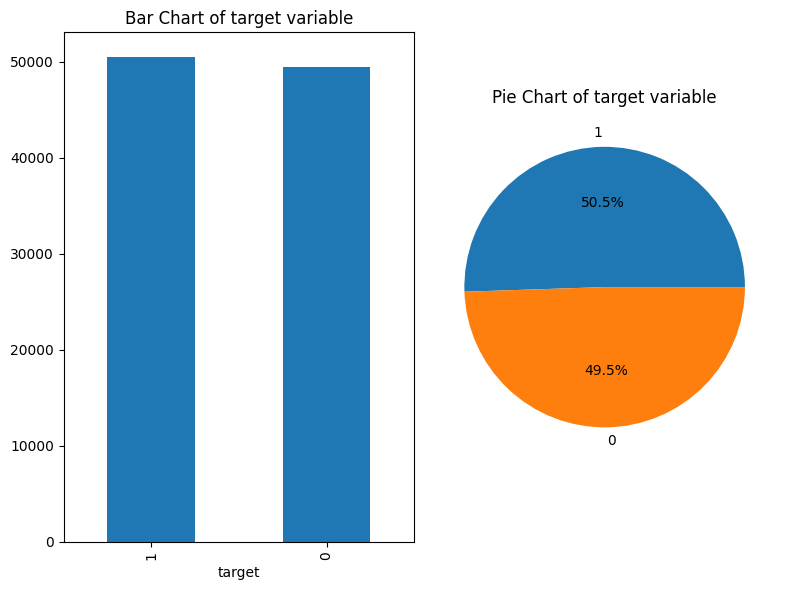

In [25]:
fig,axes=plt.subplots(1,2,figsize=(8,6))
df['target'].value_counts().plot(kind='bar',ax=axes[0])
axes[0].set_title('Bar Chart of target variable')
plt.pie(df['target'].value_counts(),labels=df['target'].value_counts().index,autopct='%1.1f%%')
axes[1].set_title('Pie Chart of target variable')
plt.tight_layout()
plt.show()

- Target Column is evenly distribution with 50.5% of value "1" and 49.5% of value "0".

## Distribution Graphs

In [26]:
cols

Index(['MachineID', 'ProductName', 'EngineVersion', 'AppVersion',
       'SignatureVersion', 'IsBetaUser', 'RealTimeProtectionState',
       'IsPassiveModeEnabled', 'AntivirusConfigID',
       'NumAntivirusProductsInstalled', 'NumAntivirusProductsEnabled',
       'HasTpm', 'CountryID', 'CityID', 'GeoRegionID', 'LocaleEnglishNameID',
       'PlatformType', 'Processor', 'OSVersion', 'OSBuildNumber',
       'OSProductSuite', 'OsPlatformSubRelease', 'OSBuildLab',
       'SKUEditionName', 'IsSystemProtected', 'AutoSampleSubmissionEnabled',
       'SMode', 'IEVersionID', 'FirewallEnabled', 'EnableLUA',
       'MDC2FormFactor', 'DeviceFamily', 'OEMNameID', 'OEMModelID',
       'ProcessorCoreCount', 'ProcessorManufacturerID', 'ProcessorModelID',
       'PrimaryDiskCapacityMB', 'PrimaryDiskType', 'SystemVolumeCapacityMB',
       'HasOpticalDiskDrive', 'TotalPhysicalRAMMB', 'ChassisType',
       'PrimaryDisplayDiagonalInches', 'PrimaryDisplayResolutionHorizontal',
       'PrimaryDisplayResolutio

In [27]:
df['NumAntivirusProductsInstalled'].value_counts()

NumAntivirusProductsInstalled
1.0    69748
2.0    27825
3.0     2255
4.0       91
5.0        5
Name: count, dtype: int64

In [28]:
df['OSBuildNumber'].value_counts()

OSBuildNumber
17134    45837
16299    29632
15063     8376
14393     7378
10586     3869
10240     3108
9600      1401
7601       226
17744       26
17692       26
17738       20
17758       14
17735       14
17741       14
17746       14
17713       11
17755        7
17763        6
17751        6
17760        5
17672        4
17754        3
17730        2
17686        1
Name: count, dtype: int64

In [29]:
num_cols=df.select_dtypes(include=['int','float'])
num_cols

,IsBetaUser,RealTimeProtectionState,IsPassiveModeEnabled,AntivirusConfigID,NumAntivirusProductsInstalled,NumAntivirusProductsEnabled,HasTpm,CountryID,CityID,GeoRegionID,LocaleEnglishNameID,OSBuildNumber,OSProductSuite,IsSystemProtected,AutoSampleSubmissionEnabled,SMode,IEVersionID,FirewallEnabled,EnableLUA,OEMNameID,OEMModelID,ProcessorCoreCount,ProcessorManufacturerID,ProcessorModelID,PrimaryDiskCapacityMB,SystemVolumeCapacityMB,HasOpticalDiskDrive,TotalPhysicalRAMMB,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,InternalBatteryNumberOfCharges,OSBuildNumberOnly,OSBuildRevisionOnly,OSInstallLanguageID,OSUILocaleID,IsPortableOS,IsFlightsDisabled,FirmwareManufacturerID,FirmwareVersionID,IsSecureBootEnabled,IsVirtualDevice,IsTouchEnabled,IsPenCapable,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,target
0,0,7.0,0,53447.0,1.0,1.0,1,51,120232.0,98.0,103,14393,768,1.0,0,0.0,98.0,1.0,1.0,561.0,330367.0,4.0,5.0,1850.0,15028.0,14348.0,0,1024.0,8.0,800.0,1280.0,1.420000e+02,14393,2214,5.0,26,0,0.0,513.0,21964.0,0,0.0,1,0,1.0,0.0,6.0,0
1,0,7.0,0,53447.0,1.0,1.0,1,141,112854.0,167.0,227,17134,256,1.0,0,0.0,137.0,1.0,1.0,2668.0,25212.0,4.0,5.0,2407.0,953869.0,952592.0,1,4096.0,19.4,1600.0,900.0,4.294967e+09,17134,228,9.0,34,0,0.0,628.0,44548.0,1,0.0,0,0,0.0,0.0,10.0,1
2,0,7.0,0,53447.0,1.0,1.0,1,51,41759.0,98.0,103,17134,768,1.0,0,0.0,137.0,1.0,1.0,3035.0,263666.0,4.0,5.0,2719.0,228936.0,228321.0,1,8192.0,24.0,1920.0,1080.0,4.294967e+09,17134,285,5.0,26,0,0.0,142.0,9414.0,0,0.0,0,0,0.0,1.0,6.0,1
3,0,7.0,0,46413.0,2.0,1.0,1,68,19507.0,276.0,74,15063,768,1.0,0,0.0,108.0,1.0,1.0,2102.0,242491.0,4.0,5.0,3410.0,1907729.0,1890776.0,0,8192.0,15.5,1366.0,768.0,0.000000e+00,15063,850,7.0,30,0,0.0,554.0,33060.0,1,0.0,0,0,0.0,0.0,12.0,1
4,0,7.0,0,40466.0,2.0,1.0,1,43,117801.0,53.0,42,17134,256,1.0,0,0.0,137.0,1.0,1.0,2668.0,257309.0,2.0,5.0,4322.0,305245.0,52804.0,0,2048.0,20.0,1600.0,900.0,4.294967e+09,17134,285,37.0,158,0,0.0,628.0,13224.0,0,0.0,0,0,0.0,1.0,7.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0,7.0,0,68585.0,2.0,1.0,1,43,71228.0,53.0,42,16299,256,1.0,0,0.0,117.0,1.0,1.0,4909.0,317701.0,4.0,5.0,2615.0,122104.0,121488.0,0,8192.0,23.8,1920.0,1080.0,4.294967e+09,17134,319,37.0,158,0,0.0,142.0,25740.0,0,0.0,0,0,0.0,1.0,7.0,0
99996,0,7.0,0,11280.0,2.0,1.0,1,137,137066.0,160.0,74,17134,256,1.0,0,0.0,137.0,1.0,1.0,1443.0,260853.0,4.0,5.0,2529.0,476940.0,475637.0,0,4096.0,13.2,1366.0,768.0,0.000000e+00,17134,165,8.0,31,0,0.0,355.0,20900.0,0,0.0,0,0,0.0,0.0,3.0,0
99997,0,7.0,0,53447.0,1.0,1.0,1,142,74924.0,157.0,68,16299,256,1.0,0,0.0,111.0,1.0,1.0,2102.0,250496.0,4.0,5.0,2719.0,953869.0,532690.0,0,4096.0,18.5,1366.0,768.0,4.294967e+09,16299,309,8.0,31,0,0.0,486.0,51605.0,1,0.0,0,0,0.0,1.0,1.0,1
99998,0,7.0,0,53447.0,1.0,1.0,1,139,87570.0,158.0,74,17134,256,1.0,0,0.0,137.0,1.0,1.0,3150.0,313499.0,4.0,5.0,3032.0,976762.0,497353.0,0,16384.0,13.5,3000.0,2000.0,4.500000e+01,17134,48,8.0,31,0,0.0,677.0,18669.0,1,0.0,1,1,1.0,0.0,1.0,0


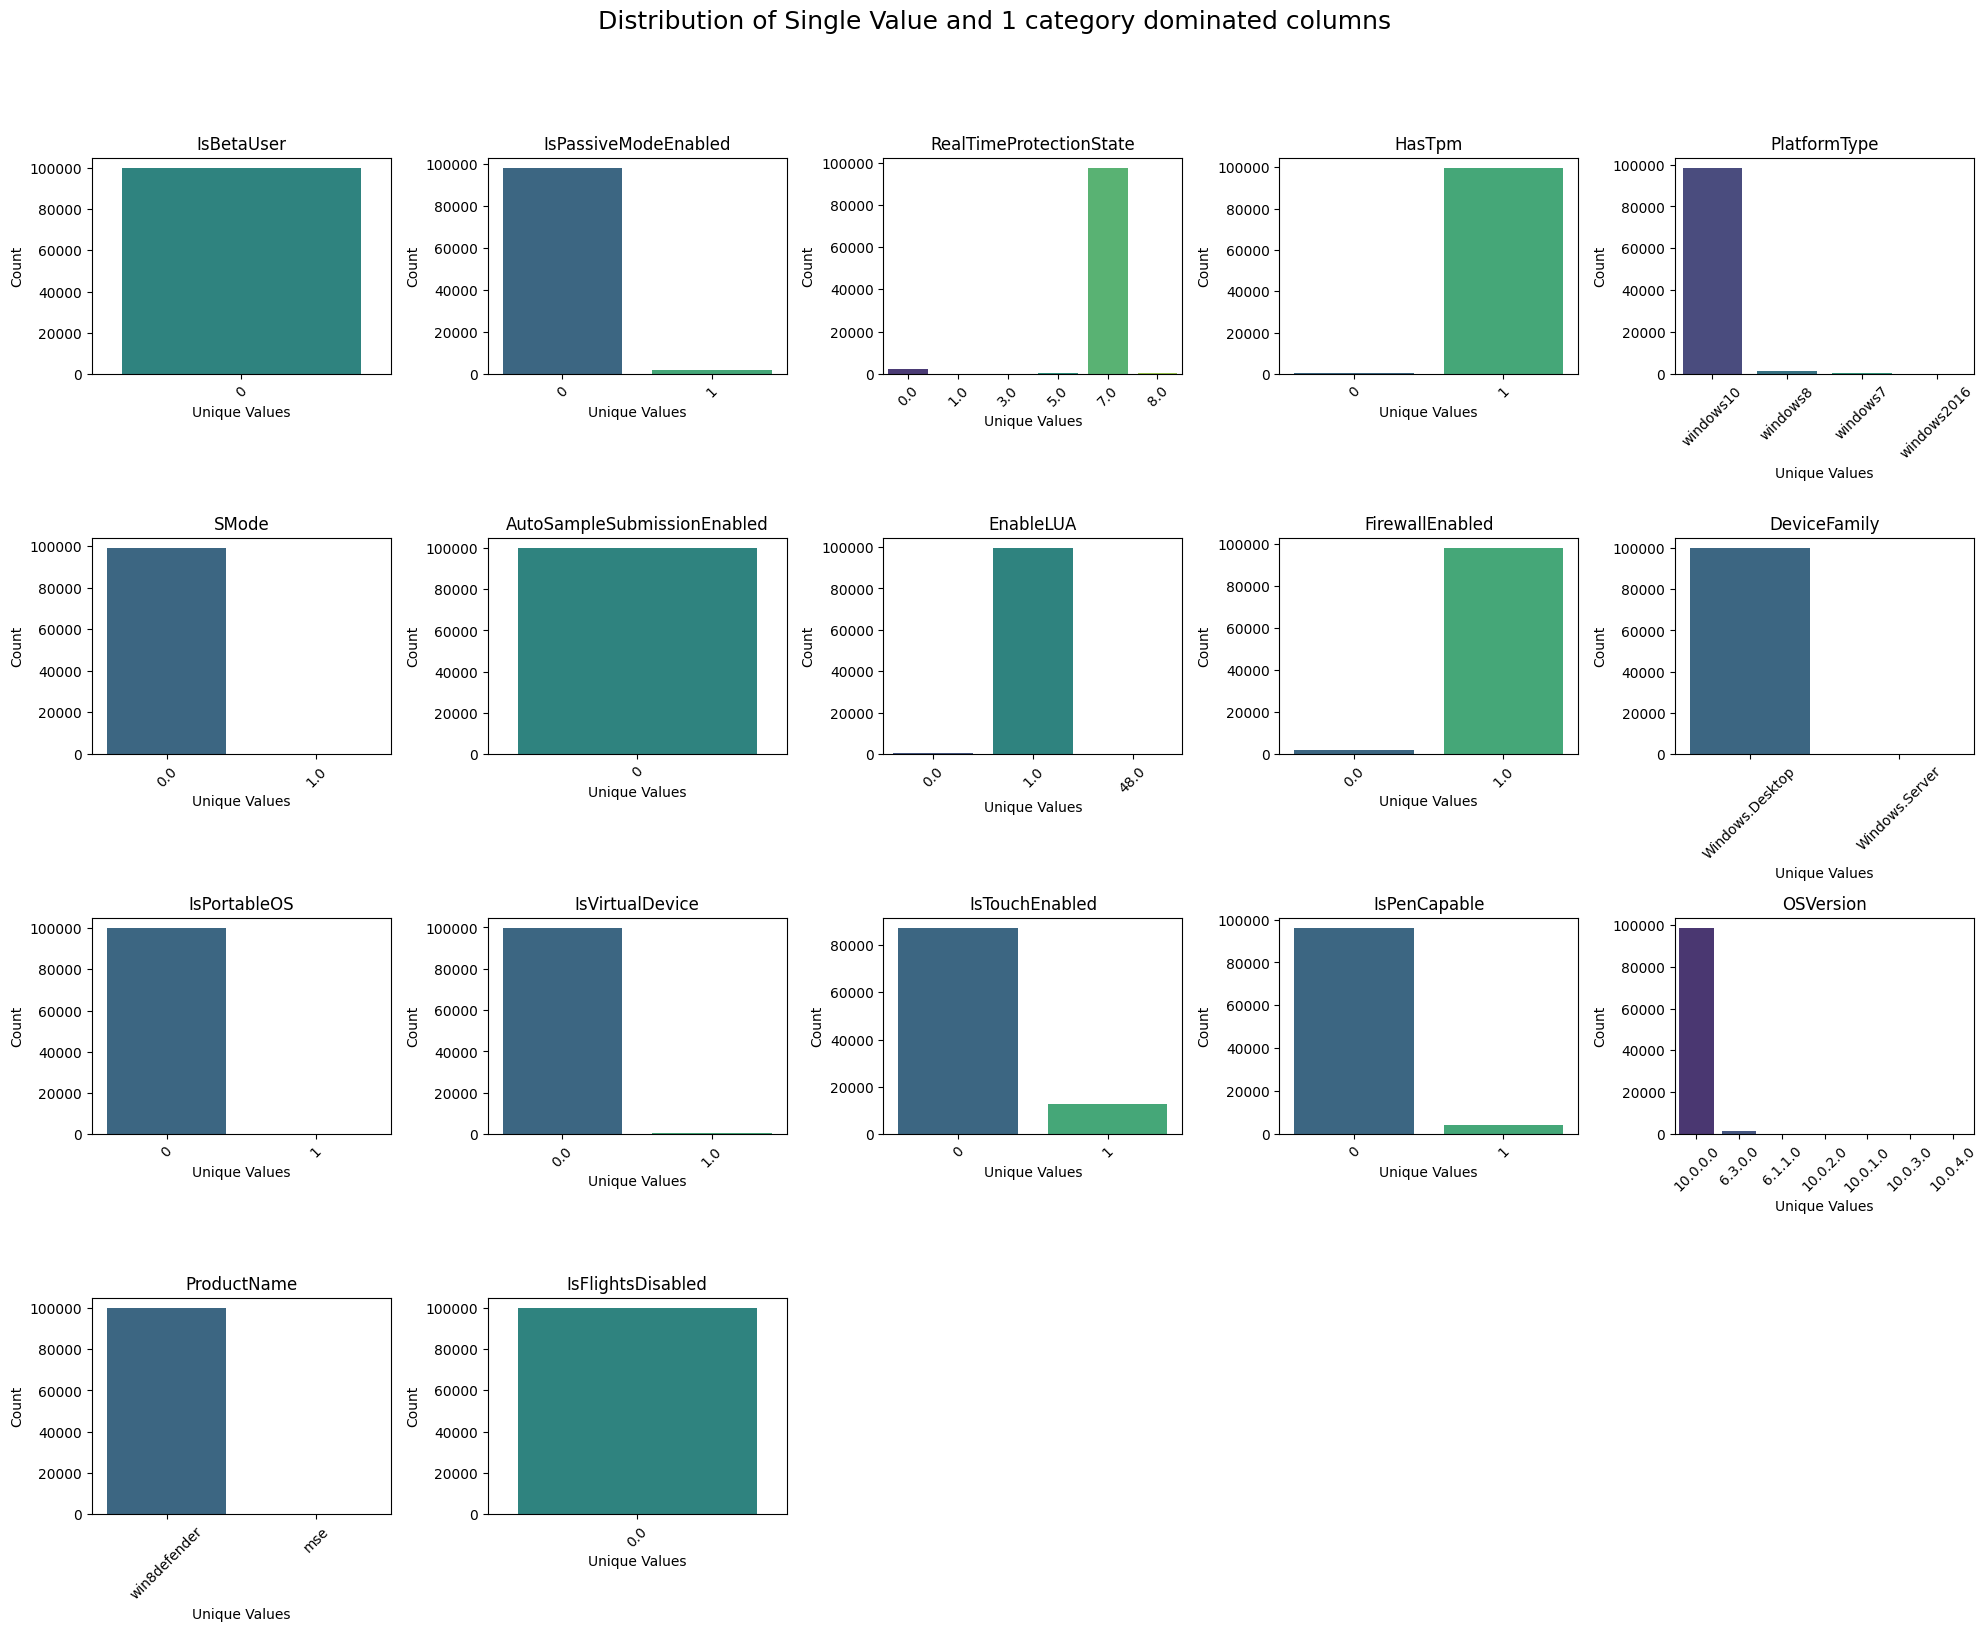

In [30]:
same_value_cols=['IsBetaUser','IsPassiveModeEnabled','RealTimeProtectionState','HasTpm','PlatformType','SMode','AutoSampleSubmissionEnabled','EnableLUA','FirewallEnabled','DeviceFamily','IsPortableOS','IsVirtualDevice',
                 'IsTouchEnabled','IsPenCapable','OSVersion','ProductName','IsFlightsDisabled']
rows=6
cols=5
fig,axes=plt.subplots(rows,cols,figsize=(20,24))
fig.suptitle('Distribution of Single Value and 1 category dominated columns',fontsize=18)
axes=axes.flatten()
for idx,col in enumerate(same_value_cols):
    sns.countplot(data=df,x=col,ax=axes[idx],palette='viridis')
    axes[idx].set_title(f'{col}', fontsize=12)
    axes[idx].set_xlabel('Unique Values')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

for i in range(len(same_value_cols), len(axes)): #removes unneccessary subplots
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  #spacing
plt.show()

-   **IsBetaUser**,**IsPassiveModeEnabled**,**RealTimeProtectionState**,**HasTpm**,**PlatformType**,**SMode**,**AutoSampleSubmissionEnabled**,**EnableLUA**,**FirewallEnabled**,**DeviceFamily**,**IsPortableOS',**IsVirtualDevice**,
                 **IsTouchEnabled**,**IsPenCapable**,**OSVersion**,**ProductName**,**IsFlightsDisabled** by looking at these columns they are mostly single value columns and they will not be usefull in model training hence we will be dropping all of them.

In [31]:
df=df.drop(columns=['IsBetaUser','IsPassiveModeEnabled','RealTimeProtectionState','HasTpm','PlatformType','SMode','AutoSampleSubmissionEnabled','EnableLUA','FirewallEnabled','DeviceFamily','IsPortableOS','IsVirtualDevice',
                 'IsTouchEnabled','IsPenCapable','OSVersion','ProductName','IsFlightsDisabled'])
test_df=test_df.drop(columns=['IsBetaUser','IsPassiveModeEnabled','RealTimeProtectionState','HasTpm','PlatformType','SMode','AutoSampleSubmissionEnabled','EnableLUA','FirewallEnabled','DeviceFamily','IsPortableOS','IsVirtualDevice',
                 'IsTouchEnabled','IsPenCapable','OSVersion','ProductName','IsFlightsDisabled'])

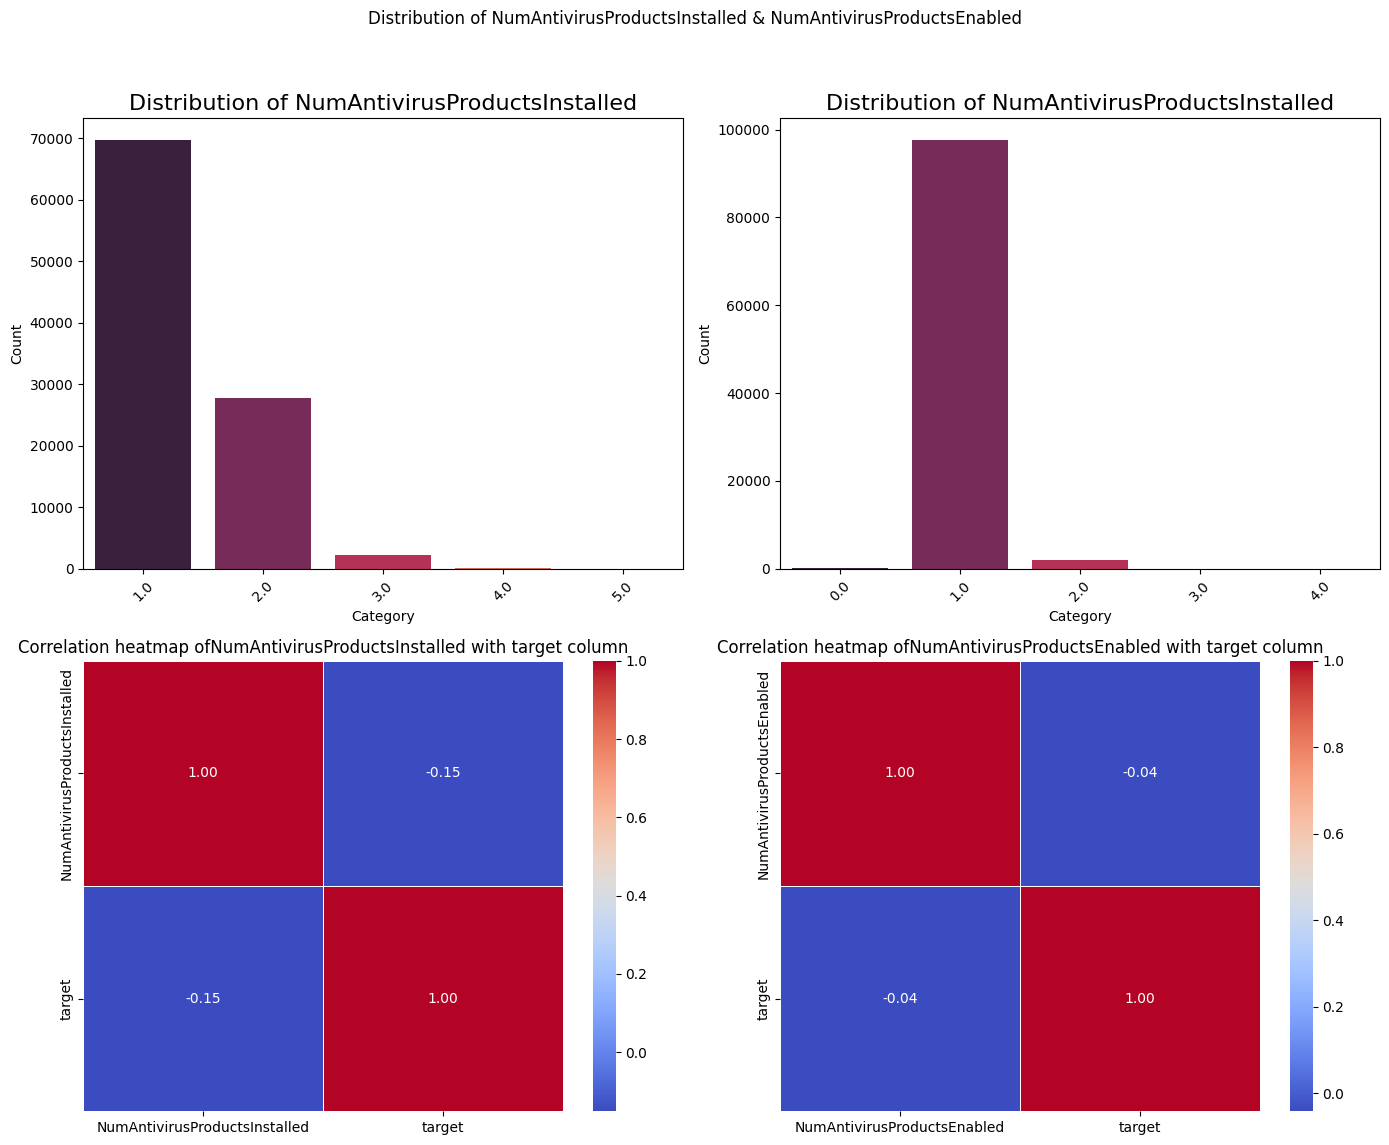

In [32]:
li=['NumAntivirusProductsInstalled','NumAntivirusProductsEnabled']
fig,axes=plt.subplots(2,2,figsize=(14,12))
fig.suptitle('Distribution of NumAntivirusProductsInstalled & NumAntivirusProductsEnabled')

for i in range(len(li)):
    sns.countplot(data=df,x=li[i],ax=axes[0,i],palette='rocket')
    axes[0,i].set_title(f'Distribution of {li[0]}',fontsize=16)
    axes[0,i].set_xlabel('Category')
    axes[0,i].set_ylabel('Count')
    axes[0,i].tick_params(axis='x',rotation=45)

    sns.heatmap(df[[li[i],'target']].corr(),annot=True,cmap='coolwarm',fmt=".2f",linewidth=0.5,ax=axes[1,i])
    axes[1,i].set_title(f'Correlation heatmap of{li[i]} with target column')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

- As we can see in **NumAntivirusProductsInstalled** most of user hacve 1 antivirus installed in their followed by 2 and 3 and very less amount of system has 4&5 antivirus installed in their system.
- **In NumAntivirusProductsEnabled** Most of the system have 1 antivirus enabled in their system.
- Now will do a univariate analysis using counplot and put them side by side to analyse their relationship with target column

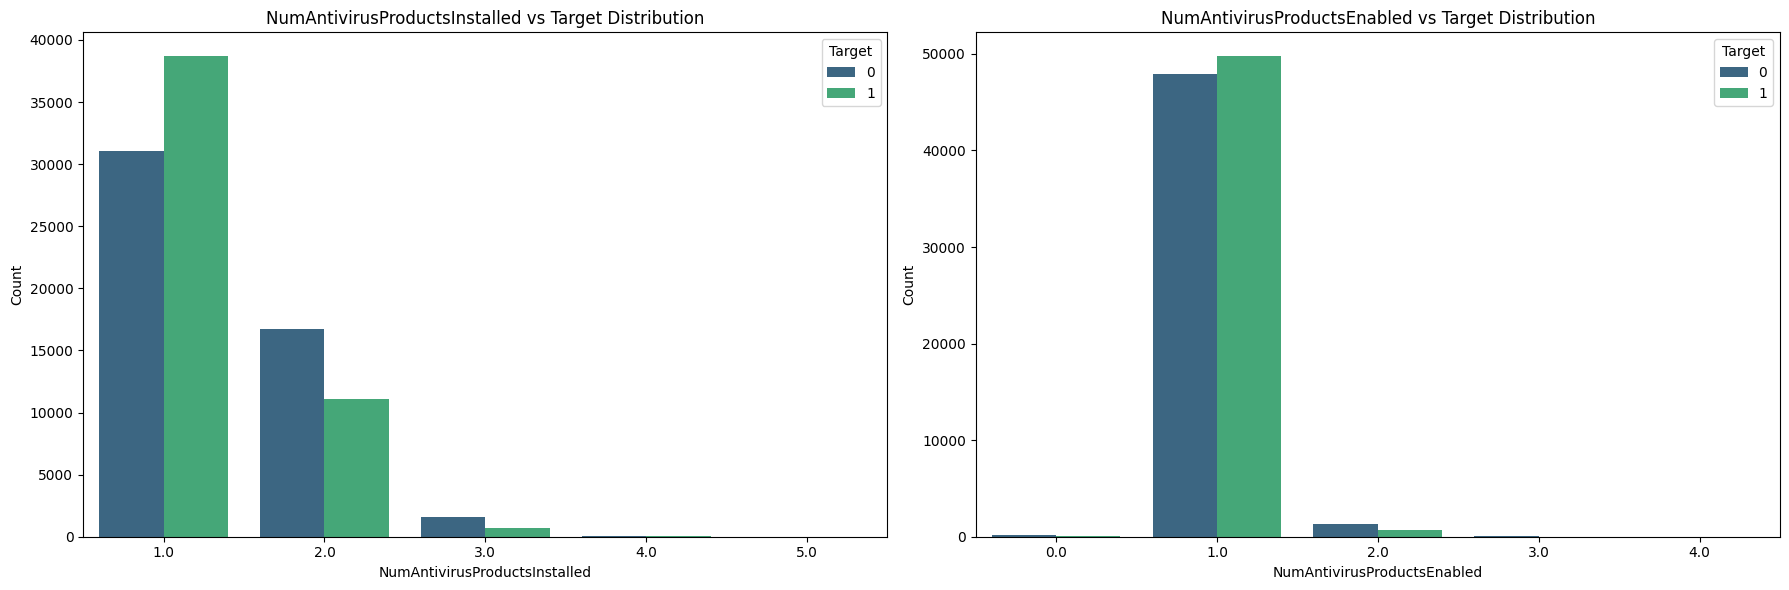

In [33]:
fig,axes=plt.subplots(1,2,figsize=(18,6))

sns.countplot(data=df,x='NumAntivirusProductsInstalled',hue='target',palette='viridis',ax=axes[0])
axes[0].set_title('NumAntivirusProductsInstalled vs Target Distribution')
axes[0].set_xlabel('NumAntivirusProductsInstalled')
axes[0].set_ylabel('Count')
axes[0].legend(title='Target')

sns.countplot(data=df,x='NumAntivirusProductsEnabled',hue='target',palette='viridis',ax=axes[1])
axes[1].set_title('NumAntivirusProductsEnabled vs Target Distribution')
axes[1].set_xlabel('NumAntivirusProductsEnabled')
axes[1].set_ylabel('Count')
axes[1].legend(title='Target')

plt.tight_layout()
plt.show()

- By looking at **NumAntivirusProductsInstalled** & **NumAntivirusProductsEnabled** we can see that Those who have 1 antivirus installed have higher chances of malware detection and those who have 1 antivirus enabled have slighest high chance of malware detection.
- Which means we can drop **NumAntivirusProductsEnabled** as it is of no use because there are almost 98-99% users which have 1 antivirus enabled in their System

In [34]:
df=df.drop(columns=['NumAntivirusProductsEnabled'])
test_df=test_df.drop(columns=['NumAntivirusProductsEnabled'])

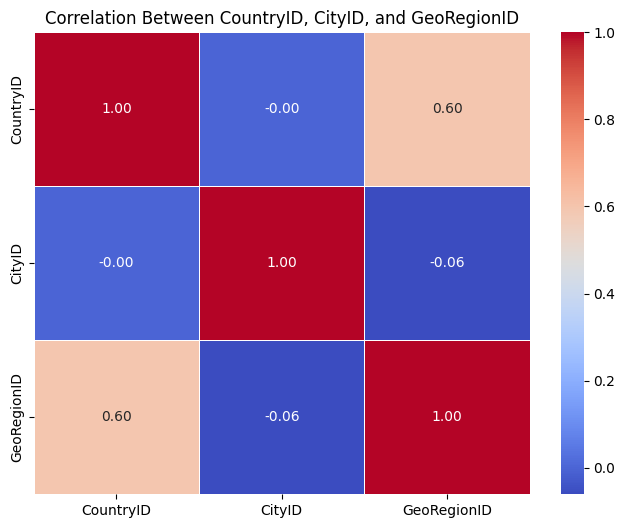

In [35]:
corr_matrix = df[['CountryID', 'CityID', 'GeoRegionID']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f",linewidth=0.5)
plt.title('Correlation Between CountryID, CityID, and GeoRegionID')
plt.show()

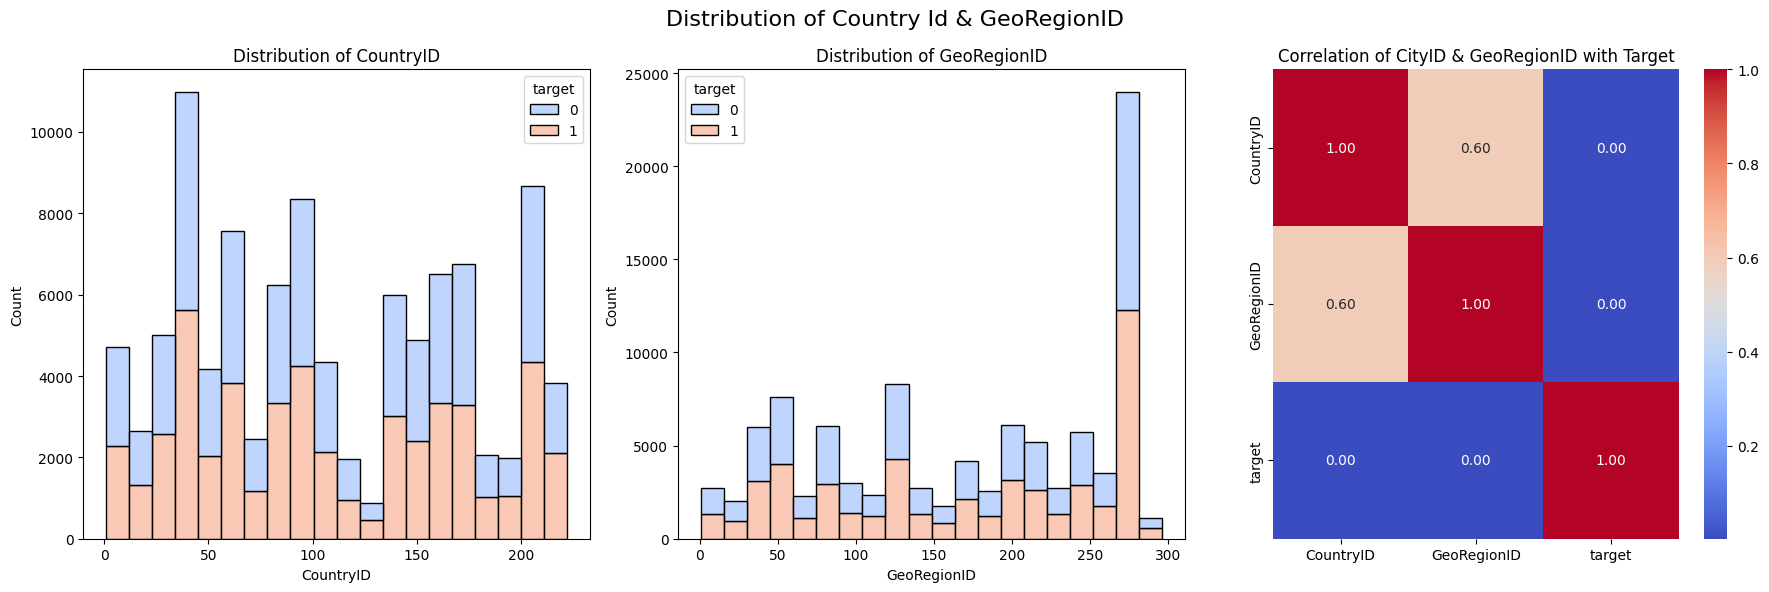

In [36]:
cols=['CountryID', 'GeoRegionID']
fig,axes=plt.subplots(1,3,figsize=(18,6))
fig.suptitle("Distribution of Country Id & GeoRegionID",fontsize=16)

for i, col in enumerate(cols):
    sns.histplot(data=df,x=col,bins=20,hue='target',ax=axes[i],palette='coolwarm',multiple='stack')
    axes[i].set_title(f'Distribution of {col}')
    
sns.heatmap(df[['CountryID','GeoRegionID','target']].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation of CityID & GeoRegionID with Target")
plt.tight_layout()
plt.show()

- By looking at these figure we can assure that there is no correlation of countryId and georegionID with each other and they are evenly spreaded with target, so we can drop both and keep the CityID it has high values it can help in malware detection.

In [37]:
df=df.drop(columns=['GeoRegionID','CountryID'])
test_df=test_df.drop(columns=['GeoRegionID','CountryID'])

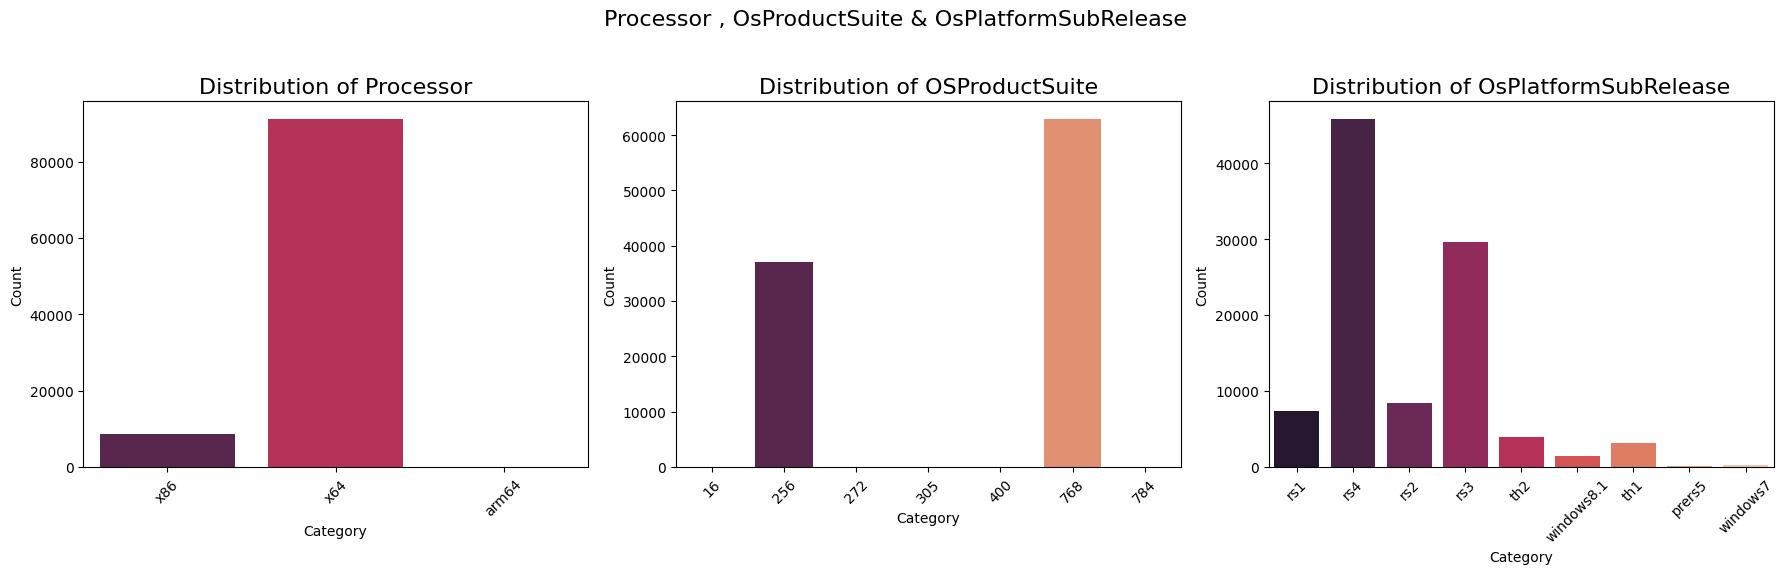

In [38]:
cols=['Processor','OSProductSuite','OsPlatformSubRelease']
fig,axes=plt.subplots(1,3,figsize=(18,6))
fig.suptitle("Processor , OsProductSuite & OsPlatformSubRelease",fontsize=16)
for i,col in enumerate(cols):
    sns.countplot(data=df,x=col,ax=axes[i],palette='rocket')
    axes[i].set_title(f'Distribution of {col}',fontsize=16)
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x',rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

- **Processor** -> As we can see most of the users have x64 as their processor followed by x86 and very negligible amount of users have arm64.
- **OsProductSuite** -> All of them have 768 and 256 as their OSproductsuite.
- **OsPlatformSubRelease** -> Rs4 is being most frequent category followed by rs3,rs2 ,rs1,etc

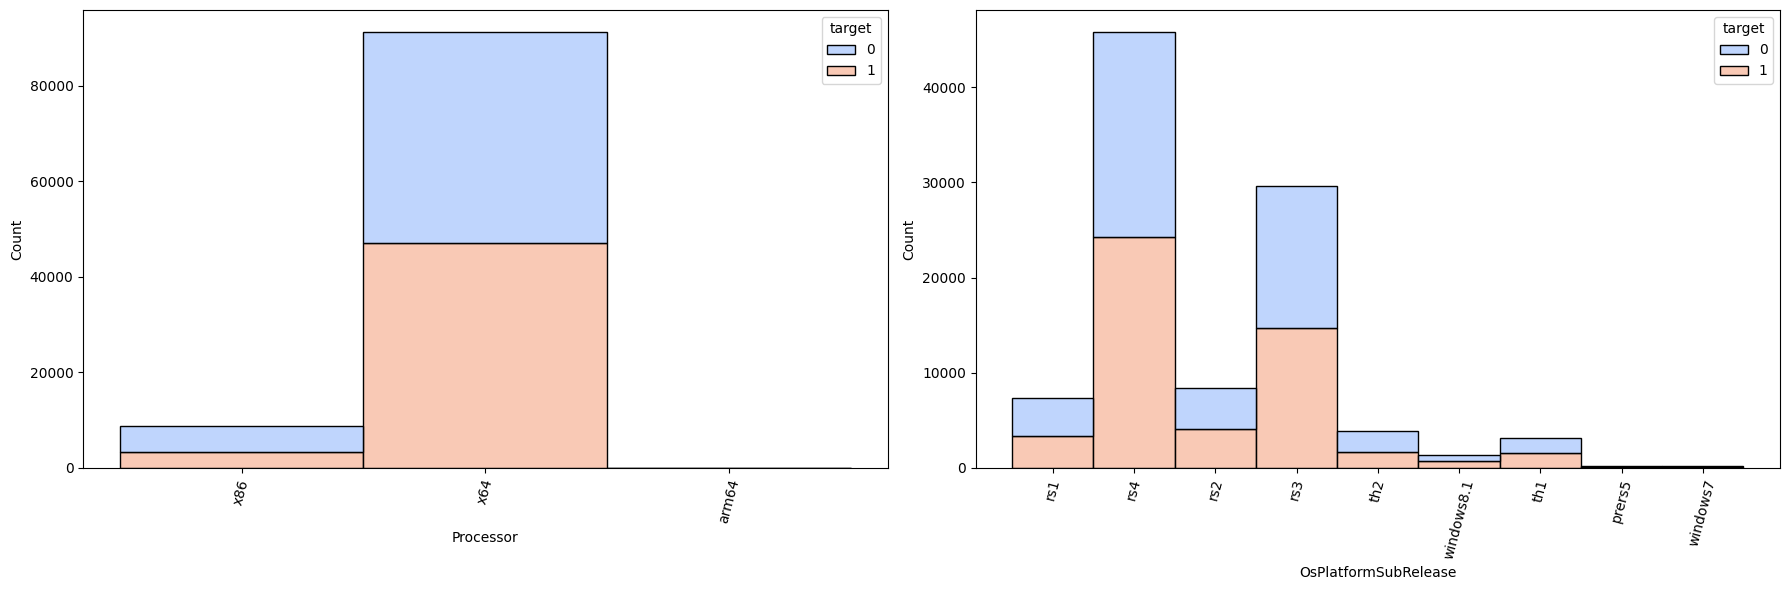

In [39]:
fig,axes=plt.subplots(1,2,figsize=(18,6))

sns.histplot(data=df,x='Processor',hue='target',palette='coolwarm',ax=axes[0],multiple='stack')
axes[0].tick_params(axis='x',rotation=75)

sns.histplot(data=df,x='OsPlatformSubRelease',hue='target',palette='coolwarm',ax=axes[1],multiple='stack')
axes[1].tick_params(axis='x',rotation=75)
plt.tight_layout()
plt.show()


- **Processor** As we can see in these histplots I have done univariate analysis and by looking at these graphs, this does not provide much information about the features and relation with target column, as its obvious that x64 is most frequent value in the processor the distribution of target column is equal in it there is not any difference.
- **OsPlatformSubRelease** as we can see in this its obvious the rs4 is being most frequent and there is equal distribution of target column in these category so this is not providing any information.

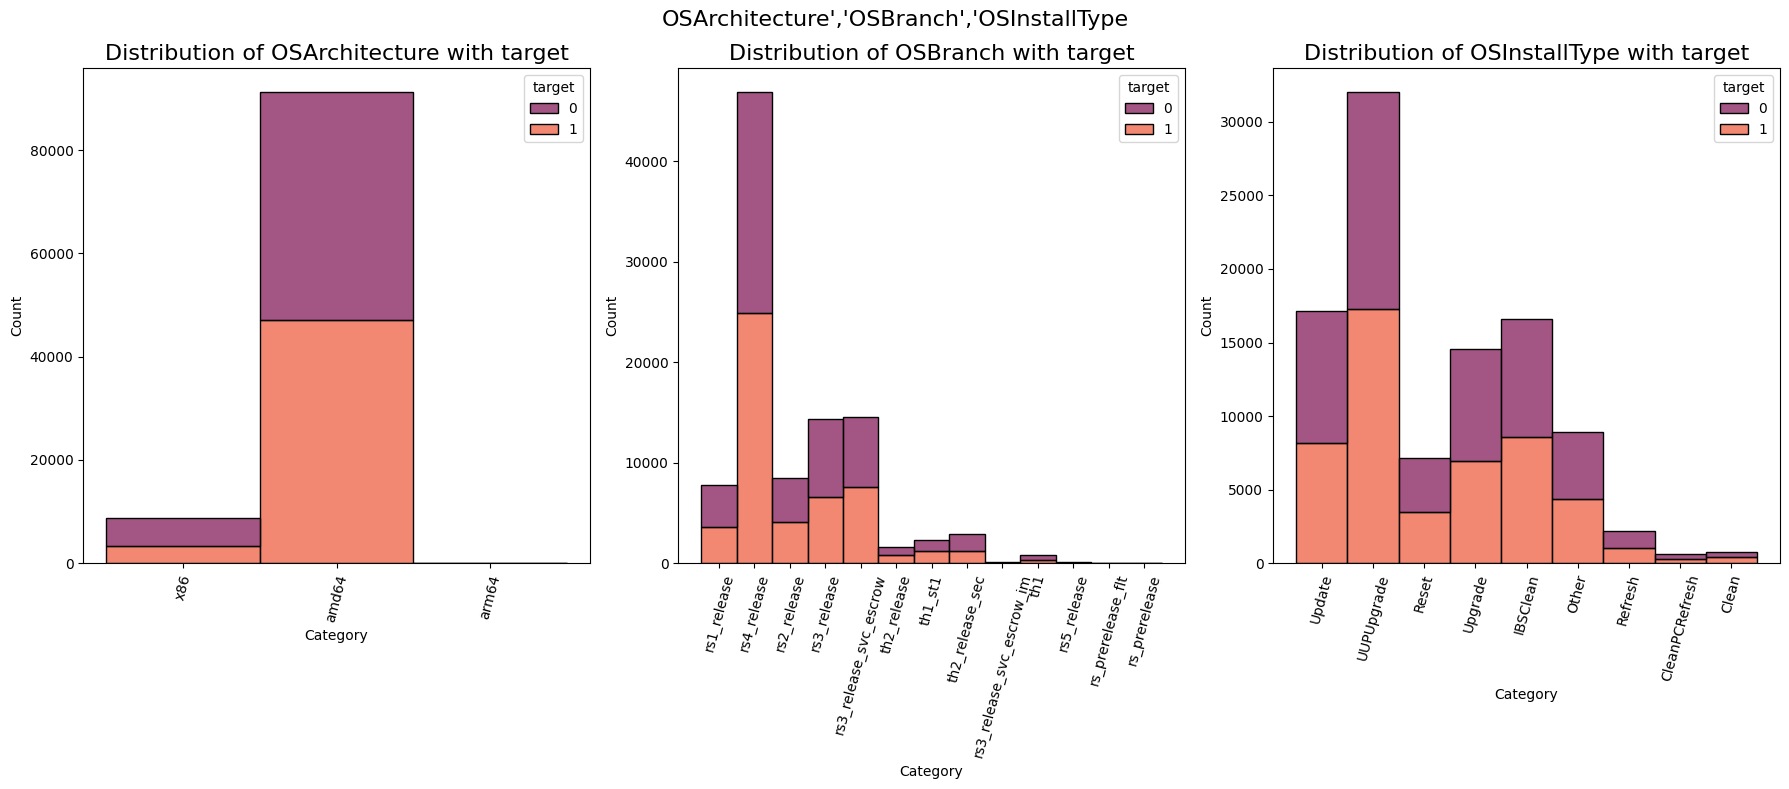

In [40]:
cols=['OSArchitecture','OSBranch','OSInstallType']
fig,axes=plt.subplots(1,3,figsize=(18,8))
fig.suptitle("OSArchitecture','OSBranch','OSInstallType",fontsize=16)
for i,col in enumerate(cols):
    sns.histplot(data=df,x=col,hue='target',palette='rocket',ax=axes[i],multiple='stack')
    axes[i].set_title(f'Distribution of {col} with target',fontsize=16)
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x',rotation=75)
plt.tight_layout()
plt.show()

- **OSArchitecture** -> There are 3 Categories in which amd65 is the highest followed by x86 and arm64 as least, and distribution with target column is equal and in x86 there is slight higher chance of not getting affected by malware rest is same.
- **OSBranch** -> There are 13 unique categories with rs4_realease as highest and distribution with target columns are equal in all columns.
- **OSInstallType** -> There are 9 unique categories with UUPUpgrade as the most frequent one and distribution with target columns are equal in all columns.

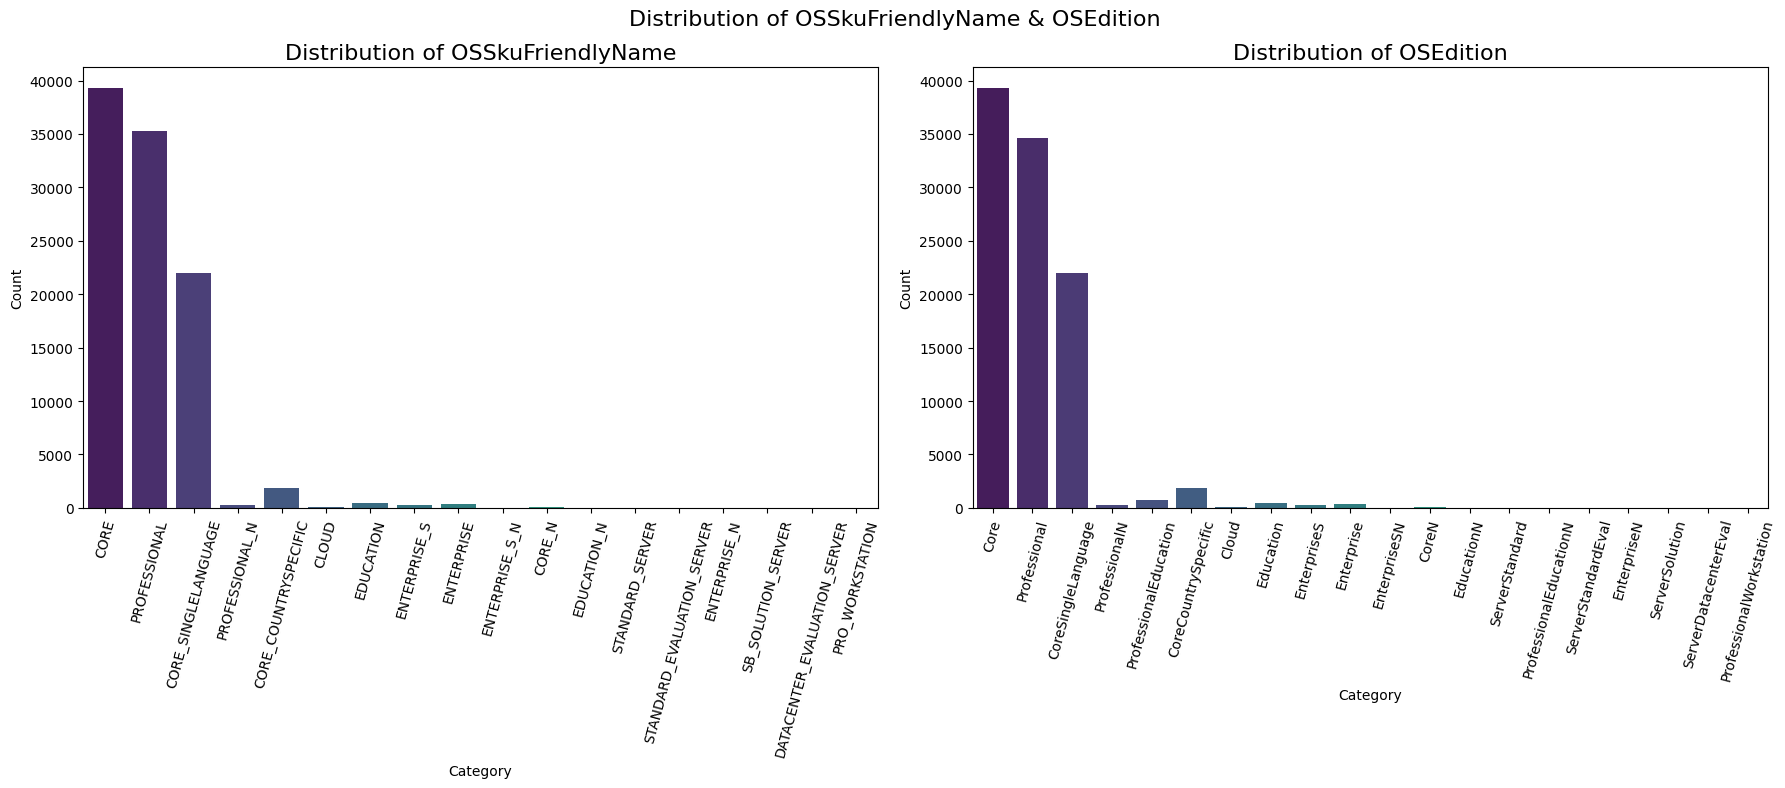

In [41]:
cols=['OSSkuFriendlyName','OSEdition']
fig,axes=plt.subplots(1,2,figsize=(18,8))
fig.suptitle("Distribution of OSSkuFriendlyName & OSEdition",fontsize=16)
for i,col in enumerate(cols):
    sns.countplot(data=df,x=col,ax=axes[i],palette='viridis')
    axes[i].set_title(f'Distribution of {col}',fontsize=16)
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x',rotation=75)

plt.tight_layout()
plt.show()

- By looking at the **OSSkuFriendlyName** **OSEdition** they are correlated to each other hence we will dropping **OSEdition** column from test and train dataset.
- **OSSkuFriendlyName**  we will be combining all category except Core Professional & CORE_SingleLanguage, because they are very less value count in the dataset.

In [42]:
df['OSSkuFriendlyName']=df['OSSkuFriendlyName'].where(df['OSSkuFriendlyName'].isin(['CORE','PROFESSIONAL','CORE_SINGLELANGUAGE']),'other_OSSkuFriendlyName')
test_df['OSSkuFriendlyName']=test_df['OSSkuFriendlyName'].where(test_df['OSSkuFriendlyName'].isin(['CORE','PROFESSIONAL','CORE_SINGLELANGUAGE']),'other_OSSkuFriendlyName')


df=df.drop(columns=['OSEdition'])
test_df=test_df.drop(columns=['OSEdition'])

In [43]:
df['Processor'].value_counts(normalize=True)*100

Processor
x64      91.262
x86       8.733
arm64     0.005
Name: proportion, dtype: float64

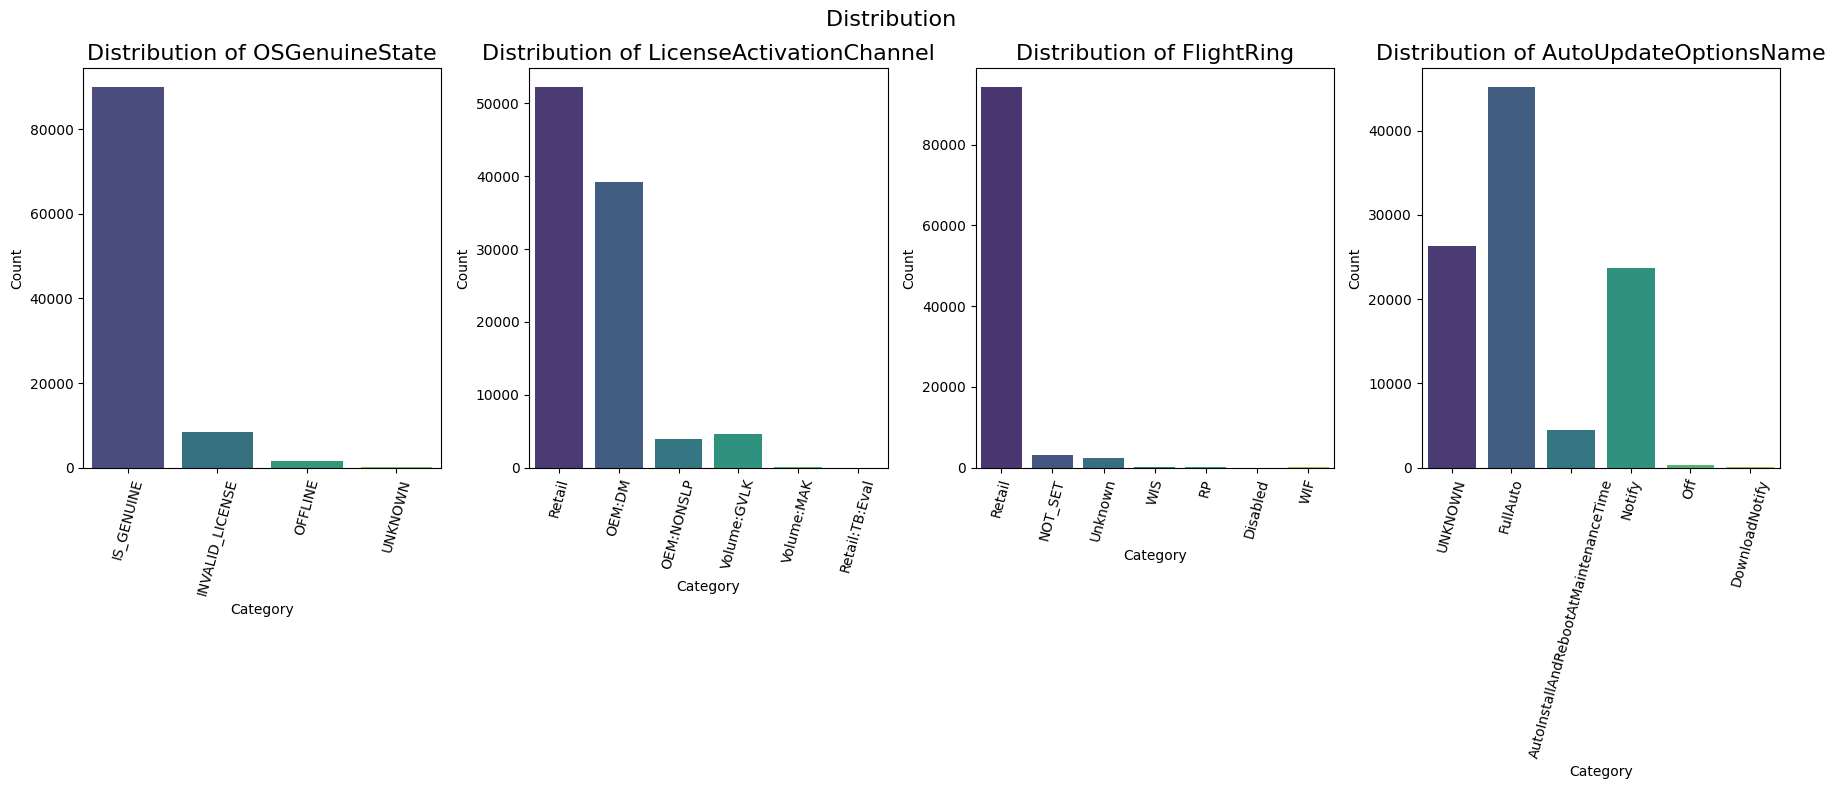

In [44]:
cols=['OSGenuineState','LicenseActivationChannel','FlightRing','AutoUpdateOptionsName']
fig,axes=plt.subplots(1,4,figsize=(18,8))
fig.suptitle("Distribution ",fontsize=16)
for i,col in enumerate(cols):
    sns.countplot(data=df,x=col,ax=axes[i],palette='viridis')
    axes[i].set_title(f'Distribution of {col}',fontsize=16)
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x',rotation=75)
plt.tight_layout()
plt.show()

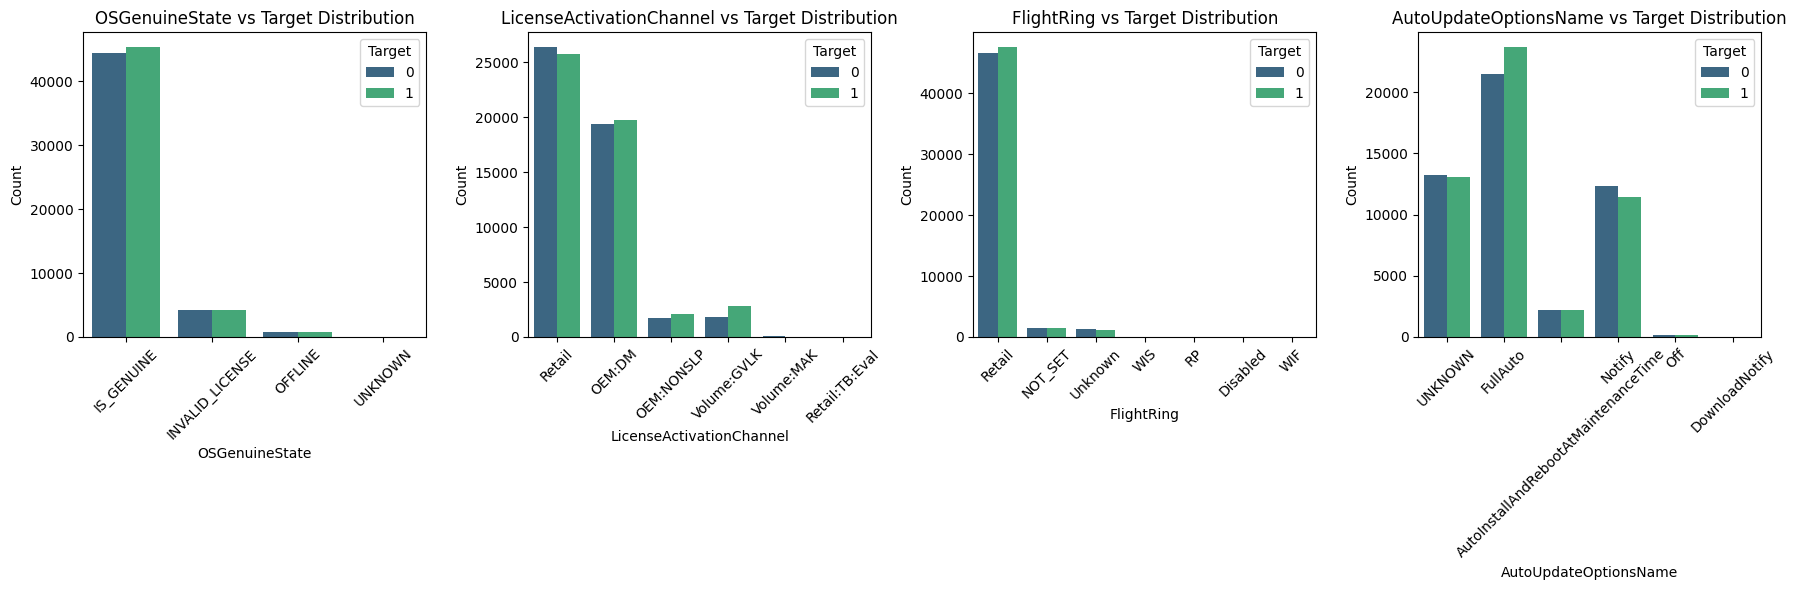

In [45]:
fig,axes=plt.subplots(1,4,figsize=(18,6))

sns.countplot(data=df,x='OSGenuineState',hue='target',palette='viridis',ax=axes[0])
axes[0].set_title('OSGenuineState vs Target Distribution')
axes[0].set_xlabel('OSGenuineState')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x',rotation=45)
axes[0].legend(title='Target')

sns.countplot(data=df,x='LicenseActivationChannel',hue='target',palette='viridis',ax=axes[1])
axes[1].set_title('LicenseActivationChannel vs Target Distribution')
axes[1].set_xlabel('LicenseActivationChannel')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x',rotation=45)
axes[1].legend(title='Target')

sns.countplot(data=df,x='FlightRing',hue='target',palette='viridis',ax=axes[2])
axes[2].set_title('FlightRing vs Target Distribution')
axes[2].set_xlabel('FlightRing')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x',rotation=45)
axes[2].legend(title='Target')

sns.countplot(data=df,x='AutoUpdateOptionsName',hue='target',palette='viridis',ax=axes[3])
axes[3].set_title('AutoUpdateOptionsName vs Target Distribution')
axes[3].set_xlabel('AutoUpdateOptionsName')
axes[3].set_ylabel('Count')
axes[3].tick_params(axis='x',rotation=45)
axes[3].legend(title='Target')

plt.tight_layout()
plt.show()

- **OSGenuineState** -> There are 4 categories with IS_GENUINE with the most frequent in that there is slighest higher chance of malware detection and equal distribution in INVALID_LICENSE & OFFLINE. 
- **LicenseActivationChannel** -> There are 6 categories with Retail as the highest followed by OEM:DM and in retail there is slightest higher chance of not getting affected by malware but in OEM:DM there is opposite so we can keep this column and we can combine VOLUMN:MAK and RETAIL:TB:Eval
- **FlightRing** -> There are 7 categories with Retail with the most frequent in that there is slighest higher chance of malware detection and equal distribution in NOT_SET & UNKNOWN and we can combine WIS,RP,DISABLED,WIF because of low frequency. 
- **AutoUpdateOptionsName** ->There are 6 categories with FULLAUTO with the most frequent in that there is higher chance of malware detection and equal distribution in UNKNOWN and we can combine Off and DOWNLOAD NOTIFY becuase of low frequency.

In [46]:
df['OSGenuineState']=df['OSGenuineState'].where(df['OSGenuineState'].isin(['IS_GENUINE','INVALID_LICENSE']),'other_OSGenuineState')
test_df['OSGenuineState']=test_df['OSGenuineState'].where(test_df['OSGenuineState'].isin(['IS_GENUINE','INVALID_LICENSE']),'other_OSGenuineState')

df['LicenseActivationChannel']=df['LicenseActivationChannel'].where(df['LicenseActivationChannel'].isin(['Retail','OEM:DM','OEM:NONSLP','Volume:GVLK']),'other_LicenseActivationChannel')
test_df['LicenseActivationChannel']=test_df['LicenseActivationChannel'].where(test_df['LicenseActivationChannel'].isin(['Retail','OEM:DM','OEM:NONSLP','Volume:GVLK']),'other_LicenseActivationChannel')

df['FlightRing']=df['FlightRing'].where(df['FlightRing'].isin(['Retail','NOT_SET','Unknown']),'other_FlightRing')
test_df['FlightRing']=test_df['FlightRing'].where(test_df['FlightRing'].isin(['Retail','NOT_SET','Unknown']),'other_FlightRing')

df['AutoUpdateOptionsName']=df['AutoUpdateOptionsName'].where(df['AutoUpdateOptionsName'].isin(['FullAuto','UNKNOWN','Notify']),'other_AutoUpdateOptionsName')
test_df['AutoUpdateOptionsName']=test_df['AutoUpdateOptionsName'].where(test_df['AutoUpdateOptionsName'].isin(['FullAuto','UNKNOWN','Notify']),'other_AutoUpdateOptionsName')

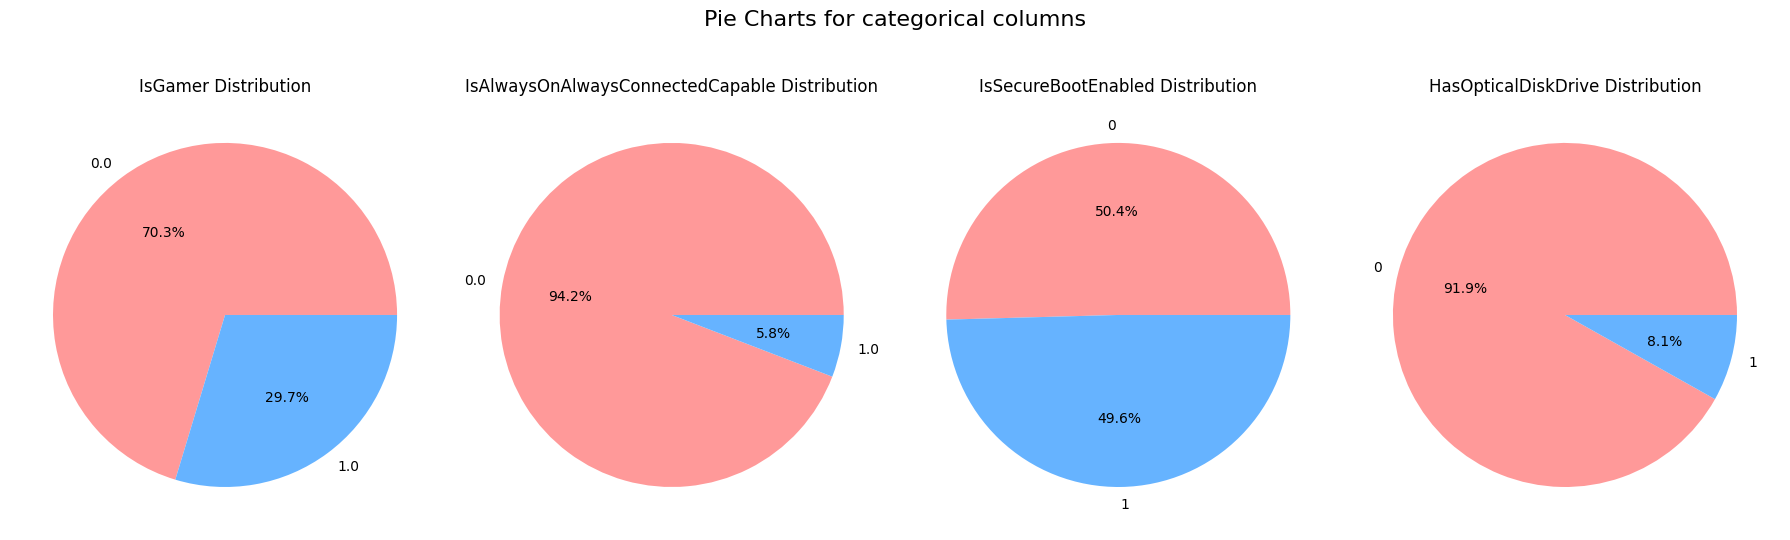

In [47]:
cols=['IsGamer','IsAlwaysOnAlwaysConnectedCapable','IsSecureBootEnabled','HasOpticalDiskDrive']
fig,axes=plt.subplots(1,4,figsize=(18,6))
fig.suptitle("Pie Charts for categorical columns",fontsize=16)
for i,col in enumerate(cols):
    values=df[col].value_counts()
    axes[i].pie(values,labels=values.index,autopct='%1.1f%%',colors=['#ff9999','#66b3ff'])
    axes[i].set_title(f'{col} Distribution')
plt.tight_layout()
plt.show()

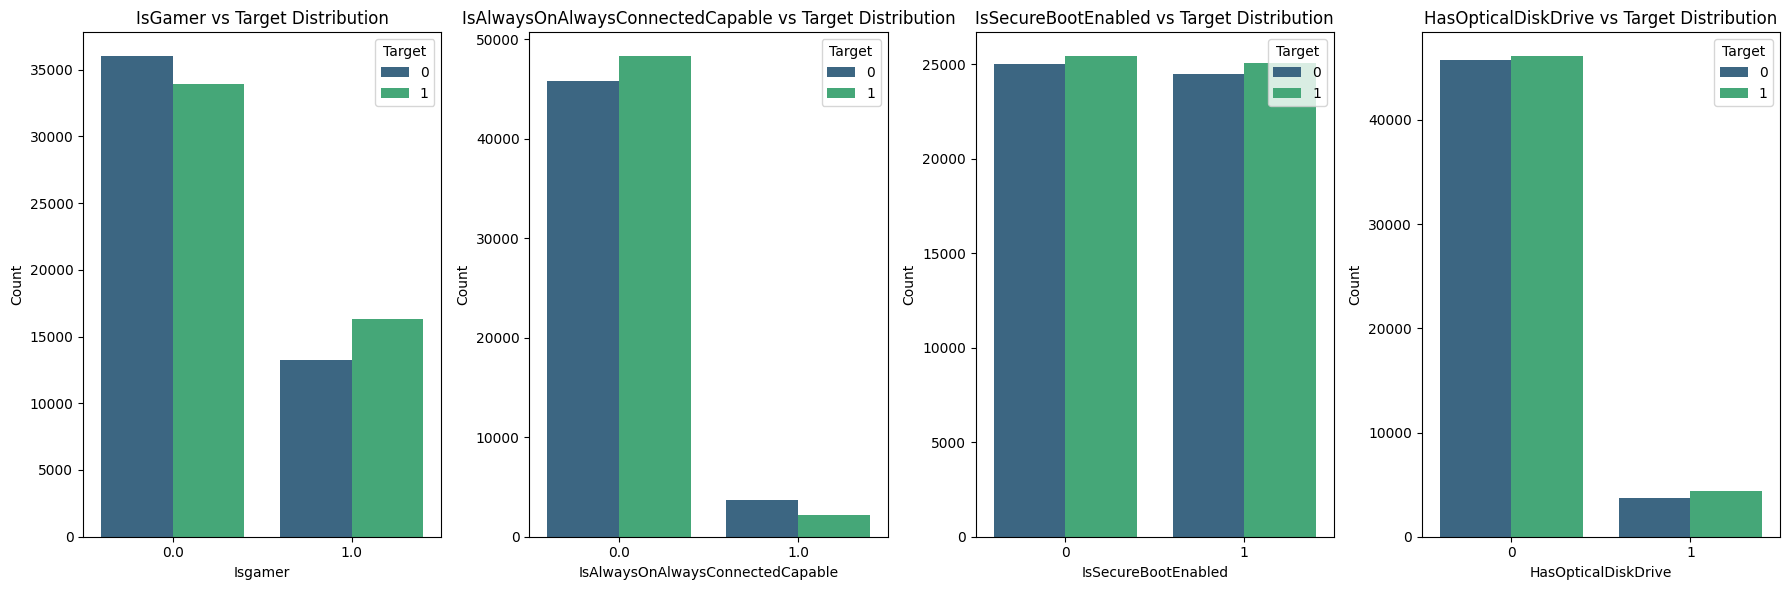

In [48]:
fig,axes=plt.subplots(1,4,figsize=(18,6))

sns.countplot(data=df,x='IsGamer',hue='target',palette='viridis',ax=axes[0])
axes[0].set_title('IsGamer vs Target Distribution')
axes[0].set_xlabel('Isgamer')
axes[0].set_ylabel('Count')
axes[0].legend(title='Target')

sns.countplot(data=df,x='IsAlwaysOnAlwaysConnectedCapable',hue='target',palette='viridis',ax=axes[1])
axes[1].set_title('IsAlwaysOnAlwaysConnectedCapable vs Target Distribution')
axes[1].set_xlabel('IsAlwaysOnAlwaysConnectedCapable')
axes[1].set_ylabel('Count')
axes[1].legend(title='Target')

sns.countplot(data=df,x='IsSecureBootEnabled',hue='target',palette='viridis',ax=axes[2])
axes[2].set_title('IsSecureBootEnabled vs Target Distribution')
axes[2].set_xlabel('IsSecureBootEnabled')
axes[2].set_ylabel('Count')
axes[2].legend(title='Target')

sns.countplot(data=df,x='HasOpticalDiskDrive',hue='target',palette='viridis',ax=axes[3])
axes[3].set_title('HasOpticalDiskDrive vs Target Distribution')
axes[3].set_xlabel('HasOpticalDiskDrive')
axes[3].set_ylabel('Count')
axes[3].legend(title='Target')

plt.tight_layout()
plt.show()

1. If a System has games installed in it, it has high chances of malware detection.
2. If a Sytem is not IsAlwaysOnAlwaysConnectedCapable, it has somewhat slight high chance of malware detection.
3. if a System is regardless if ISSecureBootEnabled on or off it has slighest higher chance of malware detection so we can drop this column as it is off no use in model training.
4. if a System is regardless if having HasOpticalDiskDrive or not it has slighest higher chance of malware detection so we can drop this column.

<Axes: >

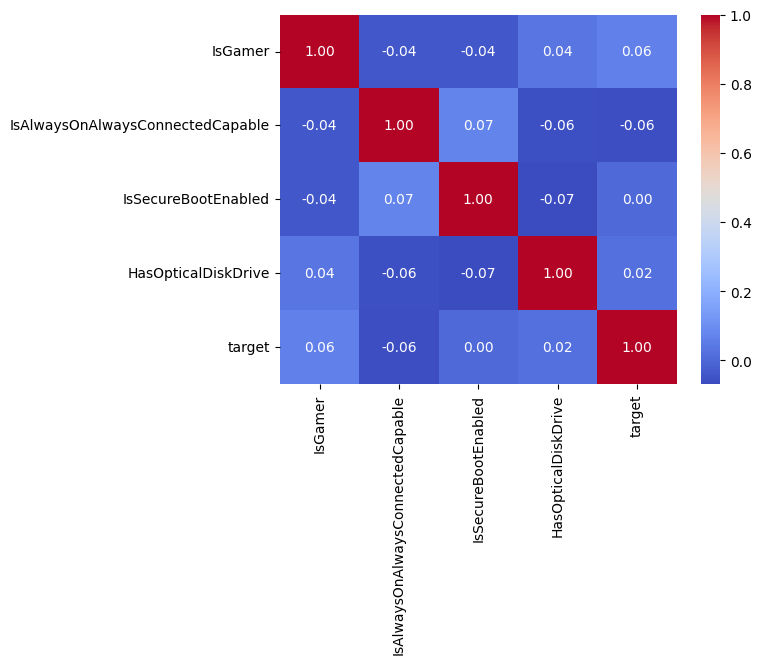

In [49]:
cols=df[['IsGamer','IsAlwaysOnAlwaysConnectedCapable','IsSecureBootEnabled','HasOpticalDiskDrive','target']].corr()
sns.heatmap(cols,annot=True,cmap='coolwarm',fmt='.2f')

In [50]:
df=df.drop(columns=['IsSecureBootEnabled','HasOpticalDiskDrive'])
test_df=test_df.drop(columns=['IsSecureBootEnabled','HasOpticalDiskDrive'])

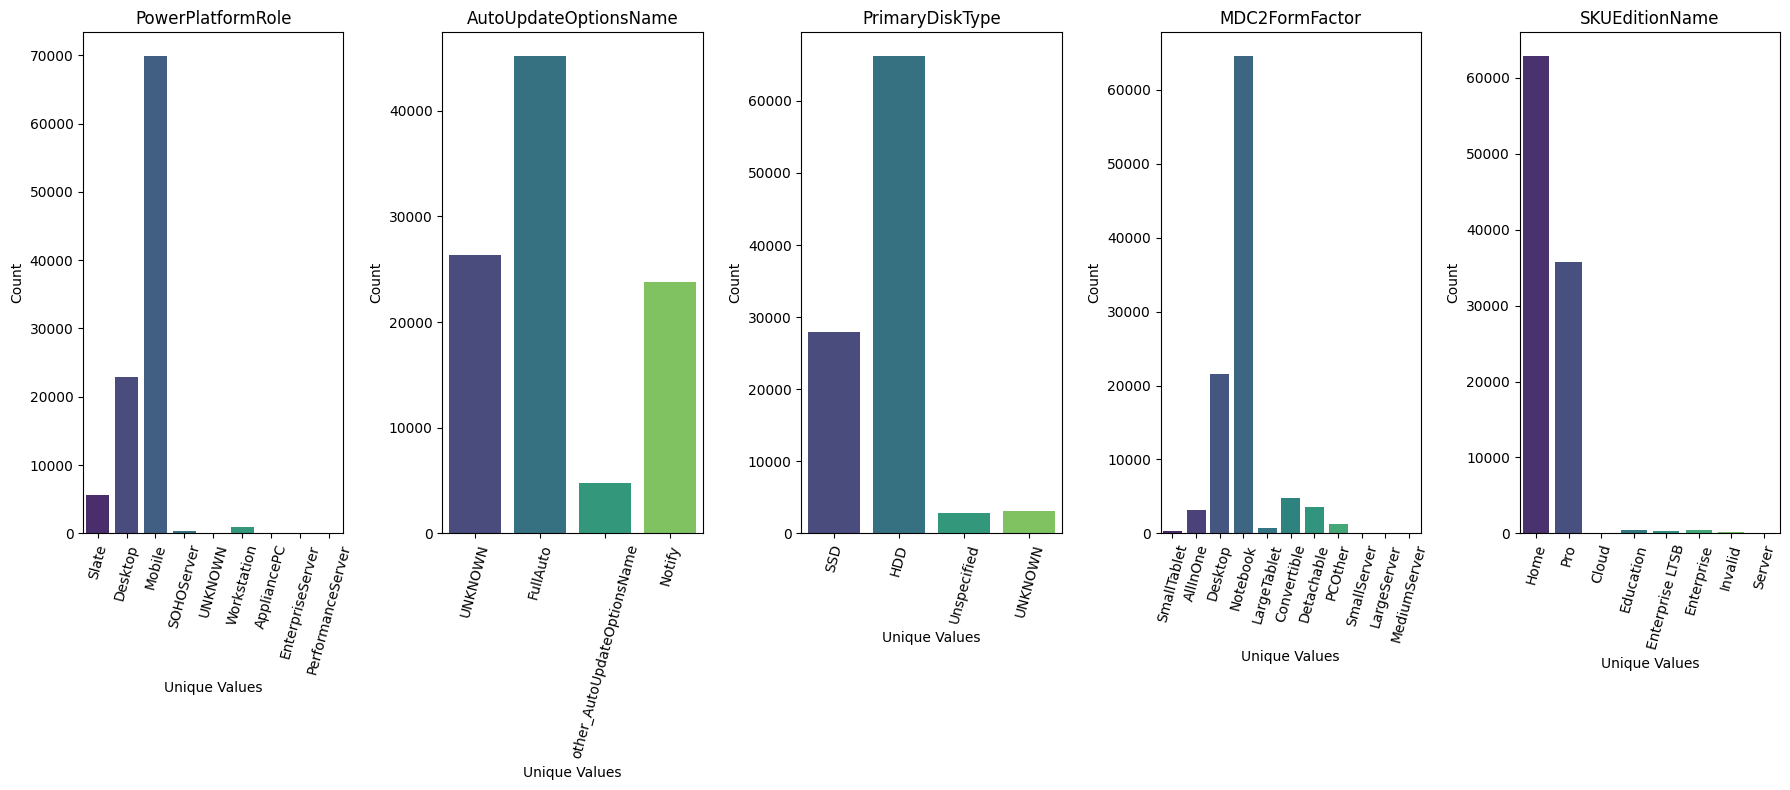

In [51]:
cols=['PowerPlatformRole','AutoUpdateOptionsName','PrimaryDiskType','MDC2FormFactor','SKUEditionName']
fig,axes=plt.subplots(1,5,figsize=(18,8))

for i,col in enumerate(cols):
    sns.countplot(data=df,x=col,ax=axes[i],palette='viridis')
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('Unique Values')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=75)
    

plt.tight_layout()
plt.show()

- **SKUEditionName** -> Most of the Users have Home & Pro as their SKUEditionName.
- **PowerPlatformRole** -> Most of the sysytem has Slate,Desktop & Mobile as their PowerPlatformRole
- **MDC2FormFactor** -> Most of the sysytem has Notebook,Desktop as their MDC2FormFactor
- **PrimaryDiskType** ->Most of the sysytem has HDD,SSD as their PrimaryDiskType
- **AutoUpdateOptionsName**-> Most of the sysytem has FullAUTO,UNknown, Notify as their AutoUpdateOptionsName

- **SKUEditionName** -> Combine other Categories apart from Home and Pro to avoid model complexity and overfitting
- **PowerPlatformRole** -> Combine other Categories apart from Slate, Desktop& Mobile to avoid the complexity and to simplify the process
- **MDC2FormFactor** -> Combine other Categories apart from Notebook,Desktop,Convertible,Detachable,AllInOne and combine which have less 2% of total value.
- **PrimaryDiskType** -> Combining those categories which have less than 5% of total value. HDD,SSD,other_PrimaryDiskType.

In [52]:
df['SKUEditionName']=df['SKUEditionName'].where(df['SKUEditionName'].isin(['Home','Pro']),'other_SKUEditionName')
test_df['SKUEditionName']=test_df['SKUEditionName'].where(test_df['SKUEditionName'].isin(['Home','Pro']),'other_SKUEditionName')

df['PowerPlatformRole']=df['PowerPlatformRole'].where(df['PowerPlatformRole'].isin(['Slate','Mobile','Desktop']),'other_PowerPlatformRole')
test_df['PowerPlatformRole']=test_df['PowerPlatformRole'].where(test_df['PowerPlatformRole'].isin(['Slate','Mobile','Desktop']),'other_PowerPlatformRole')

df['PrimaryDiskType']=df['PrimaryDiskType'].where(df['PrimaryDiskType'].isin(['HDD','SSD']),'other_PrimaryDiskType')
test_df['PrimaryDiskType']=test_df['PrimaryDiskType'].where(test_df['PrimaryDiskType'].isin(['HDD','SSD']),'other_PrimaryDiskType')

df['MDC2FormFactor']=df['MDC2FormFactor'].where(df['MDC2FormFactor'].isin(['Notebook','Desktop','Convertible','Detachable','AllInOne']),'other_MDC2FormFactor')
test_df['MDC2FormFactor']=test_df['MDC2FormFactor'].where(test_df['MDC2FormFactor'].isin(['Notebook','Desktop','Convertible','Detachable','AllInOne']),'other_MDC2FormFactor')

In [53]:
df['ChassisType'].value_counts()

ChassisType
Notebook               59459
Desktop                20818
Laptop                  7811
Portable                4126
AllinOne                2269
Convertible              966
MiniTower                952
Detachable               611
LowProfileDesktop        559
Other                    535
HandHeld                 526
UNKNOWN                  454
SpaceSaving              324
Tablet                   163
Tower                    129
MainServerChassis        111
Unknown                   59
LunchBox                  39
MiniPC                    34
RackMountChassis          17
BusExpansionChassis       13
SubNotebook               11
0                          4
30                         4
CompactPCI                 1
SubChassis                 1
MultisystemChassis         1
35                         1
Name: count, dtype: int64

**ChassisType**-> Combined those categories which have less than 3% of total value count.

In [54]:
df['ChassisType']=df['ChassisType'].where(df['ChassisType'].isin(['Notebook','Desktop','Laptop','Portable',]),'other_ChassisType')
test_df['ChassisType']=test_df['ChassisType'].where(test_df['ChassisType'].isin(['Notebook','Desktop','Laptop','Portable']),'other_ChassisType')

In [55]:
test_df['ChassisType'].value_counts(normalize=True)*100

ChassisType
Notebook             59.67
Desktop              20.44
other_ChassisType     7.99
Laptop                7.78
Portable              4.12
Name: proportion, dtype: float64

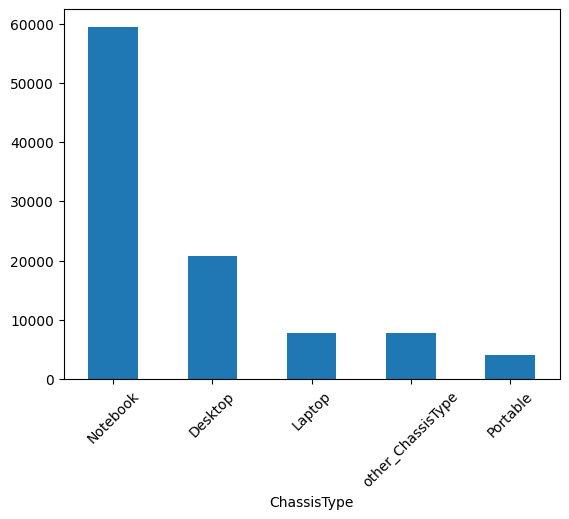

In [56]:
df['ChassisType'].value_counts().plot(kind='bar')
plt.tick_params(axis='x',rotation=45)

- **ChassisType**: I have combine some of the catrgoires with loer frequency as other_chassistype now, the most frequent value is notebook, followed by Desktop,laptop.

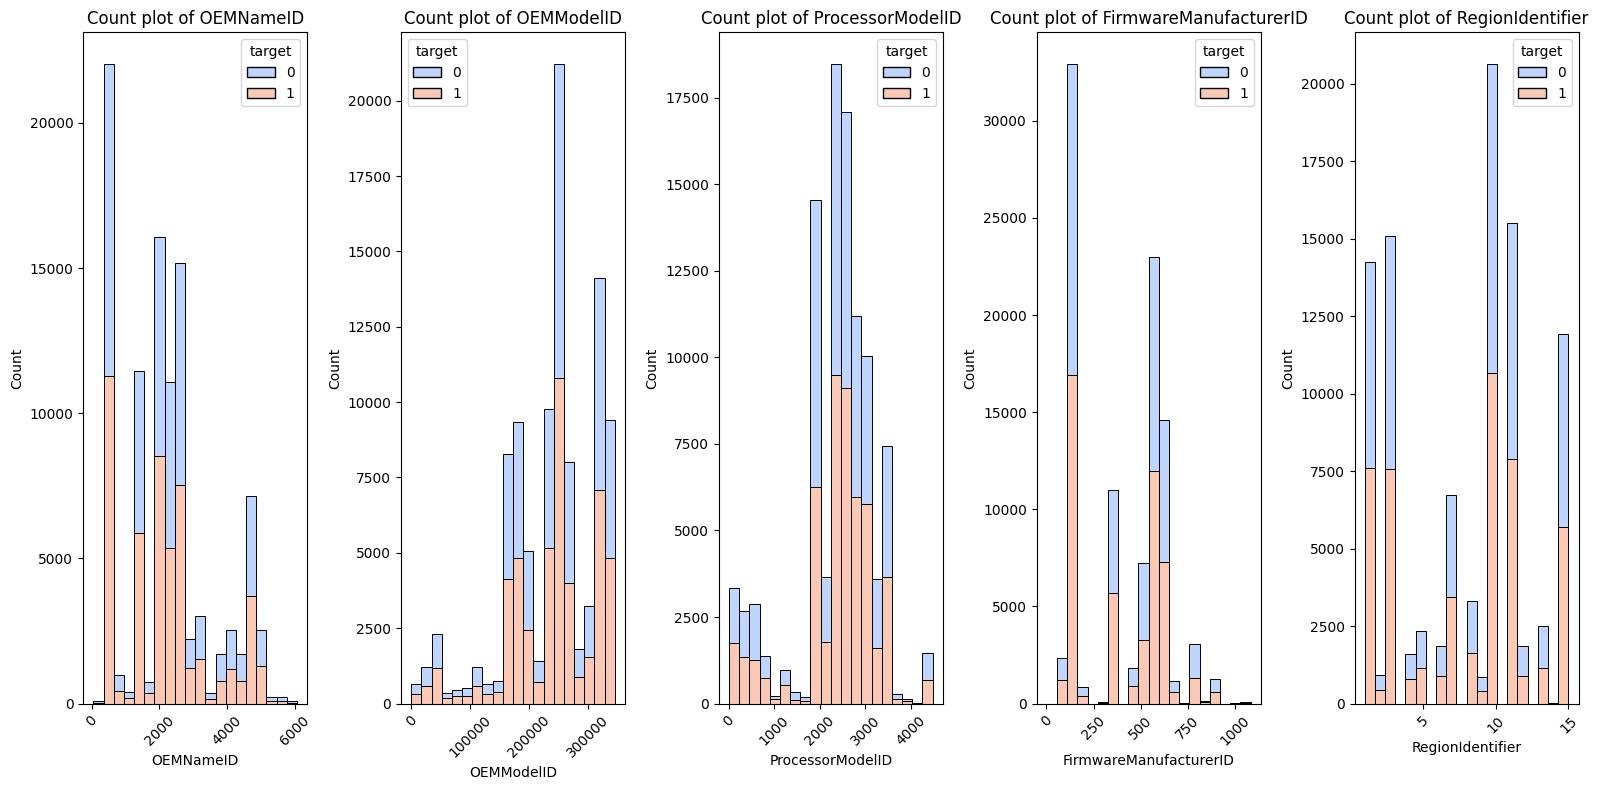

In [57]:
catty=['OEMNameID','OEMModelID','ProcessorModelID','FirmwareManufacturerID','RegionIdentifier']
fig,axes=plt.subplots(1,len(catty),figsize=(16,8))
for i,col in enumerate(catty):
    sns.histplot(data=df,x=col,bins=20,hue='target',ax=axes[i],palette='coolwarm',multiple='stack')
    axes[i].set_title(f'Count plot of {col}')
    axes[i].tick_params(axis='x',rotation=45)


plt.tight_layout()
plt.show()

- **OEMNameID,OEMModelID,ProcessorModelID,FirmwareManufacturerID,RegionIdentifier**: All of these columns are ID columns and as we can see from the histplot the distribution with target is equal across all the value, so we can drop all these columns as it adds no value in model prediction.

<Axes: >

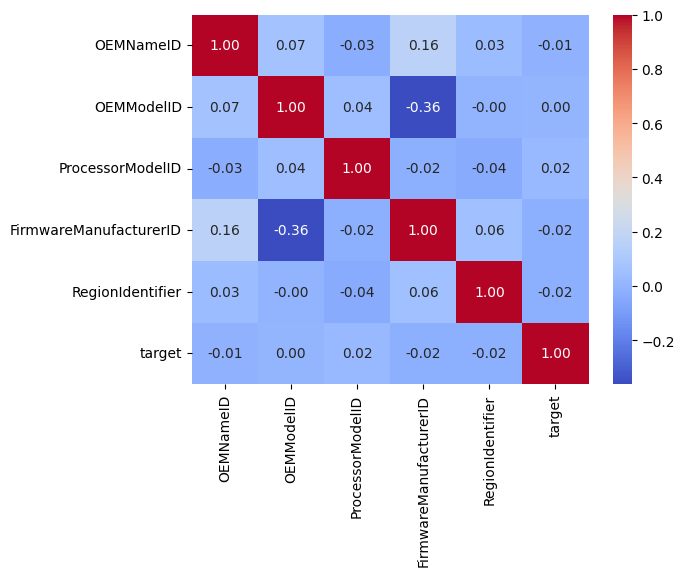

In [58]:
sns.heatmap(df[['OEMNameID','OEMModelID','ProcessorModelID','FirmwareManufacturerID','RegionIdentifier','target']].corr(),annot=True,cmap='coolwarm',fmt='.2f')

In [59]:
df=df.drop(columns=['OEMNameID','OEMModelID','ProcessorModelID','FirmwareManufacturerID'])
test_df=test_df.drop(columns=['OEMNameID','OEMModelID','ProcessorModelID','FirmwareManufacturerID'])

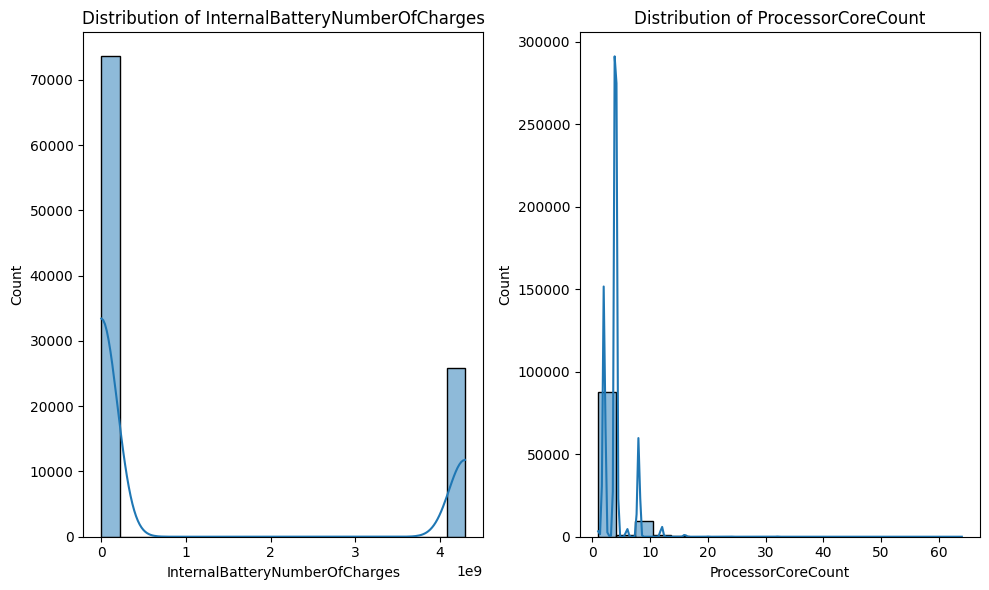

In [60]:
nummy=['InternalBatteryNumberOfCharges','ProcessorCoreCount']
fig,axes=plt.subplots(1,len(nummy),figsize=(10,6))
for i,col in enumerate(nummy):
    sns.histplot(df[col],kde=True,bins=20,ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

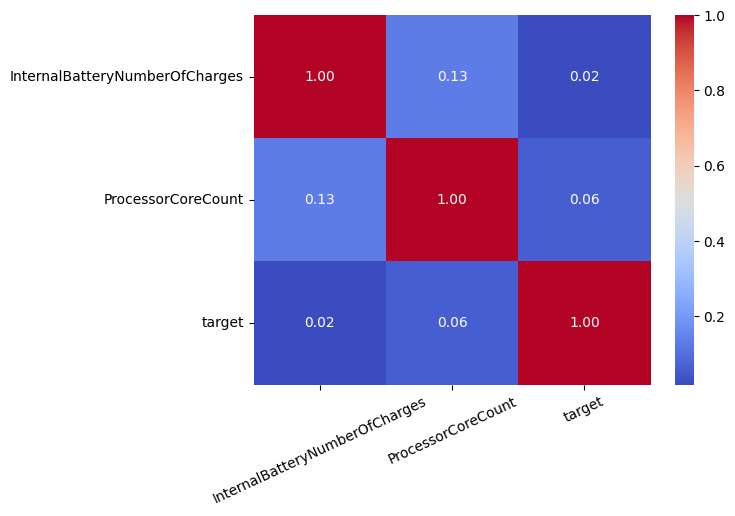

In [61]:
sns.heatmap(df[['InternalBatteryNumberOfCharges','ProcessorCoreCount','target']].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.tick_params(axis='x',rotation=25)
plt.show()

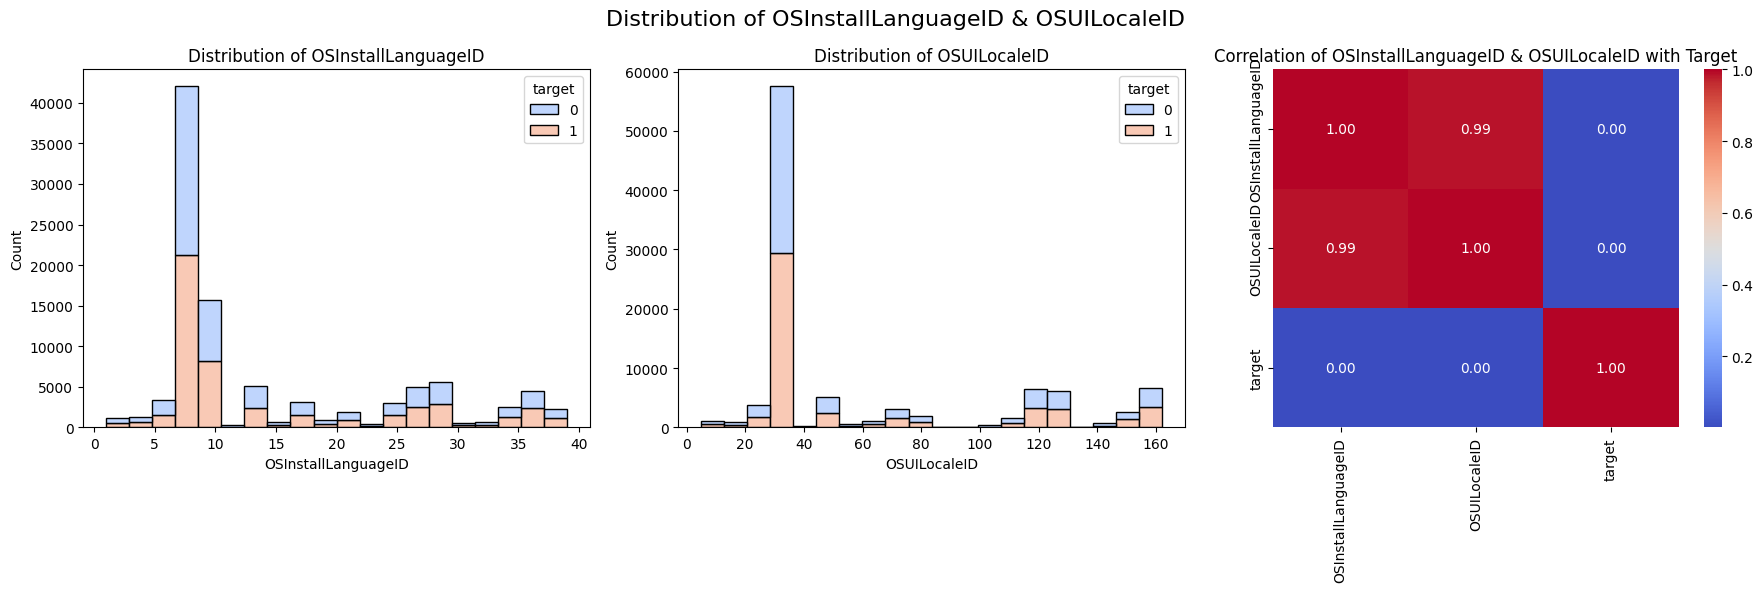

In [62]:
cols=['OSInstallLanguageID','OSUILocaleID']
fig,axes=plt.subplots(1,3,figsize=(18,6))
fig.suptitle("Distribution of OSInstallLanguageID & OSUILocaleID",fontsize=16)

for i, col in enumerate(cols):
    sns.histplot(data=df,x=col,bins=20,hue='target',ax=axes[i],palette='coolwarm',multiple='stack')
    axes[i].set_title(f'Distribution of {col}')

sns.heatmap(df[['OSInstallLanguageID','OSUILocaleID','target']].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation of OSInstallLanguageID & OSUILocaleID with Target")

plt.tight_layout()
plt.show()

- **OSInstallLanguageID,OSUILocaleID**-> These both columns are highly correlated to each other,we can drop OSInstallLanguageID as it has less number of unique values than OSUILocaleID.

In [63]:
df=df.drop(columns=['OSInstallLanguageID'])
test_df=test_df.drop(columns=['OSInstallLanguageID'])

Text(0.5, 1.0, 'Distribution of ProcessorManufacturerID with target column')

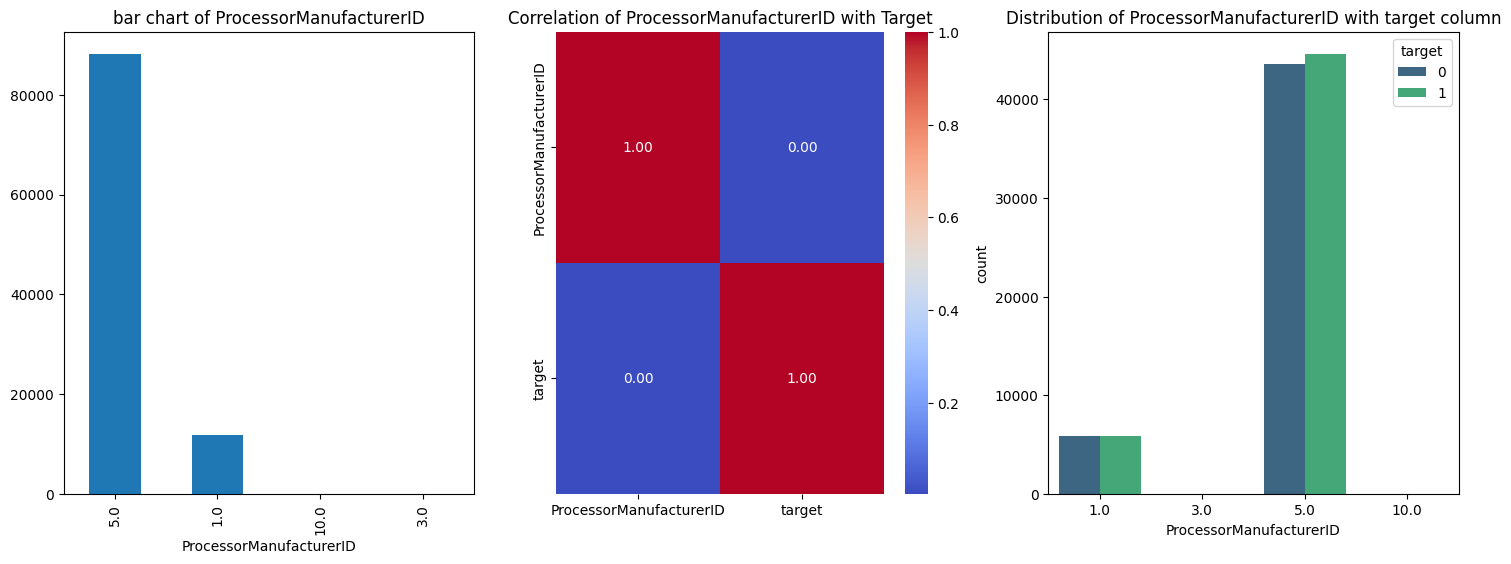

In [64]:
fig,axes=plt.subplots(1,3,figsize=(18,6))
df['ProcessorManufacturerID'].value_counts().plot(kind='bar',ax=axes[0])
axes[0].set_title('bar chart of ProcessorManufacturerID')
sns.heatmap(df[['ProcessorManufacturerID','target']].corr(),annot=True,cmap='coolwarm',fmt='.2f',ax=axes[1])
axes[1].set_title("Correlation of ProcessorManufacturerID with Target")
sns.countplot(data=df,x='ProcessorManufacturerID',hue='target',palette='viridis',ax=axes[2])
axes[2].set_title('Distribution of ProcessorManufacturerID with target column')

- **ProcessorManufacturerID**: There are Systems which have mostly 5 as their Processor Manufacture ID in which it has slighest higher chance of malware detection and for 1 it is equal. 

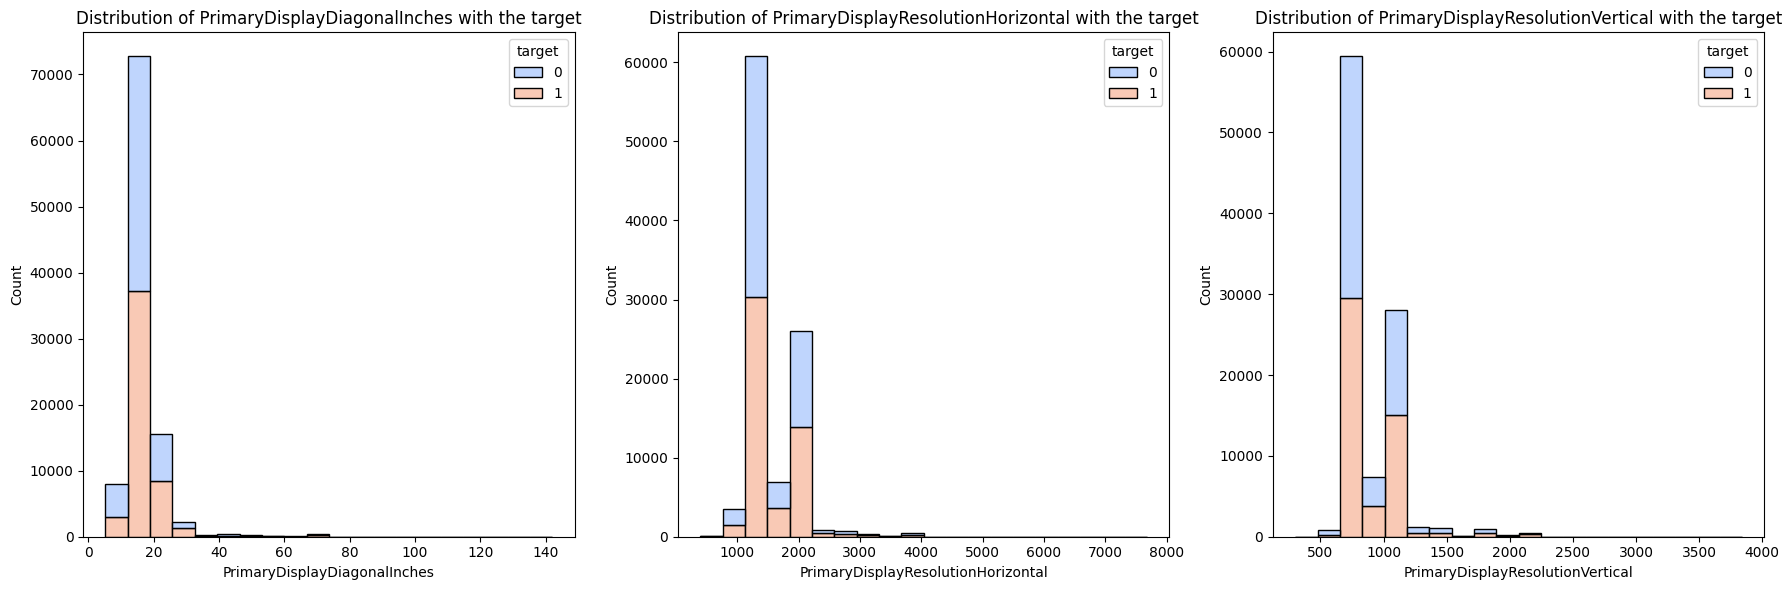

In [65]:
cols=['PrimaryDisplayDiagonalInches','PrimaryDisplayResolutionHorizontal','PrimaryDisplayResolutionVertical']
fig,axes=plt.subplots(1,3,figsize=(18,6))
for i, col in enumerate(cols):
    sns.histplot(data=df,x=col,bins=20,hue='target',ax=axes[i],palette='coolwarm',multiple='stack')
    axes[i].set_title(f'Distribution of {col} with the target')

plt.tight_layout()
plt.show()

- As we can see by looking at **PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical** there are mostly those System in the dataset which have 20inches as their PrimaryDisplayDiagonalInches, and between 1000-2000 as their PrimaryDisplayHorizontalResolution and between 500-1500 as their PrimaryDisplayVerticalResolution.

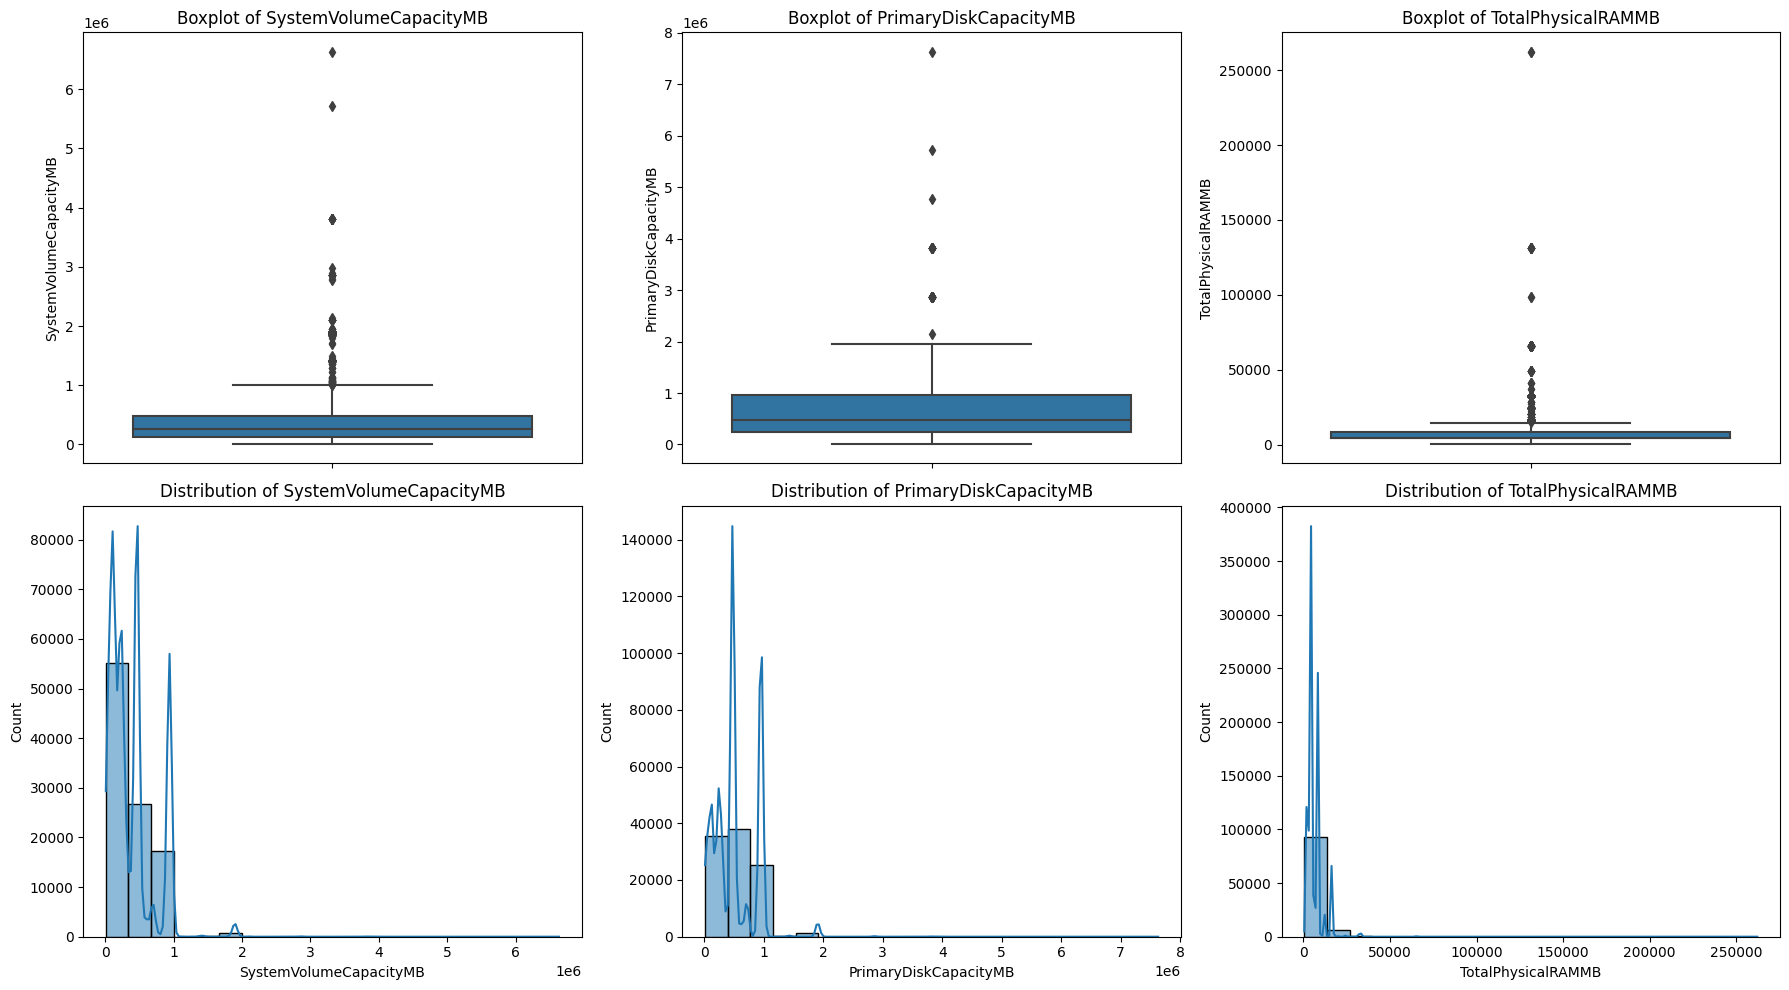

In [66]:
cols=['SystemVolumeCapacityMB','PrimaryDiskCapacityMB','TotalPhysicalRAMMB']
fig,axes=plt.subplots(2,3,figsize=(18,10))
for i, col in enumerate(cols):
    sns.boxplot(y=df[col],ax=axes[0,i])
    axes[0,i].set_title(f'Boxplot of {col}')
for i, col in enumerate(cols):
    sns.histplot(df[col],bins=20,kde=True,ax=axes[1,i])
    axes[1,i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

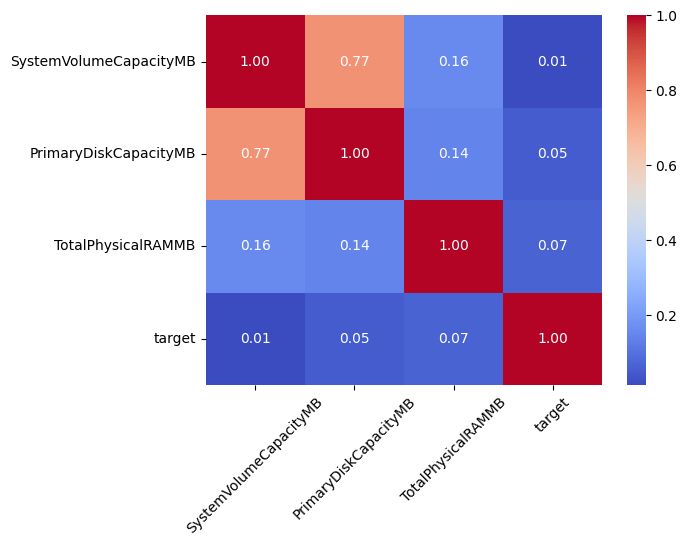

In [67]:
sns.heatmap(df[['SystemVolumeCapacityMB','PrimaryDiskCapacityMB','TotalPhysicalRAMMB','target']].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.tick_params(axis='x',rotation=45)
plt.show()

In [68]:
df=df.drop(columns=['MachineID','OSBuildNumber','IsSystemProtected'])
test_df=test_df.drop(columns=['MachineID','OSBuildNumber','IsSystemProtected'])

### Datetime

In [69]:
df['DateAS']=pd.to_datetime(df['DateAS'],errors='coerce')
df['DateOS']=pd.to_datetime(df['DateOS'],errors='coerce')
test_df['DateAS']=pd.to_datetime(test_df['DateAS'],errors='coerce')
test_df['DateOS']=pd.to_datetime(test_df['DateOS'],errors='coerce')

In [70]:
df['year_AS']=df['DateAS'].dt.year
df['month_AS']=df['DateAS'].dt.month
df['day_AS']=df['DateAS'].dt.day

test_df['year_AS']=test_df['DateAS'].dt.year
test_df['month_AS']=test_df['DateAS'].dt.month
test_df['day_AS']=test_df['DateAS'].dt.day

In [71]:
df['year_OS']=df['DateOS'].dt.year
df['month_OS']=df['DateOS'].dt.month
df['day_OS']=df['DateOS'].dt.day

test_df['year_OS']=test_df['DateOS'].dt.year
test_df['month_OS']=test_df['DateOS'].dt.month
test_df['day_OS']=test_df['DateOS'].dt.day

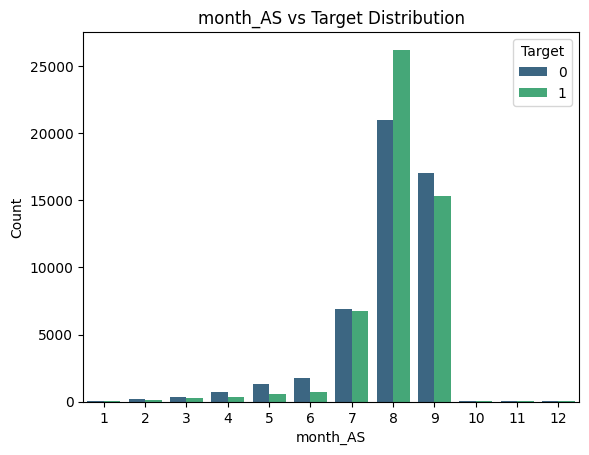

In [72]:
sns.countplot(data=df,x='month_AS',hue='target',palette='viridis')
plt.title('month_AS vs Target Distribution')
plt.xlabel('month_AS')
plt.ylabel('Count')
plt.legend(title='Target')

- As we can see in the month of august there are more number of chances of malware detection then it drop furthur onwards so we can keep this column (Month_AS)

In [73]:
df=df.drop(columns=['DateAS', 'DateOS'])
test_df=test_df.drop(columns=['DateAS', 'DateOS'])

### Preprocessing

In [74]:
df.head()

,EngineVersion,AppVersion,SignatureVersion,AntivirusConfigID,NumAntivirusProductsInstalled,CityID,LocaleEnglishNameID,Processor,OSProductSuite,OsPlatformSubRelease,OSBuildLab,SKUEditionName,IEVersionID,MDC2FormFactor,ProcessorCoreCount,ProcessorManufacturerID,PrimaryDiskCapacityMB,PrimaryDiskType,SystemVolumeCapacityMB,TotalPhysicalRAMMB,ChassisType,PrimaryDisplayDiagonalInches,PrimaryDisplayResolutionHorizontal,PrimaryDisplayResolutionVertical,PowerPlatformRole,InternalBatteryNumberOfCharges,NumericOSVersion,OSArchitecture,OSBranch,OSBuildNumberOnly,OSBuildRevisionOnly,OSSkuFriendlyName,OSInstallType,OSUILocaleID,AutoUpdateOptionsName,OSGenuineState,LicenseActivationChannel,FlightRing,FirmwareVersionID,IsAlwaysOnAlwaysConnectedCapable,IsGamer,RegionIdentifier,target,year_AS,month_AS,day_AS,year_OS,month_OS,day_OS
0,1.1.15200.1,4.18.1807.18075,1.275.1003.0,53447.0,1.0,120232.0,103,x86,768,rs1,14393.2214.x86fre.rs1_release_1.180402-1758,Home,98.0,other_MDC2FormFactor,4.0,5.0,15028.0,SSD,14348.0,1024.0,Notebook,8.0,800.0,1280.0,Slate,1.420000e+02,10.0.14393.2214,x86,rs1_release,14393,2214,CORE,Update,26,UNKNOWN,IS_GENUINE,Retail,Retail,21964.0,1.0,0.0,6.0,0,2018,9,10,2018.0,4.0,17.0
1,1.1.15100.1,4.18.1807.18075,1.273.1465.0,53447.0,1.0,112854.0,227,x64,256,rs4,17134.1.amd64fre.rs4_release.180410-1804,Pro,137.0,AllInOne,4.0,5.0,953869.0,HDD,952592.0,4096.0,other_ChassisType,19.4,1600.0,900.0,Desktop,4.294967e+09,10.0.17134.228,amd64,rs4_release,17134,228,PROFESSIONAL,UUPUpgrade,34,FullAuto,IS_GENUINE,OEM:DM,Retail,44548.0,0.0,0.0,10.0,1,2018,8,16,2018.0,8.0,14.0
2,1.1.15200.1,4.18.1807.18075,1.275.1546.0,53447.0,1.0,41759.0,103,x64,768,rs4,17134.1.amd64fre.rs4_release.180410-1804,Home,137.0,Desktop,4.0,5.0,228936.0,SSD,228321.0,8192.0,Desktop,24.0,1920.0,1080.0,Desktop,4.294967e+09,10.0.17134.285,amd64,rs4_release,17134,285,CORE,Reset,26,FullAuto,IS_GENUINE,OEM:NONSLP,Retail,9414.0,0.0,1.0,6.0,1,2018,9,20,2018.0,9.0,11.0
3,1.1.15200.1,4.12.17007.18011,1.275.1141.0,46413.0,2.0,19507.0,74,x64,768,rs2,15063.0.amd64fre.rs2_release.170317-1834,Home,108.0,Notebook,4.0,5.0,1907729.0,HDD,1890776.0,8192.0,Notebook,15.5,1366.0,768.0,Mobile,0.000000e+00,10.0.15063.850,amd64,rs2_release,15063,850,CORE,Upgrade,30,UNKNOWN,IS_GENUINE,OEM:DM,Retail,33060.0,0.0,0.0,12.0,1,2018,9,14,2018.0,1.0,3.0
4,1.1.15200.1,4.13.17134.228,1.275.1283.0,40466.0,2.0,117801.0,42,x86,256,rs4,17134.1.x86fre.rs4_release.180410-1804,Pro,137.0,Desktop,2.0,5.0,305245.0,HDD,52804.0,2048.0,Desktop,20.0,1600.0,900.0,Desktop,4.294967e+09,10.0.17134.285,x86,rs4_release,17134,285,PROFESSIONAL,UUPUpgrade,158,FullAuto,IS_GENUINE,Retail,Retail,13224.0,0.0,1.0,7.0,0,2018,9,15,2018.0,9.0,11.0


In [75]:
len(df.columns)

49

In [76]:
len(test_df.columns)

48

In [77]:
df.columns

Index(['EngineVersion', 'AppVersion', 'SignatureVersion', 'AntivirusConfigID',
       'NumAntivirusProductsInstalled', 'CityID', 'LocaleEnglishNameID',
       'Processor', 'OSProductSuite', 'OsPlatformSubRelease', 'OSBuildLab',
       'SKUEditionName', 'IEVersionID', 'MDC2FormFactor', 'ProcessorCoreCount',
       'ProcessorManufacturerID', 'PrimaryDiskCapacityMB', 'PrimaryDiskType',
       'SystemVolumeCapacityMB', 'TotalPhysicalRAMMB', 'ChassisType',
       'PrimaryDisplayDiagonalInches', 'PrimaryDisplayResolutionHorizontal',
       'PrimaryDisplayResolutionVertical', 'PowerPlatformRole',
       'InternalBatteryNumberOfCharges', 'NumericOSVersion', 'OSArchitecture',
       'OSBranch', 'OSBuildNumberOnly', 'OSBuildRevisionOnly',
       'OSSkuFriendlyName', 'OSInstallType', 'OSUILocaleID',
       'AutoUpdateOptionsName', 'OSGenuineState', 'LicenseActivationChannel',
       'FlightRing', 'FirmwareVersionID', 'IsAlwaysOnAlwaysConnectedCapable',
       'IsGamer', 'RegionIdentifier', 'targe

### Splitting the data

In [78]:
X = df.drop(columns=['target'])
y = df['target']

- spliting the dataset into validation & training

In [79]:
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)

In [80]:
X_train.shape,X_val.shape

((80000, 48), (20000, 48))

In [81]:
cat_cols=X.select_dtypes(include=['object']).columns
num_cols=X.select_dtypes(include=['int','float']).columns

In [82]:
cat_pipeline=Pipeline(steps=[
    ('imputation',SimpleImputer(strategy='most_frequent')),
    ('onehotencoder',OneHotEncoder(sparse=False,drop='first',handle_unknown='ignore'))
])
cat_pipeline

Pipeline(steps=[('imputation', SimpleImputer(strategy='most_frequent')),
                ('onehotencoder',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse=False))])

In [83]:
num_pipeline=Pipeline(steps=[
    ('imputation',SimpleImputer(strategy='mean')),
    ('scaling',StandardScaler())
])
num_pipeline

Pipeline(steps=[('imputation', SimpleImputer()), ('scaling', StandardScaler())])

In [84]:
transformer=ColumnTransformer(transformers=[
    ('cat',cat_pipeline,cat_cols),
    ('num',num_pipeline,num_cols)
])
transformer

ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('imputation',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse=False))]),
                                 Index(['EngineVersion', 'AppVersion', 'SignatureVersion', 'Processor',
       'OsPlatformSubRelease', 'OSBuildLab', 'SKUEditionName',
       'MDC2FormFactor', 'PrimaryDiskType',...
       'PrimaryDisplayDiagonalInches', 'PrimaryDisplayResolutionHorizontal',
       'PrimaryDisplayResolutionVertical', 'InternalBatteryNumberOfCharges',
       'OSBuildNumberOnly', 'OSBuildRevisionOnly', 'OSUILocaleID',
       'FirmwareVersionID', 'IsAlwaysOnAlwaysConnectedCapable', 'IsGamer',
       'RegionIdentifier', 'year_AS', 'month_AS', 'day_AS', 'year_OS',
       'month_OS', 'day_OS'],
      dtype='object'))])

In [85]:
X_train_pro=transformer.fit_transform(X_train)

In [86]:
X_val_pro=transformer.transform(X_val)
test_df_pro=transformer.transform(test_df)

In [87]:
X_train=pd.DataFrame(X_train_pro)
X_val=pd.DataFrame(X_val_pro)
test_df=pd.DataFrame(test_df_pro)

## Model Training on whole dataset
- Logistic Regression: Trained the whole dataset with Logistic Regression setting max_iter=10000 and got the score 0.6078.

In [88]:
model=LogisticRegression(random_state=42,max_iter=10000)
model.fit(X_train,y_train)
y_pred=model.predict(X_val)
score=accuracy_score(y_val,y_pred)
score

0.6078

In [89]:
X_train.shape

(80000, 3261)

# Feature Selection and Model Training

## SelectFromModel (Feature Selection)
- **f_classif**: setting k=200 and it will select top 200 feature because 200 is good and it will lead to information loss and it will be fast to train.

In [90]:
selector=SelectKBest(f_classif,k=200)
X_train_kbest=selector.fit_transform(X_train,y_train)
X_train_kbest.shape

(80000, 200)

In [91]:
X_val_kbest=selector.transform(X_val)
X_val_kbest.shape

(20000, 200)

In [92]:
X_test_kbest=selector.transform(test_df)
X_test_kbest.shape

(10000, 200)

- **After using f_classif for feature selection, Trained the Model using Logistic Regression and the there is not much difference in accuracy**

In [93]:
model=LogisticRegression(random_state=42,max_iter=10000)
model.fit(X_train_kbest,y_train)
y_pred=model.predict(X_val_kbest)
score=accuracy_score(y_val,y_pred)
score

0.6087

- **RFE**: Tried the RFE for feature selection but it was taking hours.

In [94]:
# dtc=DecisionTreeClassifier()
# selector1=RFE(dtc, n_features_to_select=100, step=10)
# X_train_rfe=selector1.fit_transform(X_train,y_train)
# X_val_rfe=selector1.transform(X_val)

### XGBClassifier (SELECTFROMMODEL)
- **Used XGBClassifier as the estimator and set max_features=200**

In [95]:
xgbc=XGBClassifier()
selector2=SelectFromModel(xgbc,max_features=200)
X_train_xgbc=selector2.fit_transform(X_train,y_train)
X_train_xgbc.shape

(80000, 200)

In [96]:
X_val_xgbc=selector2.transform(X_val)
X_val_xgbc.shape

(20000, 200)

In [97]:
X_test_xgbc=selector2.transform(test_df)
X_test_xgbc.shape

(10000, 200)

- **Trained that dataset which selected top 200 features using xgbclassifier as the estimator and train that dataset on LogisticRegression with slightest increase in accuracy.**

In [98]:
model=LogisticRegression(random_state=42,max_iter=10000)
model.fit(X_train_xgbc,y_train)
y_pred=model.predict(X_val_xgbc)
score=accuracy_score(y_val,y_pred)
score

0.60955

- **PCA**: Used Pca for reducing feature space and reducing dimnesion and set n_components=100 to get 100 features and using randomized_svd as solver because for high dimension data,it is more faster in pca and more efficient.

In [99]:
pca = PCA(n_components=100, svd_solver="randomized") 
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca=pca.transform(test_df)
X_train_pca.shape

(80000, 100)

### Now we are comparing selection models with different classifiers.
- We will only use max_features=200 because it is giving highest accuracy compare to other.
- We will test different feature selection models(RandomForestClassifier, DecisionTreeClassifier, XGBoostClassifier,ExtraTreeClassifier,GradientBoostingClassifer).
- We will be Training classifier on the selected features(RandomForestClassifier, DecisionTreeClassifier, XGBoostClassifier,ExtraTreeClassifier,GradientBoostingClassifer).
- We will campare the accuracy for different combinations.

#### Now we create a pipeline to do that

In [100]:
# feature_selectors ={
#     "RFC":RandomForestClassifier(random_state=42,n_jobs=-1),
#     "DTC":DecisionTreeClassifier(random_state=42),
#     "XGBC":XGBClassifier(),
#     "ETC":ExtraTreeClassifier(max_depth=20, min_samples_split=5, random_state=42),
#     "GBC":GradientBoostingClassifier(n_estimators=50, learning_rate=0.1,  max_depth=3, subsample=0.8, random_state=42)
# }

# classifiers ={
#     "RFC":RandomForestClassifier(random_state=42,n_jobs=-1),
#     "DTC":DecisionTreeClassifier(random_state=42),
#     "XGBC":XGBClassifier(),
#     "ETC":ExtraTreeClassifier(max_depth=20, min_samples_split=5, random_state=42),
#     "GBC":GradientBoostingClassifier(n_estimators=50, learning_rate=0.1,  max_depth=3, subsample=0.8, random_state=42)
# }
# def run_pipeline(feature_selector,classifier,max_features=200):
#     print(f"\n🔹 Feature Selection: {feature_selector} → Classifier: {classifier} (max_features={max_features})")
#     selector3=SelectFromModel(feature_selectors[feature_selector],max_features=max_features)

#     pipeline=Pipeline([
#         ('feature_selection',selector3),
#         ('classifier',classifiers[classifier])
#     ])
#     pipeline.fit(X_train, y_train)
#     y_pred=pipeline.predict(X_val)
#     accuracy = accuracy_score(y_val, y_pred)
#     print(f'Accuracy_Score {accuracy:.4f}')
#     return accuracy

# combinations = [
#     ('RFC', 'RFC'),
#     ('RFC', 'DTC'),
#     ('RFC', 'XGBC'),
#     ('RFC', 'ETC'),
#     ('RFC', 'GBC'),
    
#     ('DTC', 'RFC'),
#     ('DTC', 'DTC'),
#     ('DTC', 'XGBC'),
#     ('DTC', 'ETC'),
#     ('DTC', 'GBC'),
    
#     ('XGBC', 'RFC'),
#     ('XGBC', 'DTC'),
#     ('XGBC', 'XGBC'),
#     ('XGBC', 'ETC'),
#     ('XGBC', 'GBC'),
    
#     ('ETC', 'RFC'),
#     ('ETC', 'DTC'),
#     ('ETC', 'XGBC'),
#     ('ETC', 'ETC'),
#     ('ETC', 'GBC'),
    
#     ('GBC', 'RFC'),
#     ('GBC', 'DTC'),
#     ('GBC', 'XGBC'),
#     ('GBC', 'ETC'),
#     ('GBC', 'GBC'),
# ]

# for feature_selector, classifier in combinations:
#     run_pipeline(feature_selector, classifier)

- **Looking at these different accuracy score based on different feature selection model and Classifier,I will be using X_train_xgbc which consists of 200 features which was selected by XGBClassifier as estimator from SelectFromModel**

In [101]:
# feature_selectors ={
#     "RFC":RandomForestClassifier(),
#     "DTC":DecisionTreeClassifier(),
#     "XGBC":XGBClassifier(),
#     "ETC":ExtraTreeClassifier(max_depth=20, min_samples_split=5, random_state=42),
#     "GBC":GradientBoostingClassifier(n_estimators=50, learning_rate=0.1,  max_depth=3, subsample=0.8, random_state=42)
# }

# max_features=[50,100,200,300,400,500]

# def run_pipe2(feature_selector,max_feature):
#     print(f"\n🔹 Feature Selection: {feature_selector} classifier:Logistic Regression ->  (max_features={max_feature})")
#     selector3=SelectFromModel(feature_selectors[feature_selector],max_features=max_feature)

#     X_train_select=selector3.fit_transform(X_train,y_train)
#     X_val_select=selector3.transform(X_val)

#     model=LogisticRegression(random_state=42,max_iter=10000)
#     model.fit(X_train_select,y_train)
    
#     y_pred=model.predict(X_val_select)
#     score=accuracy_score(y_val,y_pred)
    
#     print(f'Accuracy_Score {score:.4f}')
#     return score


# for feature_selector in feature_selectors:
#     for max_feature in max_features:
#         run_pipe2(feature_selector,max_feature)

- **Training X_train_xgbc on SVC without tuning it.**
- It took nearly an hour to train, now we will train X_train_pca which have 100 feature and it will faster to train with SVC.

In [102]:
# model_svc=SVC()
# model_svc.fit(X_train_xgbc,y_train)
# model_svc.score(X_val_xgbc,y_val)

- **Trained X_train_pca with SVC with some hyparameters to train faster but the score got reduced from previous svc model**

In [103]:
# svc = SVC(kernel="rbf", C=1, gamma="scale", shrinking=False, tol=1e-3)
# svc.fit(X_train_pca, y_train)

In [104]:
# svc.score(X_val_pca,y_val)

- **Tried LineaSVC on X_train_pca to see if the accuracy increases from svc model, but it decrease we can draw conclusion that the dataset is somewhat is not linearly separable.**

In [105]:
svc = LinearSVC(C=1, max_iter=1000, dual=False)
svc.fit(X_train_pca, y_train)

LinearSVC(C=1, dual=False)

In [106]:
svc.score(X_val_pca,y_val)

0.60675

- **Trained the whole dataset on XGBClassifier**

In [107]:
xgb_model=XGBClassifier()
xgb_model.fit(X_train,y_train)
score=xgb_model.score(X_val,y_val)
score

0.61755

- **Now trained the X_train_xgbc on XGBClassifier as the estimator**

In [108]:
xgb_model=XGBClassifier()
xgb_model.fit(X_train_xgbc,y_train)
score=xgb_model.score(X_val_xgbc,y_val)
score

0.61965

- **RandomForestClassifier**

In [109]:
rfc_model=RandomForestClassifier()
rfc_model.fit(X_train_xgbc,y_train)
score=rfc_model.score(X_val_xgbc,y_val)
score

0.6124

- **ExtraTreeClassifer on X_train_kbest which is obtained f_classif**

In [110]:
etc = ExtraTreeClassifier(max_depth=20, min_samples_split=5, random_state=42)
etc.fit(X_train_kbest,y_train)
score=etc.score(X_val_kbest,y_val)
score

0.59155

- **ExtraTreeClassifier on X_train_xgbc**

In [111]:
etc = ExtraTreeClassifier(max_depth=20, min_samples_split=5, random_state=42)
etc.fit(X_train_xgbc,y_train)
score=etc.score(X_val_xgbc,y_val)
score

0.59115

- **GradientBoostingClassifier on X_train_xgbc and some hyperparameter as well because it was taking too much time**

In [112]:
gbc = GradientBoostingClassifier(
    n_estimators=50,  # Fewer trees for speed
    learning_rate=0.1,  
    max_depth=3,  # Shallow trees for faster training
    subsample=0.8,  # Uses 80% of data per tree for randomness
    random_state=42
)
gbc.fit(X_train_xgbc, y_train)
gbc_preds = gbc.predict(X_val_xgbc)
gbc_acc = accuracy_score(y_val, gbc_preds)
print(f"GradientBoostingClassifier Accuracy: {gbc_acc}")

GradientBoostingClassifier Accuracy: 0.61655


- **GradientBoostingClassifier on X_train_kbest**

In [113]:
gbc.fit(X_train_kbest, y_train)
gbc_preds = gbc.predict(X_val_kbest)
gbc_acc = accuracy_score(y_val, gbc_preds)
print(f"GradientBoostingClassifier Accuracy: {gbc_acc}")

GradientBoostingClassifier Accuracy: 0.61575


- **XGBclassifier on X_train_kbest with some hyparameter to check the whether the accuracy is increased or not but it somewhat same.**

In [114]:
model_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                          use_label_encoder=False, eval_metric="logloss")
xgb_model.fit(X_train_kbest,y_train)
score=xgb_model.score(X_val_kbest,y_val)
score

0.61805

- **XGBClassifier on X_train with same parameters as above.**

In [115]:
model_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                          use_label_encoder=False, eval_metric="logloss")
xgb_model.fit(X_train,y_train)
score=xgb_model.score(X_val,y_val)
score

0.61755

- **Now Voting Classifier with LogisiticRegression, RandomForestClassifer, DecisionTreeClassifier, XGBClassifier, ExtraTreeClassifier, GradientBoosting with vote='Hard'**

In [116]:
lr=LogisticRegression(random_state=42,max_iter=10000)
rfc=RandomForestClassifier(random_state=42,n_estimators=100)
dtc=DecisionTreeClassifier(random_state=42)
xgb=XGBClassifier(use_label_encoder=False, eval_metric="logloss",random_state=42)
etc=ExtraTreeClassifier(max_depth=20, min_samples_split=5, random_state=42)
gbc=GradientBoostingClassifier(n_estimators=50, learning_rate=0.1,  max_depth=3, subsample=0.8, random_state=42)

eclf1 = VotingClassifier(estimators=[
        ('lr', lr), ('rf', rfc), ('dtc', dtc),('xgb',xgb),('etc',etc),('gbc',gbc)], voting='hard')
eclf1.fit(X_train_xgbc,y_train)
y_pred=eclf1.predict(X_val_xgbc)
voting_acc = accuracy_score(y_val,y_pred)
print(f"VotingClassifier Accuracy: {voting_acc:.4f}")

VotingClassifier Accuracy: 0.6248


- **Same as above with Voting='Soft'**

In [117]:
eclf2 = VotingClassifier(estimators=[
        ('lr', lr), ('rf', rfc), ('dtc', dtc),('xgb',xgb),('etc',etc),('gbc',gbc)], voting='soft')

eclf2.fit(X_train_xgbc,y_train)
y_pred=eclf2.predict(X_val_xgbc)
voting_acc = accuracy_score(y_val,y_pred)
print(f"VotingClassifier Accuracy: {voting_acc:.4f}")

VotingClassifier Accuracy: 0.5996


- **Now checking the accuracy of every model that is in voting classifier for weights**

In [118]:
models = {"lr": lr, "rf": rfc, "dtc": dtc, "xgb": xgb, "etc": etc, "gbc": gbc}
for name, model in models.items():
    model.fit(X_train_xgbc, y_train)
    acc = model.score(X_val_xgbc, y_val)
    print(f"{name}: {acc}")

lr: 0.60955
rf: 0.6175
dtc: 0.54725
xgb: 0.61965
etc: 0.59115
gbc: 0.61655


- **As we can see that xgb is highest, followed by gbc and rfc, so weights will set according to this, with xgb highest weight.**

In [119]:
lr=LogisticRegression(random_state=42,max_iter=10000)
rfc=RandomForestClassifier(random_state=42,n_estimators=100)
dtc=DecisionTreeClassifier(random_state=42)
xgb=XGBClassifier(use_label_encoder=False, eval_metric="logloss",random_state=42)
etc=ExtraTreeClassifier(max_depth=20, min_samples_split=5, random_state=42)
gbc=GradientBoostingClassifier(n_estimators=50, learning_rate=0.1,  max_depth=3, subsample=0.8, random_state=42)


eclf_hard = VotingClassifier(
    estimators=[
        ("lr", lr),
        ("rf", rfc),
        ("xgb", xgb),
        ("gbc", gbc),
        ("etc", etc)  
    ],
    voting="hard",
    weights=[1, 2, 3, 3, 1]  # Higher weight for best models (XGB, GBC), lower for ETC
)
eclf_hard.fit(X_train_xgbc,y_train)
y_pred=eclf_hard.predict(X_val_xgbc)
voting_acc = accuracy_score(y_val,y_pred)
print(f"VotingClassifier Accuracy: {voting_acc:.4f}")

VotingClassifier Accuracy: 0.6250


- **Training same model on X_train**

In [120]:
# eclf_hard_1.fit(X_train,y_train)
# y_pred=eclf_hard_1.predict(X_val)
# voting_acc = accuracy_score(y_val,y_pred)
# print(f"VotingClassifier Accuracy: {voting_acc:.4f}")

In [121]:
# eclf_hard_2 = VotingClassifier(
#     estimators=[
#         ("lr", lr),
#         ("rf", rfc),
#         ("xgb", xgb),
#         ("gbc", gbc),
#         ("etc", etc)  
#     ],
#     voting="hard",
#     weights=[1, 3, 4, 2, 1]
# )
# eclf_hard_2.fit(X_train,y_train)
# y_pred=eclf_hard_2.predict(X_val)
# voting_acc = accuracy_score(y_val,y_pred)
# print(f"VotingClassifier Accuracy: {voting_acc:.4f}")

# Hyperparameter Tuning

- **SVC**
1. Now we will train our X_train_pca with SVC and will tune the SVC.
2. Will try to optimize it to speed up the process.
3. I will not use gridsearchcv , randomizedsearchcv because it will take to too much time in SVC.

In [122]:
# svc = SVC(kernel="rbf", C=1, gamma="scale", shrinking=False,tol=1e-3)
# svc.fit(X_train_pca, y_train)

- **XGBoostClassifier**: HYperparameter Tuning the XGBClassifier using GridSearchCV with learning_rate and max_depth as params, to get best params and training it on X_train_xgbc dataset.

In [123]:
params = {
    "learning_rate": [0.3,0.1,0.2,0.5],
    "max_depth": [6,4,8,10,15],
    
}
grid_search=GridSearchCV(estimator=XGBClassifier(use_label_encoder=False, eval_metric="logloss"),param_grid=params,verbose=3,n_jobs=-1,cv=5)
grid_search.fit(X_train_xgbc,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...one,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.3, 0.1, 0.2, 0.5],
                         'max_depth': [6, 4, 8, 10, 15]},
             verbose=3)

In [124]:
grid_search.best_params_,grid_search.best_score_

({'learning_rate': 0.2, 'max_depth': 6}, 0.6242624999999998)

* Doing Same but with X_train dataset and commented this because of time.

In [125]:
# params = {
#     "learning_rate": [0.3,0.1,0.2,0.5],
#     "max_depth": [6,4,8,10,15],
    
# }
# grid_search=GridSearchCV(estimator=XGBClassifier(use_label_encoder=False, eval_metric="logloss"),param_grid=params,verbose=3,n_jobs=-1,cv=3)
# grid_search.fit(X_train,y_train)

In [126]:
# grid_search.best_params_,grid_search.best_score_

* Now adding more params like n_estimators, subsample and gamma for some regularization and min_child weight to see if the score increases will train on X_train_xgbc.

In [127]:
params = {
    "learning_rate": [0.03,0.05],
    "max_depth": [3, 4, 5],  # Deeper trees slow training
    "n_estimators": [50,100, 200],  # 300 removed to speed up tuning
    "subsample": [0.7,0.8, 0.9],  # 0.7 removed (less variance)
    "gamma": [0, 0.1],  # Removed 0.2 to reduce search space
    "min_child_weight": [1, 3]  # Removed 5 (less regularization needed)
}

grid_search=GridSearchCV(estimator=XGBClassifier(use_label_encoder=False,eval_metric='logloss'),param_grid=params,cv=3,verbose=4,n_jobs=-1,scoring='accuracy')
grid_search.fit(X_train_xgbc,y_train)

Fitting 3 folds for each of 216 candidates, totalling 648 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'gamma': [0, 0.1], 'learning_rate': [0.03, 0.05],
                         'max_depth': [3, 4, 5], 'min_child_weight': [1, 3],
                         'n_estimators': [50, 100, 200],
                         'subsample': [0.7, 0.8, 0.9]},
             scoring='accuracy', verbose=4)

In [128]:
grid_search.best_params_,grid_search.best_score_

({'gamma': 0,
  'learning_rate': 0.05,
  'max_depth': 5,
  'min_child_weight': 1,
  'n_estimators': 200,
  'subsample': 0.8},
 0.6228499976946118)

* REfining the params to speed up the process.

In [129]:
params = {
    "learning_rate": [0.03,0.05],
    "max_depth": [3, 4, 5],  # Deeper trees slow training
    "n_estimators": [100, 200],  # 300 removed to speed up tuning
    "subsample": [0.7,0.8],  # 0.7 removed (less variance)
    "colsample_bytree": [0.8, 0.9],  # Keep higher feature subsampling
    "gamma": [0, 0.1],  # Removed 0.2 to reduce search space
    "min_child_weight": [1, 3]  # Removed 5 (less regularization needed)
}

grid_search=GridSearchCV(estimator=XGBClassifier(use_label_encoder=False,eval_metric='logloss'),param_grid=params,cv=3,verbose=3,n_jobs=-1,scoring='accuracy')
grid_search.fit(X_train_xgbc,y_train)

Fitting 3 folds for each of 192 candidates, totalling 576 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 0.9], 'gamma': [0, 0.1],
                         'learning_rate': [0.03, 0.05], 'max_depth': [3, 4, 5],
                         'min_child_weight': [1, 3], 'n_estimators': [100, 200],
                         'subsample': [0.7, 0.8]},
             scoring='accuracy', verbose=3)

In [130]:
grid_search.best_params_,grid_search.best_score_

({'colsample_bytree': 0.8,
  'gamma': 0,
  'learning_rate': 0.05,
  'max_depth': 5,
  'min_child_weight': 3,
  'n_estimators': 200,
  'subsample': 0.8},
 0.6228374983196157)

* Now using RandomizedSearchCV for XgbClassifier training on X_train_xgbc dataset.

In [131]:
params = {
    "learning_rate": [0.01, 0.03, 0.05, 0.1],  # Step size
    "max_depth": [3, 4, 5],  # Tree depth
    "n_estimators": [100, 150, 200],  # Number of trees
    "subsample": [0.7, 0.8, 0.9],  # Row sampling
    "colsample_bytree": [0.7, 0.8, 0.9],  # Feature sampling
    "gamma": [0.1, 0.2],  # Min loss required for a split
    "min_child_weight": [1, 3, 5],  # Minimum sum of instance weights in a child node
}
random_search=RandomizedSearchCV(estimator=XGBClassifier(use_label_encoder=False,eval_metric='logloss'),param_distributions=params,verbose=3,n_jobs=-1,cv=5,n_iter=20,scoring='accuracy')
random_search.fit(X_train_xgbc,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9],
                                        'gamma': [0.1, 0.2],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 150, 200],
                                        'subsample': [0.7, 0.8, 0.9]},
                   scoring='accuracy', verbose=3)

In [132]:
random_search.best_params_,random_search.best_score_

({'subsample': 0.9,
  'n_estimators': 200,
  'min_child_weight': 5,
  'max_depth': 5,
  'learning_rate': 0.1,
  'gamma': 0.2,
  'colsample_bytree': 0.9},
 0.6238625)

- **Best**

In [133]:
xgb_final = XGBClassifier(
    subsample=0.8,
    n_estimators=200,
    min_child_weight=1,
    max_depth=5,
    learning_rate=0.1,
    gamma=0.1,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
xgb_final.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [134]:
y_pred = xgb_final.predict(X_val)
score = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {score:.4f}")

Validation Accuracy: 0.6239


In [135]:
y_test_pred = xgb_final.predict(test_df)
# Save predictions to CSV (for submission)

In [136]:
# xgb_random_params = {
#     "n_estimators": [200, 300],   # Number of boosting rounds
#     "learning_rate": [0.01, 0.05,],  # Step size for updates
#     "max_depth": [3, 4],  # Tree depth (higher = more complexity)
#     "subsample": [0.7, 0.8],  # % of samples used per tree
#     "colsample_bytree": [0.7, 0.8],  # % of features used per tree
#     "gamma": [0, 0.1, 0.2],  # Minimum loss reduction for further splits
#     "min_child_weight": [3, 5],  # Minimum sum of weights needed for child nodes
#     "reg_alpha": [0.01, 0.1],  # L1 regularization (reduces complexity)
#     "reg_lambda": [1, 10],  # L2 regularization (prevents overfitting)
# }
# random_search=RandomizedSearchCV(estimator=XGBClassifier(use_label_encoder=False,eval_metric='logloss'),param_distributions=xgb_random_params,verbose=3,n_jobs=-1,cv=5,n_iter=20,scoring='accuracy')
# random_search.fit(X_train_xgbc,y_train)
# random_search.best_params_,random_search.best_score_

* Now Training the best parameters for XGBClassifier on X_train_xgbc.

In [137]:
xgb_final = XGBClassifier(
    subsample=0.8,
    n_estimators=200,
    min_child_weight=1,
    max_depth=5,
    learning_rate=0.1,
    gamma=0.1,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
xgb_final.fit(X_train_xgbc, y_train)
y_pred = xgb_final.predict(X_val_xgbc)
score = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {score}")

Validation Accuracy: 0.62655


In [138]:
y_test_pred_xgbc = xgb_final.predict(X_test_xgbc)
y_test_pred_xgbc

array([1, 1, 1, ..., 0, 1, 0])

- **RandomForestClassifier**
* Now Hyperparameter Tuning the randomForestClassifer using RandomizedSearchCV on X_train_xgbc dataset.

In [139]:
rfc_params = {
    "n_estimators": [100, 200, 300],  
    "max_depth": [None, 10, 20, 30], 
    "min_samples_split": [2, 5, 10],  
    "min_samples_leaf": [1, 2, 4],  
    "max_features": ["sqrt", "log2"],  
    "bootstrap": [True, False] 
}
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rfc_random_search=RandomizedSearchCV(estimator=rf,param_distributions=rfc_params,n_iter=20,cv=5,verbose=3,n_jobs=-1,random_state=42)
rfc_random_search.fit(X_train_xgbc,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, verbose=3)

In [140]:
rfc_random_search.best_params_,rfc_random_search.best_score_

({'n_estimators': 200,
  'min_samples_split': 2,
  'min_samples_leaf': 2,
  'max_features': 'sqrt',
  'max_depth': 20,
  'bootstrap': False},
 0.6213624999999999)

* Now using GridSearchCV on RandomForestClassifier on but refined some parameters, because it wont take much time, yes it does comes with compromising in accuracy , but it speeds up the training.

In [141]:
rfc_grid_params = {
    "n_estimators": [100, 200],  
    "max_depth": [10, 20], 
    "min_samples_split": [2, 5],
    "criterion":['gini','logloss','entropy'],
    "max_features": ["sqrt"],
    "bootstrap": [False]
}
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rfc_grid_search=GridSearchCV(estimator=rf,param_grid=rfc_grid_params,cv=3,verbose=3,n_jobs=-1)
rfc_grid_search.fit(X_train_xgbc,y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'bootstrap': [False],
                         'criterion': ['gini', 'logloss', 'entropy'],
                         'max_depth': [10, 20], 'max_features': ['sqrt'],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             verbose=3)

In [142]:
rfc_grid_search.best_params_,rfc_grid_search.best_score_

({'bootstrap': False,
  'criterion': 'gini',
  'max_depth': 20,
  'max_features': 'sqrt',
  'min_samples_split': 5,
  'n_estimators': 100},
 0.6190624822244848)

* Training the best parameters of RFClassifier on X_train_xgbc

In [143]:
rfc_final = RandomForestClassifier(
    bootstrap=False,
    criterion= 'gini',
    max_depth= 20,
    max_features='sqrt',
    min_samples_split= 5,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rfc_final.fit(X_train_xgbc, y_train)
y_pred = rfc_final.predict(X_val_xgbc)
score = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {score}")

Validation Accuracy: 0.62295


In [144]:
y_test = rfc_final.predict(X_test_xgbc)

- **GradientBoostClassifier**
* Hyperparameter Tuning the GradientBoostingClassifier and finding the best combination using RandomizedSearchCV because it will not take much time as compared to GridSearchCV on GBClassifier.

In [145]:
gbc_random_params = {
    "n_estimators": [50,100,200],
    "learning_rate": [0.1,0.01,0.05],
    "max_depth": [3, 4],
    "subsample": [0.7, 0.8],
    "max_leaf_nodes":[10,20]
    
}
gbc=GradientBoostingClassifier()
gbc_random_search=RandomizedSearchCV(estimator=gbc,param_distributions=gbc_random_params,n_iter=20,cv=3,verbose=3,n_jobs=-1,random_state=42)
gbc_random_search.fit(X_train_xgbc,y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3, estimator=GradientBoostingClassifier(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.1, 0.01, 0.05],
                                        'max_depth': [3, 4],
                                        'max_leaf_nodes': [10, 20],
                                        'n_estimators': [50, 100, 200],
                                        'subsample': [0.7, 0.8]},
                   random_state=42, verbose=3)

In [146]:
gbc_random_search.best_params_,gbc_random_search.best_score_

({'subsample': 0.7,
  'n_estimators': 200,
  'max_leaf_nodes': 20,
  'max_depth': 4,
  'learning_rate': 0.1},
 0.6228749908195336)

In [147]:
gbc_final=GradientBoostingClassifier(n_estimators=50, learning_rate=0.1,  max_depth=3, subsample=0.8, random_state=42)
gbc_final.fit(X_train_xgbc,y_train)
gbc_final.predict(X_val_xgbc)
score=accuracy_score(y_val,y_pred)
print(score)

0.62295


- **VotingClassifier**

* Finding the best combination of weights using GridSearchCV using randomforest, gradientboosting, XgbClassifer as the estimators.

In [148]:
rfc_final = RandomForestClassifier(
    bootstrap=False,
    criterion= 'gini',
    max_depth= 20,
    max_features='sqrt',
    min_samples_split= 5,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
xgb_final = XGBClassifier(
    subsample=0.8,
    n_estimators=200,
    min_child_weight=1,
    max_depth=5,
    learning_rate=0.1,
    gamma=0.1,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
gbc=GradientBoostingClassifier(n_estimators=50, learning_rate=0.1,  max_depth=3, subsample=0.8, random_state=42)
param_grid = {
    "weights": [
        [1, 1, 1],  # Equal weight
        [1, 2, 3],  # GBC most important
        [3, 2, 1],  # XGB most important
        [2, 3, 1],  # RFC most important
        [2, 2, 3],  # GBC slightly higher
        [3, 2, 2]   # XGB slightly higher
    ]
}
voting_clf = VotingClassifier(
    estimators=[("XGB", xgb_final), ("RFC", rfc_final), ("GBC", gbc)],
    voting="hard",
    
)
grid_search = GridSearchCV(voting_clf, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=3)
grid_search.fit(X_train_xgbc, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=VotingClassifier(estimators=[('XGB',
                                                     XGBClassifier(base_score=None,
                                                                   booster=None,
                                                                   callbacks=None,
                                                                   colsample_bylevel=None,
                                                                   colsample_bynode=None,
                                                                   colsample_bytree=0.8,
                                                                   device=None,
                                                                   early_stopping_rounds=None,
                                                                   enable_categorical=False,
                                                                   eval_metric='logloss',
                                                                   feature_types=None,
                                                                   gamma=0.1,
                                                                   grow_policy=None,
                                                                   importance_type=None,
                                                                   interacti...
                                                                   n_jobs=None,
                                                                   num_parallel_tree=None,
                                                                   random_state=42, ...)),
                                                    ('RFC',
                                                     RandomForestClassifier(bootstrap=False,
                                                                            max_depth=20,
                                                                            min_samples_split=5,
                                                                            n_jobs=-1,
                                                                            random_state=42)),
                                                    ('GBC',
                                                     GradientBoostingClassifier(n_estimators=50,
                                                                                random_state=42,
                                                                                subsample=0.8))]),
             n_jobs=-1,
             param_grid={'weights': [[1, 1, 1], [1, 2, 3], [3, 2, 1], [2, 3, 1],
                                     [2, 2, 3], [3, 2, 2]]},
             scoring='accuracy', verbose=3)

In [149]:
print("Best weights:", grid_search.best_params_)
print("Best accuracy:", grid_search.best_score_)

Best weights: {'weights': [3, 2, 1]}
Best accuracy: 0.62265


In [150]:
rfc_final = RandomForestClassifier(
    bootstrap=False,
    criterion= 'gini',
    max_depth= 20,
    max_features='sqrt',
    min_samples_split= 5,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
xgb_final = XGBClassifier(
    subsample=0.8,
    n_estimators=200,
    min_child_weight=1,
    max_depth=5,
    learning_rate=0.1,
    gamma=0.1,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
gbc=GradientBoostingClassifier(n_estimators=50, learning_rate=0.1,  max_depth=3, subsample=0.8, random_state=42)
weights=[3,2,1]
voting_clf=VotingClassifier(
    estimators=[("XGB", xgb_final), ("RFC", rfc_final), ("GBC", gbc)],
    voting="hard",weights=weights
)
voting_clf.fit(X_train_xgbc,y_train)
y_pred=voting_clf.predict(X_val_xgbc)
score = accuracy_score(y_val, y_pred)
print(score)

0.6251


- **StackingClassifier**

* Finding the best combinations of parameter in stackingclassifier using randomizedSearchCV.

In [151]:
# random_param_grid ={
#     'final_estimator':[LogisticRegression(max_iter=10000, solver="sag"),RandomForestClassifier(n_estimators=100),XGBClassifier(n_estimators=100)],
#     'passthrough': [True,False]
# }
# stacking_clf = StackingClassifier(
#     estimators=[("XGB", xgb_final), ("RFC", rfc_final), ("GBC", gbc)],
#     final_estimator=meta_learner, 
#     stack_method="predict_proba",  
#     passthrough=False
# )
# random_search= RandomizedSearchCV(estimator=stacking_clf, param_distributions=random_param_grid, n_iter=5, cv=2, scoring='accuracy', n_jobs=-1, verbose=2, random_state=42)
# random_search.fit(X_train_xgbc, y_train)

# print("Best parameters:", random_search.best_params_)
# print("Best accuracy:", random_search.best_score_)

* Training the stackingclassifier with the best parameters on X_train_xgbc dataset.

In [152]:
# meta_learner = LogisticRegression(max_iter=10000, solver="saga") 
# stacking_clf = StackingClassifier(
#     estimators=[("XGB", xgb_final), ("RFC", rfc_final), ("GBC", gbc)],
#     final_estimator=meta_learner, 
#     stack_method="predict_proba",  
#     passthrough=False
# )
# stacking_clf.fit(X_train_xgbc, y_train)
# y_pred = stacking_clf.predict(X_val_xgbc)
# stacking_acc = accuracy_score(y_val, y_pred)
# print(f"Stacking Classifier Accuracy: {stacking_acc}")

* Training the stackingclassifier with the best parameters on X_train dataset

In [153]:
# meta_learner = LogisticRegression(max_iter=10000, solver="saga") 
# stacking_clf = StackingClassifier(
#     estimators=[("XGB", xgb_final), ("RFC", rfc_final), ("GBC", gbc)],
#     final_estimator=meta_learner, 
#     stack_method="predict_proba",  
#     passthrough=False,
#     random_state=42
# )
# stacking_clf.fit(X_train, y_train)
# y_pred = stacking_clf.predict(X_val)
# stacking_acc = accuracy_score(y_val, y_pred)
# print(f"Stacking Classifier Accuracy: {stacking_acc}")

In [154]:
# base_models = [
#     ('rf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42)),
#     ('xgb', XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42)),
#     ('gbc', GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42))
# ]
# meta_learner = LogisticRegression(max_iter=1000,solver='saga')
# stacking_clf = StackingClassifier(
#     estimators=base_models,
#     final_estimator=meta_learner, 
#     stack_method="predict_proba",  
#     passthrough=False
# )
# stacking_clf.fit(X_train_xgbc,y_train)
# y_pred=stacking_clf.predict(X_val_xgbc)
# score=accuracy_score(y_val,y_pred)
# print(score)

# Model Evaluation

- XGBClassifier(With and Without tuned on X_train and X_train_xgbc)

In [155]:
xgb_model=XGBClassifier()
xgb_model.fit(X_train_xgbc,y_train)
y_pred_xgbc=xgb_model.predict(X_val_xgbc)
score_xgbc=accuracy_score(y_val,y_pred_xgbc)

xgb_model=XGBClassifier()
xgb_model.fit(X_train,y_train)
y_pred=xgb_model.predict(X_val)
score=accuracy_score(y_val,y_pred)

print(f"Validation Accuracy of xgbc dataset: {score_xgbc}")
print(f"Validation Accuracy of whole dataset: {score}")

Validation Accuracy of xgbc dataset: 0.61965
Validation Accuracy of whole dataset: 0.61755


- It is performing slightly better on X_train_xgbc dataset.

In [156]:
report=classification_report(y_val,y_pred)
xgbc_report=classification_report(y_val,y_pred_xgbc)
print(report)
print(xgbc_report)

              precision    recall  f1-score   support

           0       0.62      0.57      0.59      9878
           1       0.61      0.67      0.64     10122

    accuracy                           0.62     20000
   macro avg       0.62      0.62      0.62     20000
weighted avg       0.62      0.62      0.62     20000

              precision    recall  f1-score   support

           0       0.62      0.57      0.60      9878
           1       0.62      0.66      0.64     10122

    accuracy                           0.62     20000
   macro avg       0.62      0.62      0.62     20000
weighted avg       0.62      0.62      0.62     20000



- We can there are difference in precision, recall & f1-score 0 label category are same but difference in 1 label category in all of three, but the accuracy is same.

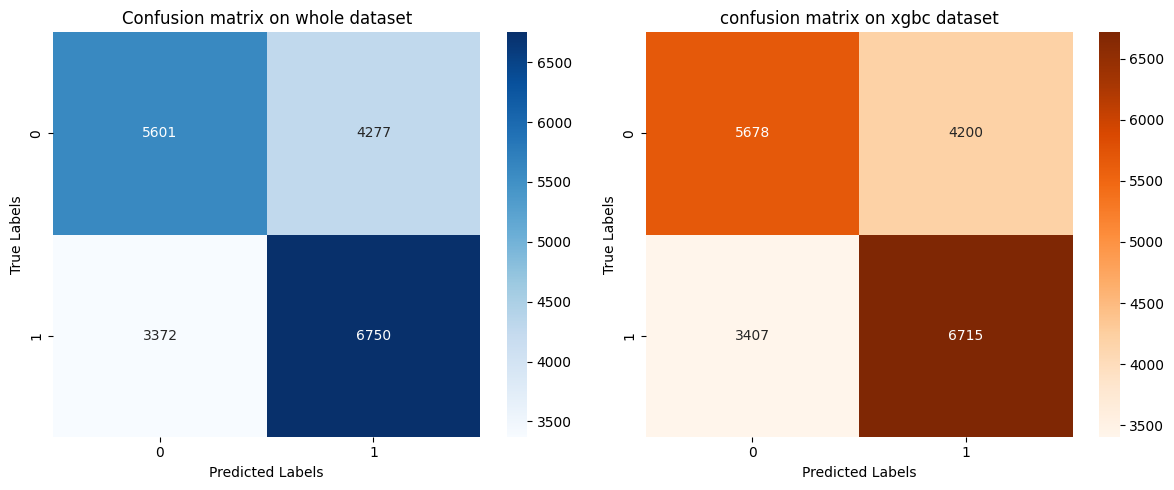

In [157]:
cm1 = confusion_matrix(y_val, y_pred)
cm2 = confusion_matrix(y_val, y_pred_xgbc)
labels=xgb_model.classes_
fig,axes=plt.subplots(1,2,figsize=(12,5))

sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Confusion matrix on whole dataset')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('confusion matrix on xgbc dataset')
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')

plt.tight_layout()
plt.show()

In [158]:
xgb_final = XGBClassifier(
    subsample=0.8,
    n_estimators=200,
    min_child_weight=1,
    max_depth=5,
    learning_rate=0.1,
    gamma=0.1,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
xgb_final.fit(X_train_xgbc, y_train)
y_pred_xgbc = xgb_final.predict(X_val_xgbc)
score_xgbc = accuracy_score(y_val, y_pred_xgbc)

xgb_final.fit(X_train, y_train)
y_pred = xgb_final.predict(X_val)
score= accuracy_score(y_val, y_pred)

print(f"Validation Accuracy of xgbc dataset: {score_xgbc}")
print(f"Validation Accuracy of whole dataset: {score}")

Validation Accuracy of xgbc dataset: 0.62655
Validation Accuracy of whole dataset: 0.6239


- Validation accuracy performed on xgbc dataset with tuned xgbc model performed slightly better than on whole dataset 

In [159]:
report=classification_report(y_val,y_pred)
xgbc_report=classification_report(y_val,y_pred_xgbc)
print(report)
print(xgbc_report)

              precision    recall  f1-score   support

           0       0.63      0.57      0.60      9878
           1       0.62      0.68      0.65     10122

    accuracy                           0.62     20000
   macro avg       0.62      0.62      0.62     20000
weighted avg       0.62      0.62      0.62     20000

              precision    recall  f1-score   support

           0       0.63      0.57      0.60      9878
           1       0.62      0.68      0.65     10122

    accuracy                           0.63     20000
   macro avg       0.63      0.63      0.63     20000
weighted avg       0.63      0.63      0.63     20000



- As we can see looking at both classification report of tuned xgbc model , the precision,recall & f1-score are same, but some difference in accuracy it is 0.62 for whole dataset and 0.63 for xgbc dataset, the top 200 features select by selectfrommmodel using the xgbclassifier.

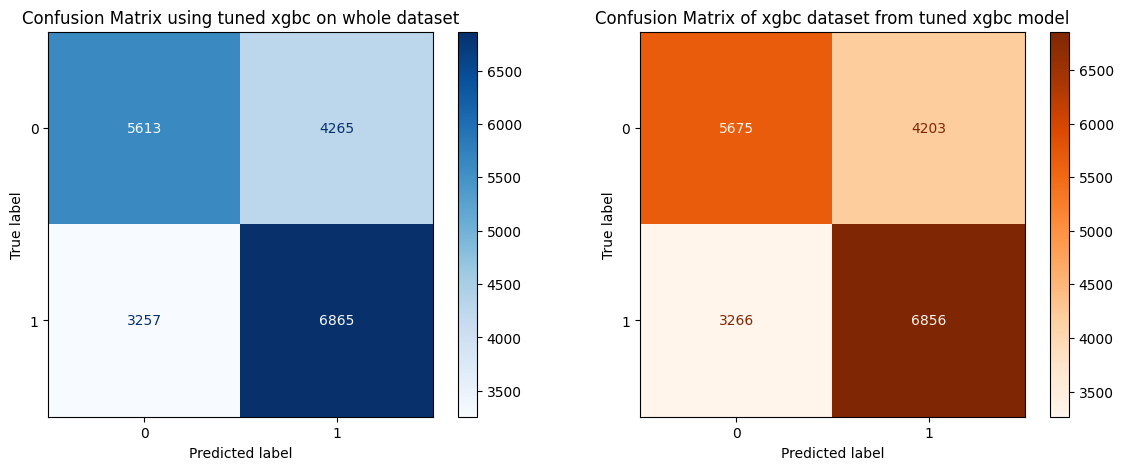

In [160]:
cm1 = confusion_matrix(y_val, y_pred)
cm2 = confusion_matrix(y_val, y_pred_xgbc)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm1).plot(ax=axes[0], cmap='Blues')
axes[0].set_title("Confusion Matrix using tuned xgbc on whole dataset")

ConfusionMatrixDisplay(cm2).plot(ax=axes[1], cmap='Oranges')
axes[1].set_title("Confusion Matrix of xgbc dataset from tuned xgbc model")

plt.show()

- We can see there is not much difference, that means that tuned model is performing almost same on both dataset, whole dataset as well as on xgbc dataset.

2. **RandomForestClassifier**

In [161]:
rfc_final = RandomForestClassifier(
    bootstrap=False,
    criterion= 'gini',
    max_depth= 20,
    max_features='sqrt',
    min_samples_split= 5,
    n_estimators=100,
    random_state=42
)
rfc_final.fit(X_train_xgbc, y_train)
y_pred_xgbc = rfc_final.predict(X_val_xgbc)
score_xgbc = accuracy_score(y_val, y_pred_xgbc)


rfc_final.fit(X_train, y_train)
y_pred= rfc_final.predict(X_val)
score = accuracy_score(y_val, y_pred)

print(f"Validation Accuracy of whole: {score}")
print(f"Validation Accuracy of xgbc dataset: {score_xgbc}")

Validation Accuracy of whole: 0.6149
Validation Accuracy of xgbc dataset: 0.62295


* Validation Accuracy on xgbc dataset is better than on whole dataset.

In [162]:
report=classification_report(y_val,y_pred)
xgbc_report=classification_report(y_val,y_pred_xgbc)
print(report)
print(xgbc_report)

              precision    recall  f1-score   support

           0       0.63      0.53      0.58      9878
           1       0.60      0.70      0.65     10122

    accuracy                           0.61     20000
   macro avg       0.62      0.61      0.61     20000
weighted avg       0.62      0.61      0.61     20000

              precision    recall  f1-score   support

           0       0.64      0.56      0.59      9878
           1       0.61      0.69      0.65     10122

    accuracy                           0.62     20000
   macro avg       0.62      0.62      0.62     20000
weighted avg       0.62      0.62      0.62     20000



* There are 2 classification report above one is of X_train dataset rfc model trained and below that is of X_train_xgbc dataset. 

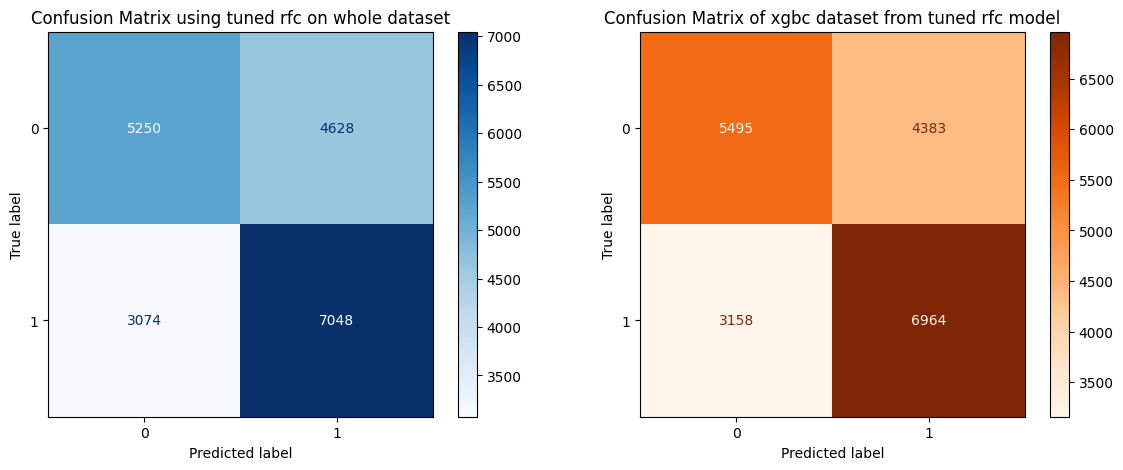

In [163]:
cm1 = confusion_matrix(y_val, y_pred)
cm2 = confusion_matrix(y_val, y_pred_xgbc)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm1).plot(ax=axes[0], cmap='Blues')
axes[0].set_title("Confusion Matrix using tuned rfc on whole dataset")

ConfusionMatrixDisplay(cm2).plot(ax=axes[1], cmap='Oranges')
axes[1].set_title("Confusion Matrix of xgbc dataset from tuned rfc model")

plt.show()

* True Negative of whole dataset is more than True Negative of xgbc dataset but looking at False Negative in which True label was 0 but predicted as 1, is more than False Negative of xgbc dataset.

3. GradientBoostClassifier

In [164]:
gbc_final=GradientBoostingClassifier(subsample= 0.8,n_estimators=50,max_leaf_nodes= 20,max_depth=4,learning_rate=0.1,random_state=42)
gbc_final.fit(X_train_xgbc,y_train)
y_pred_xgbc=gbc_final.predict(X_val_xgbc)
score_xgbc=accuracy_score(y_val,y_pred_xgbc)
print(f"validation accuracy of tune gbc on xgbc dataset: {score_xgbc}")

validation accuracy of tune gbc on xgbc dataset: 0.62


In [165]:
xgbc_report=classification_report(y_val,y_pred_xgbc)
print(xgbc_report)

              precision    recall  f1-score   support

           0       0.64      0.54      0.58      9878
           1       0.61      0.70      0.65     10122

    accuracy                           0.62     20000
   macro avg       0.62      0.62      0.62     20000
weighted avg       0.62      0.62      0.62     20000



* Training of GBC was not done on whole dataset because of too much time consumption.

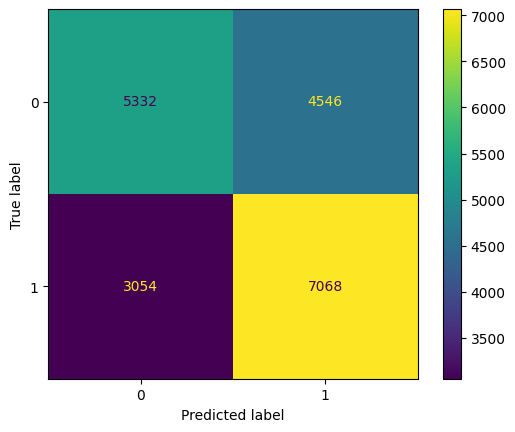

In [166]:
cm=confusion_matrix(y_val.tolist(),y_pred_xgbc.tolist(),labels=gbc_final.classes_)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

* Looking at confusion matrix og gbc on xgbc dataset it performs somewhat same as that of rfc.

4. **Voting Classifier**

In [167]:
rfc_final = RandomForestClassifier(
    bootstrap=False,
    criterion= 'gini',
    max_depth= 20,
    max_features='sqrt',
    min_samples_split= 5,
    n_estimators=100,
    random_state=42
)
xgb_final = XGBClassifier(
    subsample=0.8,
    n_estimators=200,
    min_child_weight=1,
    max_depth=5,
    learning_rate=0.1,
    gamma=0.1,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
gbc=GradientBoostingClassifier(subsample= 0.8,n_estimators=50,max_leaf_nodes= 20,max_depth=4,learning_rate=0.1,random_state=42)
weights=[3,2,1]
voting_clf=VotingClassifier(
    estimators=[("XGB", xgb_final), ("RFC", rfc_final), ("GBC", gbc)],
    voting="hard",weights=weights
)
voting_clf.fit(X_train_xgbc,y_train)
y_pred_vtc=voting_clf.predict(X_val_xgbc)
score_vtc = accuracy_score(y_val, y_pred_vtc)

voting_clf.fit(X_train,y_train)
y_pred=voting_clf.predict(X_val)
score = accuracy_score(y_val, y_pred)
print(f"validation accuracy of tune voting classifier on xgbc dataset: {score_vtc}")
print(f"Validation accuracy of tuned voting classifier on whole dataset: {score}")

validation accuracy of tune voting classifier on xgbc dataset: 0.6259
Validation accuracy of tuned voting classifier on whole dataset: 0.6222


In [168]:
report=classification_report(y_val,y_pred)
vtc_report=classification_report(y_val,y_pred_vtc)
print(report)
print(vtc_report)

              precision    recall  f1-score   support

           0       0.63      0.59      0.61      9878
           1       0.62      0.66      0.64     10122

    accuracy                           0.62     20000
   macro avg       0.62      0.62      0.62     20000
weighted avg       0.62      0.62      0.62     20000

              precision    recall  f1-score   support

           0       0.63      0.60      0.61      9878
           1       0.62      0.66      0.64     10122

    accuracy                           0.63     20000
   macro avg       0.63      0.63      0.63     20000
weighted avg       0.63      0.63      0.63     20000



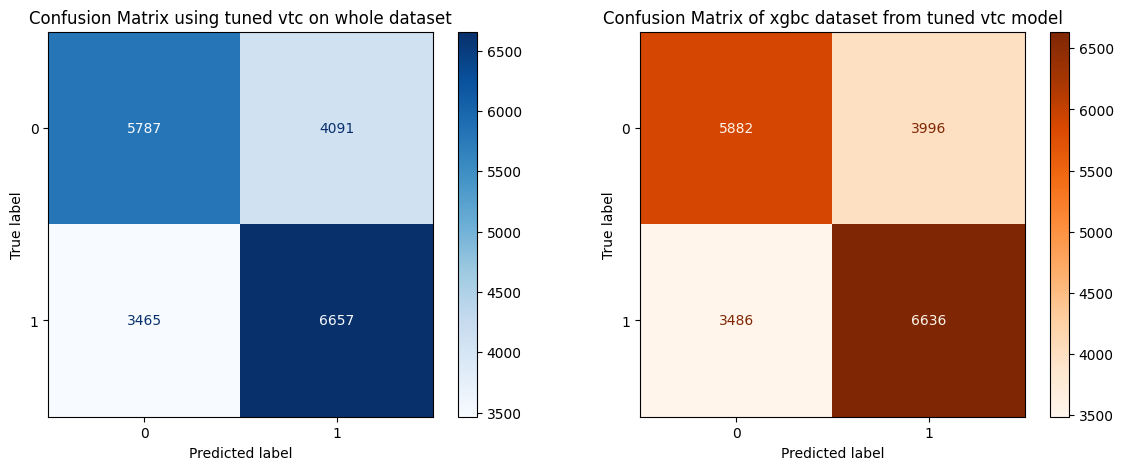

In [169]:
cm1 = confusion_matrix(y_val, y_pred)
cm2 = confusion_matrix(y_val, y_pred_vtc)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm1).plot(ax=axes[0], cmap='Blues')
axes[0].set_title("Confusion Matrix using tuned vtc on whole dataset")

ConfusionMatrixDisplay(cm2).plot(ax=axes[1], cmap='Oranges')
axes[1].set_title("Confusion Matrix of xgbc dataset from tuned vtc model")

plt.show()

* Looking at the confusion matrix of tuned voting classifer performed on both X_train and X_train_xgbc dataset, accuracy is same, slightly more when performed on X_train_xgbc.

5. **Stacking Classifier**

In [170]:
meta_learner = LogisticRegression(max_iter=10000, solver="saga") 
stacking_clf = StackingClassifier(
    estimators=[("XGB", xgb_final), ("RFC", rfc_final), ("GBC", gbc)],
    final_estimator=meta_learner, 
    stack_method="predict_proba",  
    passthrough=False
)
stacking_clf.fit(X_train_xgbc, y_train)
y_pred_stc = stacking_clf.predict(X_val_xgbc)
stacking_acc = accuracy_score(y_val, y_pred_stc)
print(f"Stacking Classifier Accuracy on xgbc dataset: {stacking_acc}")

Stacking Classifier Accuracy on xgbc dataset: 0.62645


In [171]:
report=classification_report(y_val, y_pred_stc)
print(report)

              precision    recall  f1-score   support

           0       0.64      0.57      0.60      9878
           1       0.62      0.68      0.65     10122

    accuracy                           0.63     20000
   macro avg       0.63      0.63      0.63     20000
weighted avg       0.63      0.63      0.63     20000



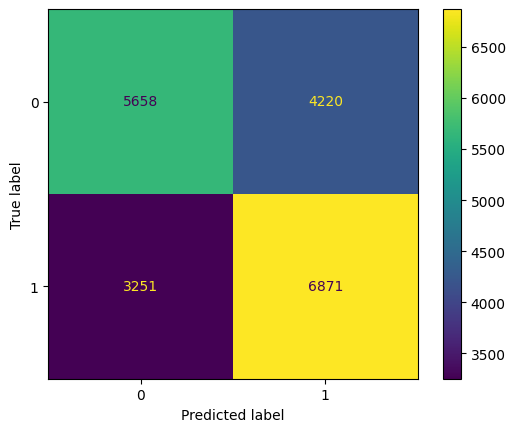

In [172]:
cm=confusion_matrix(y_val.tolist(),y_pred_stc.tolist(),labels=stacking_clf.classes_)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

* Looking at the Confusion Matrix it performed as same as for Tuned Voting Classifier, but False Negative of this stacking_classifier is more voting classifier if compared, but accuracy is same.

# Model Comparison

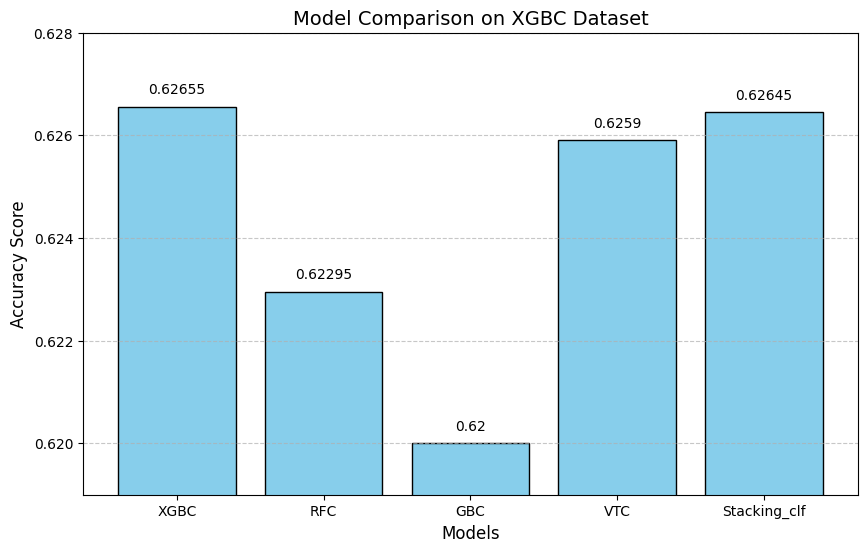

In [173]:
tuned_model_on_xgbc_dataset=['XGBC','RFC','GBC','VTC','Stacking_clf']
score=[0.62655,0.62295,0.62,0.6259,0.62645]

plt.figure(figsize=(10, 6))
bars = plt.bar(tuned_model_on_xgbc_dataset, score, color='skyblue', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0002, round(yval, 5), ha='center', va='bottom', fontsize=10)

plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Model Comparison on XGBC Dataset', fontsize=14)
plt.ylim([0.619, 0.628])  
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

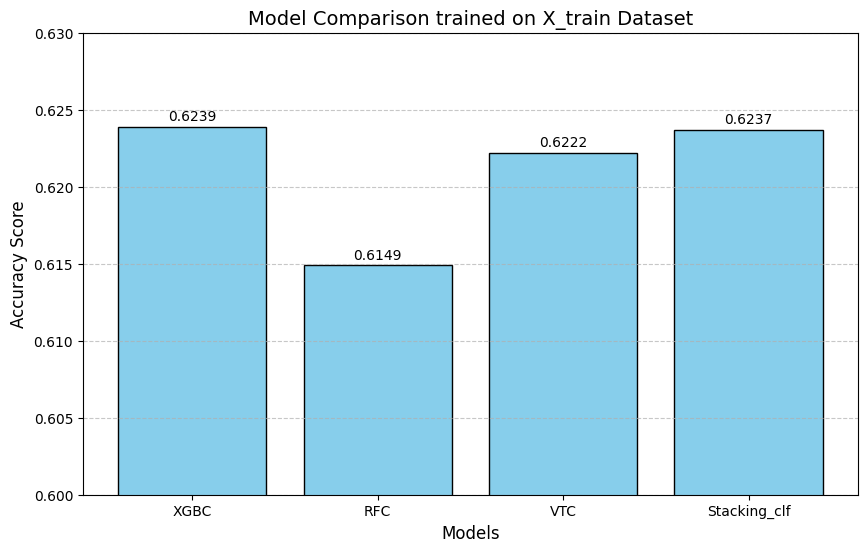

In [174]:
tuned_model_on_X_train=['XGBC','RFC','VTC','Stacking_clf']
score =[0.6239,0.6149,0.6222,0.6237]

plt.figure(figsize=(10, 6))
bars = plt.bar(tuned_model_on_X_train, score, color='skyblue', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0002, round(yval, 5), ha='center', va='bottom', fontsize=10)

plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Model Comparison trained on X_train Dataset', fontsize=14)
plt.ylim([0.60, 0.63])  
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

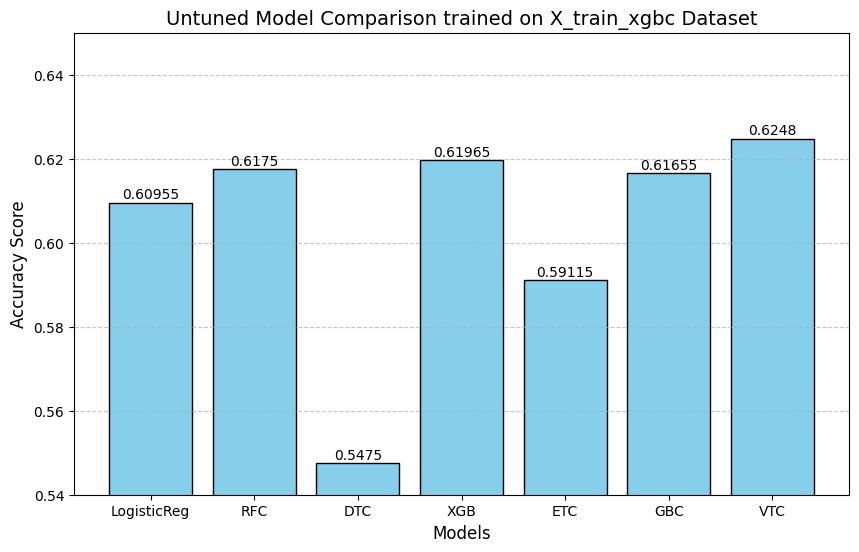

In [175]:
untuned_model_on_xgbc_dataset=['LogisticReg','RFC','DTC','XGB','ETC','GBC','VTC']
score=[0.60955,0.6175,0.5475,0.61965,0.59115,0.61655,0.6248]

plt.figure(figsize=(10, 6))
bars = plt.bar(untuned_model_on_xgbc_dataset, score, color='skyblue', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0002, round(yval, 5), ha='center', va='bottom', fontsize=10)

plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Untuned Model Comparison trained on X_train_xgbc Dataset', fontsize=14)
plt.ylim([0.54, 0.65])  
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

# Model Submission

In [176]:
xgb_final = XGBClassifier(
    subsample=0.8,
    n_estimators=200,
    min_child_weight=1,
    max_depth=5,
    learning_rate=0.1,
    gamma=0.1,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
xgb_final.fit(X_train, y_train)
y_pred = xgb_final.predict(X_val)
score = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {score}")

y_test=xgb_final.predict(test_df)
print(y_test)

Validation Accuracy: 0.6239
[1 0 1 ... 0 1 0]


* I will be choosing Xgb_final model and trained on X_train dataset because it showed best accuracy compared to other in the test dataset.

In [177]:
submission = pd.DataFrame({"id": range(0,test_df.shape[0]), "target": y_test})
submission.to_csv('submission.csv',index=False)